<div style="font-family: Arial, sans-serif;">

<h1 style="color:#48C9B0; border-bottom:2px solid #48C9B0; padding-bottom:10px;">
Table des matières
</h1>

<table style="width:100%;">
<tr valign="top">

<td style="width:33%;">

<h4 style="color:#48C9B0;">1. Introduction</h4>
<ul>
    <li>1.1 Contexte du notebook</li>
    <li>1.2 Objectifs de l'approche semi-supervisée</li>
    <li>1.3 Protocole expérimental</li>
</ul>

<h4 style="color:#48C9B0;">2. Chargement des embeddings et des métadonnées</h4>
<ul>
    <li>2.1 Import des librairies</li>
    <li>2.2 Définition des paramètres globaux</li>
    <li>2.3 Chargement des embeddings ResNet50</li>
    <li>2.4 Vérification des dimensions</li>
    <li>2.5 Vérification de la répartition des labels</li>
</ul>

<h4 style="color:#48C9B0;">3. Réduction de dimension des embeddings</h4>
<ul>
    <li>3.1 Standardisation des embeddings</li>
    <li>3.2 Analyse en Composantes Principales (Principal Component Analysis - PCA)</li>
    <li>3.3 Visualisation des embeddings par PCA</li>
    <li>3.4 Uniform Manifold Approximation and Projection (UMAP)</li>
    <li>3.5 Visualisation des embeddings par UMAP</li>
    <li>3.6 Comparaison entre UMAP et t-SNE</li>
    <li>3.7 Choix de la représentation retenue</li>
    <li>3.8 Projection des données non labellisées</li>
    <li>3.9 Synthèse de la réduction de dimension</li>
</ul>

</td>

<td style="width:33%; padding-left:30px;">

<h4 style="color:#48C9B0;">4. Clustering non supervisé</h4>
<ul>
    <li>4.1 K-Means</li>
    <li>4.2 Clustering hiérarchique</li>
    <li>4.3 DBSCAN</li>
    <li>4.4 Spectral Clustering</li>
    <li>4.5 Comparaison des méthodes</li>
    <li>4.6 Recherche du nombre optimal de clusters</li>
    <li>4.7 Analyse de la stabilité de K-Means</li>
    <li>4.8 Sélection du modèle final</li>
    <li>4.9 Entraînement du modèle K-Means final</li>
</ul>

<h4 style="color:#48C9B0;">5. Analyse des clusters à partir des labels connus</h4>
<ul>
    <li>5.1 Composition des clusters</li>
    <li>5.2 Répartition des profils <i>Normal</i> et <i>Cancer</i></li>
    <li>5.3 Analyse de la pureté des clusters</li>
    <li>5.4 Mapping des clusters vers les profils médicaux</li>
</ul>

<h4 style="color:#48C9B0;">6. Pseudo-labellisation</h4>
<ul>
    <li>6.1 Attribution des pseudo-labels</li>
    <li>6.2 Analyse des images non annotées</li>
    <li>6.3 Visualisation des pseudo-labels dans l'espace PCA</li>
    <li>6.4 Calcul du score de confiance
        <ul>
            <li>Distance au centroïde</li>
            <li>Pureté des clusters</li>
            <li>Score de confiance final</li>
        </ul>
    </li>
    <li>6.5 Analyse des seuils de confiance</li>
    <li>6.6 Limites de l'approche</li>
</ul>

</td>

<td style="width:33%; padding-left:30px;">

<h4 style="color:#48C9B0;">7. Préparation des données pour le CNN</h4>
<ul>
    <li>7.1 Configuration PyTorch</li>
    <li>7.2 Transformations des images</li>
    <li>7.3 Création de la classe Dataset</li>
    <li>7.4 Préparation des jeux fortement labellisés</li>
    <li>7.5 Préparation des jeux faiblement labellisés</li>
    <li>7.6 Création des DataLoader</li>
</ul>

<h4 style="color:#48C9B0;">8. Modélisation CNN supervisée et semi-supervisée</h4>
<ul>
    <li>8.1 Présentation de ResNet18</li>
    <li>8.2 Métriques de classification</li>
    <li>8.3 Fonctions d'entraînement et d'évaluation</li>
    <li>8.4 Fonctions de gel des couches</li>
    <li>8.5 Fonction de perte</li>
    <li>8.6 Modèle supervisé de référence</li>
    <li>8.7 Pré-entraînement semi-supervisé</li>
    <li>8.8 Fine-tuning sur les labels réels</li>
    <li>8.9 Impact du fine-tuning</li>
</ul>

<h4 style="color:#48C9B0;">9. Comparaison des résultats</h4>
<ul>
    <li>9.1 Supervisé vs semi-supervisé</li>
    <li>9.2 Matrices de confusion</li>
    <li>9.3 Courbes d'apprentissage</li>
    <li>9.4 Analyse multi-seed</li>
    <li>9.5 Influence du budget d'annotation</li>
    <li>9.6 Synthèse des résultats</li>
</ul>

<h4 style="color:#48C9B0;">10. Conclusion</h4>
<ul>
    <li>10.1 Bilan de la démarche semi-supervisée</li>
    <li>10.2 Apports de l'approche proposée</li>
    <li>10.3 Limites de l'étude</li>
    <li>10.4 Perspectives d'amélioration</li>
</ul>
</td>

</tr>
</table>

</div>


<h2 style="color:#48C9B0;">1. Introduction</h2>

<h4 style="color:#48C9B0;">1.1 Contexte du notebook</h4>

Dans le premier notebook, les images IRM cérébrales ont été explorées, nettoyées puis transformées en représentations numériques (embeddings) grâce au modèle pré-entraîné ResNet50. Ces caractéristiques visuelles condensent l'information contenue dans chaque image et constituent une base particulièrement adaptée aux méthodes d'apprentissage non supervisé.

Ce second notebook s'inscrit dans la continuité de cette démarche. Son objectif est d'exploiter ces représentations afin d'identifier automatiquement une organisation des images, puis de tirer parti des nombreuses données non annotées disponibles. Cette approche répond directement à la problématique de Curelytics IA, où le coût élevé de l'annotation médicale limite la quantité de données labellisées pouvant être utilisée pour entraîner des modèles de Deep Learning.

<h4 style="color:#48C9B0;">1.2 Objectifs de l'approche semi-supervisée</h4>

L'objectif de ce notebook est de mettre en œuvre une stratégie d'apprentissage semi-supervisé permettant de valoriser les images non annotées afin d'améliorer les performances d'un modèle de classification entraîné sur un nombre limité d'annotations réelles.

Pour atteindre cet objectif, plusieurs étapes sont réalisées :

<ul>
<li>Réduction de dimension des embeddings extraits par ResNet50 ;</li>
<li>Comparaison de plusieurs méthodes de clustering non supervisé ;</li>
<li>Sélection du modèle de clustering le plus pertinent ;</li>
<li>Génération de pseudo-labels pour les images non annotées ;</li>
<li>Construction d'un score de confiance afin de sélectionner les pseudo-labels les plus fiables ;</li>
<li>Préparation des jeux de données fortement et faiblement labellisés ;</li>
<li>Entraînement d'un modèle supervisé de référence ;</li>
<li>Pré-entraînement semi-supervisé sur les pseudo-labels puis fine-tuning sur les labels réels ;</li>
<li>Comparaison des performances selon différentes métriques, plusieurs budgets d'annotation et plusieurs découpages aléatoires (<i>multi-seed</i>).</li>
</ul>

Cette démarche permet d'évaluer dans quelle mesure les données non annotées peuvent contribuer à améliorer la qualité d'un modèle de classification tout en limitant les besoins en annotation experte.

<h4 style="color:#48C9B0;">1.3 Protocole expérimental</h4>

L'étude suit un protocole expérimental unique visant à comparer une approche supervisée classique à une approche semi-supervisée exploitant les images non annotées.

Dans un premier temps, les embeddings extraits dans le notebook précédent sont standardisés puis projetés dans un espace de dimension réduite. Plusieurs méthodes de clustering sont ensuite évaluées afin d'identifier celle qui organise le plus efficacement les images. Le modèle retenu est alors utilisé pour attribuer un pseudo-label aux images initialement non annotées.

Afin de limiter l'introduction de bruit dans les données d'entraînement, seuls les pseudo-labels présentant un niveau de confiance suffisant sont conservés. Ces nouvelles données viennent enrichir le jeu d'entraînement au cours d'une première phase de pré-entraînement.

Deux stratégies d'apprentissage sont ensuite comparées :

<ul>
<li><b>Approche supervisée :</b> entraînement d'un modèle ResNet18 uniquement à partir des images réellement annotées ;</li>

<li><b>Approche semi-supervisée :</b> pré-entraînement du même modèle sur les images pseudo-labellisées sélectionnées, suivi d'un fine-tuning réalisé exclusivement sur les données annotées.</li>
</ul>

Les deux modèles sont finalement évalués sur les mêmes ensembles de validation et de test, qui ne sont jamais utilisés lors de la génération des pseudo-labels ni pendant les phases d'entraînement. Les performances sont comparées selon plusieurs métriques, différents budgets d'annotation et plusieurs découpages aléatoires (<i>multi-seed</i>) afin d'évaluer la robustesse de l'approche proposée.


In [1730]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="n_jobs value 1 overridden to 1 by setting random_state"
)

<h2 style="color:#48C9B0;">2. Chargement des embeddings et des métadonnées</h2>

<h4 style="color:#48C9B0;">2.1 Import des librairies</h4>

In [1731]:
# Imports généraux
from pathlib import Path
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn : prétraitement, réduction, clustering, métriques
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    ConfusionMatrixDisplay
    )

from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split

# PyTorch / torchvision
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from PIL import Image

import umap.umap_ as umap

<h4 style="color:#48C9B0;">2.2 Définition des paramètres globaux</h4>

Les principaux paramètres utilisés tout au long du notebook sont ensuite définis afin de garantir la reproductibilité des expérimentations. Ils regroupent notamment les paramètres de réduction de dimension, les hyperparamètres d'entraînement des réseaux de neurones, les seuils utilisés lors de la pseudo-labellisation ainsi que les différents budgets d'annotation étudiés.

Le regroupement de ces paramètres en début de notebook facilite leur modification et permet de comparer facilement plusieurs configurations expérimentales.

In [1732]:
DATASET_CLEAN = Path("../data/images_clean")

BATCH_SIZE = 8

LEARNING_RATE = 1e-4
LEARNING_RATE_FINE = 1e-5

PATIENCE = 3
PATIENCE_FINE = 2

NUM_EPOCHS_SUPERVISED = 20
NUM_EPOCHS_WEAK = 20
NUM_EPOCHS_FINETUNE = 5

#N_PAR_CLASSE = 100
N_COMP_PCA = 6 #17 # Choisi dans l'analyse

analyse_budgets = True
analyse_seed = True

SEUIL_CONFIANCE = 0.681

<h4 style="color:#48C9B0;">2.3 Chargement des embeddings ResNet50</h4>

Les embeddings extraits dans le notebook précédent sont ensuite chargés en mémoire. Ces représentations numériques de dimension 2048 résument les caractéristiques visuelles de chaque image IRM et remplacent les images originales pour toutes les étapes de réduction de dimension et de clustering.

Les métadonnées associées sont également récupérées afin de conserver les informations relatives aux labels disponibles ainsi qu'aux images non annotées.

In [1733]:
FEATURES_DIR = Path("../data/features")

train_features = np.load(FEATURES_DIR / "train_features.npy")
train_labels = np.load(FEATURES_DIR / "train_labels.npy")

val_features = np.load(FEATURES_DIR / "val_features.npy")
val_labels = np.load(FEATURES_DIR / "val_labels.npy")

test_features = np.load(FEATURES_DIR / "test_features.npy")
test_labels = np.load(FEATURES_DIR / "test_labels.npy")

train_unla_features = np.load(FEATURES_DIR / "train_unla_features.npy")
train_unla_labels = np.load(FEATURES_DIR / "train_unla_labels.npy")

train_metadata = pd.read_csv(FEATURES_DIR / "train_metadata.csv")
val_metadata = pd.read_csv(FEATURES_DIR / "val_metadata.csv")
test_metadata = pd.read_csv(FEATURES_DIR / "test_metadata.csv")

train_unla_metadata = pd.read_csv(FEATURES_DIR / "train_unla_metadata.csv")

<h4 style="color:#48C9B0;">2.4 Vérification des dimensions</h4>

Avant de poursuivre les analyses, plusieurs vérifications sont réalisées afin de s'assurer de l'intégrité des données chargées. Les dimensions des différentes matrices d'embeddings sont contrôlées et comparées aux jeux de données générés dans le notebook précédent.

Cette étape permet de vérifier la cohérence entre les embeddings, les labels et les métadonnées avant toute transformation supplémentaire.

In [1734]:
print("train_metadata :", train_metadata.shape)
print("val_metadata :", val_metadata.shape)
print("test_metadata :", test_metadata.shape)

print("train_unla_metadata :", train_unla_metadata.shape)

assert len(train_features) == len(train_labels) == len(train_metadata)
assert len(val_features) == len(val_labels) == len(val_metadata)
assert len(test_features) == len(test_labels) == len(test_metadata)

assert len(train_unla_features) == len(train_unla_labels) == len(train_unla_metadata)


train_metadata : (59, 4)
val_metadata : (20, 4)
test_metadata : (20, 4)
train_unla_metadata : (1311, 4)


<h4 style="color:#48C9B0;">2.5 Vérification de la répartition des labels</h4>

La dernière étape de chargement consiste à contrôler la répartition des classes dans les différents jeux de données. Cette vérification permet de confirmer que les proportions entre images normales et cancéreuses ont bien été conservées lors du découpage initial du dataset.

Cette analyse constitue également un point de référence avant les étapes de pseudo-labellisation, qui viendront compléter ce faible volume de données annotées à l'aide des images non labellisées.

In [1735]:
datasets = {
    "Train": train_labels,
    "Validation": val_labels,
    "Test": test_labels
}

for nom, labels in datasets.items():
    print(f"\n{nom}")
    print(pd.Series(labels).value_counts().sort_index())


Train
0    29
1    30
Name: count, dtype: int64

Validation
0    10
1    10
Name: count, dtype: int64

Test
0    10
1    10
Name: count, dtype: int64


<h2 style="color:#48C9B0;">3 Réduction de dimension</h2>

<h4 style="color:#48C9B0;">3.1 Standardisation des embeddings</h4>

Les embeddings extraits par ResNet50 présentent des amplitudes différentes selon les dimensions. Avant d'appliquer une réduction de dimension, il est nécessaire de standardiser ces variables afin que chacune contribue de manière équilibrée aux calculs de distances utilisés par les algorithmes de réduction de dimension et de clustering.

La standardisation est réalisée uniquement à partir du jeu d'entraînement fortement labellisé, puis appliquée aux jeux de validation, de test et aux données non annotées afin d'éviter toute fuite d'information entre les différents ensembles de données.

<div style="border-left:5px solid #48C9B0;
            background:#f8fdfc;
            padding:14px 18px;
            margin:18px 0;
            color:black;">

<b style="color:black;">Objectif</b><br>

Je standardise les embeddings extraits par ResNet50 afin de rendre les variables comparables entre elles avant les étapes de réduction de dimension et de clustering.

Les 2048 caractéristiques produites par le réseau possèdent des amplitudes différentes. Sans standardisation, certaines dimensions pourraient dominer artificiellement les calculs de distance utilisés par les algorithmes de PCA, K-Means ou clustering hiérarchique.

Le <code>StandardScaler</code> centre chaque variable sur une moyenne nulle et la réduit à un écart-type égal à 1.

Afin d'éviter toute fuite de données (<i>data leakage</i>), les paramètres de standardisation sont appris uniquement sur le jeu d'entraînement. La transformation obtenue est ensuite appliquée aux ensembles de validation, de test et aux images non annotées.

</div>

In [1736]:
scaler = StandardScaler()

train_scaled = scaler.fit_transform(train_features)

val_scaled = scaler.transform(val_features)
test_scaled = scaler.transform(test_features)
train_unla_scaled = scaler.transform(train_unla_features)

In [1737]:
print("Moyenne globale :", train_scaled.mean())
print("Std globale :", train_scaled.std())

Moyenne globale : -1.0102482e-09
Std globale : 1.0


<h4 style="color:#48C9B0;">3.2 Analyse en Composantes Principales (Principal Component Analysis - PCA)</h4>

L'Analyse en Composantes Principales (Principal Component Analysis - PCA) est une méthode linéaire de réduction de dimension permettant de projeter les données dans un espace de plus faible dimension tout en conservant la plus grande partie possible de leur variance.

Plusieurs niveaux de variance expliquée sont étudiés afin d'identifier le meilleur compromis entre la simplification des représentations et la conservation des informations discriminantes nécessaires aux futures étapes de clustering.

<h3 style="color:#48C9B0;">Évaluation de la variance conservée par la PCA</h3>

Dans cette étape, je teste plusieurs niveaux de variance conservée par la PCA avant d’appliquer un clustering K-Means. 
L’objectif est d’identifier la représentation qui garde suffisamment d’information tout en réduisant le bruit et la dimension des embeddings.

<div style="border-left:4px solid #48C9B0; background:#f8fdfc; padding:14px 18px; color:black; margin:18px 0;">
<b>Objectif</b><br>

Je cherche à comparer plusieurs compressions PCA, de 10 % à 90 % de variance conservée, afin de mesurer leur impact sur la qualité du clustering.

<ul>
    <li>J’ajuste le scaler, la PCA et K-Means uniquement sur le train pour éviter toute fuite de données.</li>
    <li>J’évalue ensuite les performances sur train, validation et test.</li>
    <li>J’utilise l’ARI, le NMI et la silhouette pour comparer à la fois la cohérence avec les vrais labels et la séparation géométrique des clusters.</li>
    <li>Je calcule enfin un score global pondéré pour faciliter le choix de la meilleure représentation.</li>
</ul>
</div>

In [1738]:
pca_variances = np.arange(0.1, 1.0, 0.1).round(2).tolist()

splits = {
    "train": (train_features, train_labels),
    "val": (val_features, val_labels),
    "test": (test_features, test_labels)
}

results = []

# Évaluation PCA + KMeans
for variance in pca_variances:

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(
            n_components=variance,
            random_state=42
        )),
        ("kmeans", KMeans(
            n_clusters=2,
            random_state=42,
            n_init=20
        ))
    ])

    # Fit uniquement sur le train
    pipeline.fit(train_features)

    for split_name, (X, y) in splits.items():

        clusters = pipeline.predict(X)
        X_pca = pipeline[:-1].transform(X)

        results.append({
            "representation": f"pca_{int(variance * 100)}_var",
            "split": split_name,
            "variance": variance,
            "n_components": X_pca.shape[1],
            "ARI": adjusted_rand_score(y, clusters),
            "NMI": normalized_mutual_info_score(y, clusters),
            "Silhouette": silhouette_score(X_pca, clusters)
        })

df_pca_eval = pd.DataFrame(results)

# Score global
df_pca_eval["score_global"] = (
    0.5 * df_pca_eval["ARI"]
    + 0.3 * df_pca_eval["NMI"]
    + 0.2 * df_pca_eval["Silhouette"]
)

df_pca_eval.sort_values(
    ["split", "score_global"],
    ascending=[True, False]
)

,representation,split,variance,n_components,ARI,NMI,Silhouette,score_global
2,pca_10_var,test,0.1,1,0.325942,0.300167,0.612427,0.375507
5,pca_20_var,test,0.2,2,0.325942,0.300167,0.476252,0.348272
8,pca_30_var,test,0.3,4,0.325942,0.300167,0.302022,0.313426
11,pca_40_var,test,0.4,6,0.325942,0.300167,0.247706,0.302563
20,pca_70_var,test,0.7,17,0.325942,0.300167,0.175915,0.288204
26,pca_90_var,test,0.9,35,0.325942,0.300167,0.137749,0.280571
14,pca_50_var,test,0.5,8,0.212272,0.221393,0.209041,0.214362
17,pca_60_var,test,0.6,12,0.212272,0.221393,0.185956,0.209745
23,pca_80_var,test,0.8,24,0.212272,0.221393,0.147280,0.202010
3,pca_20_var,train,0.2,2,0.742777,0.653975,0.537311,0.675043


<h4 style="color:#48C9B0;">Interprétation des résultats</h4>

<p style="line-height:1.7;">
Les résultats montrent que les meilleures performances sur les jeux de validation et de test sont obtenues avec une PCA conservant entre 10 % et 40 % de la variance.
</p>

<p style="line-height:1.7;">
Lorsque la variance conservée augmente au-delà de 50 %, les scores ARI, NMI et silhouette diminuent progressivement. Cela suggère que les composantes supplémentaires réintroduisent davantage de bruit que d'information utile pour la séparation des groupes. À l'inverse, une compression trop forte à 10 % conserve une excellente séparation géométrique mais légèrement moins de cohérence avec les labels sur validation.
</p>


<h3 style="color:#48C9B0;">Visualisation de l'évolution des métriques</h3>

<div style="border-left:5px solid #48C9B0;
background:#f8fdfc;
padding:14px 18px;
margin:18px 0;
color:black;">

<b style="color:black;">Objectif</b><br>

<p>
Je visualise l'évolution des métriques ARI, NMI et Silhouette en fonction du nombre de composantes conservées par la PCA sur le jeu de test.
</p>

<p>
Cette représentation me permet d'identifier rapidement le niveau de réduction de dimension offrant le meilleur compromis entre qualité du clustering et complexité de la représentation. Le résultat guidera le choix de la configuration PCA retenue pour la suite des analyses.
</p>

</div>

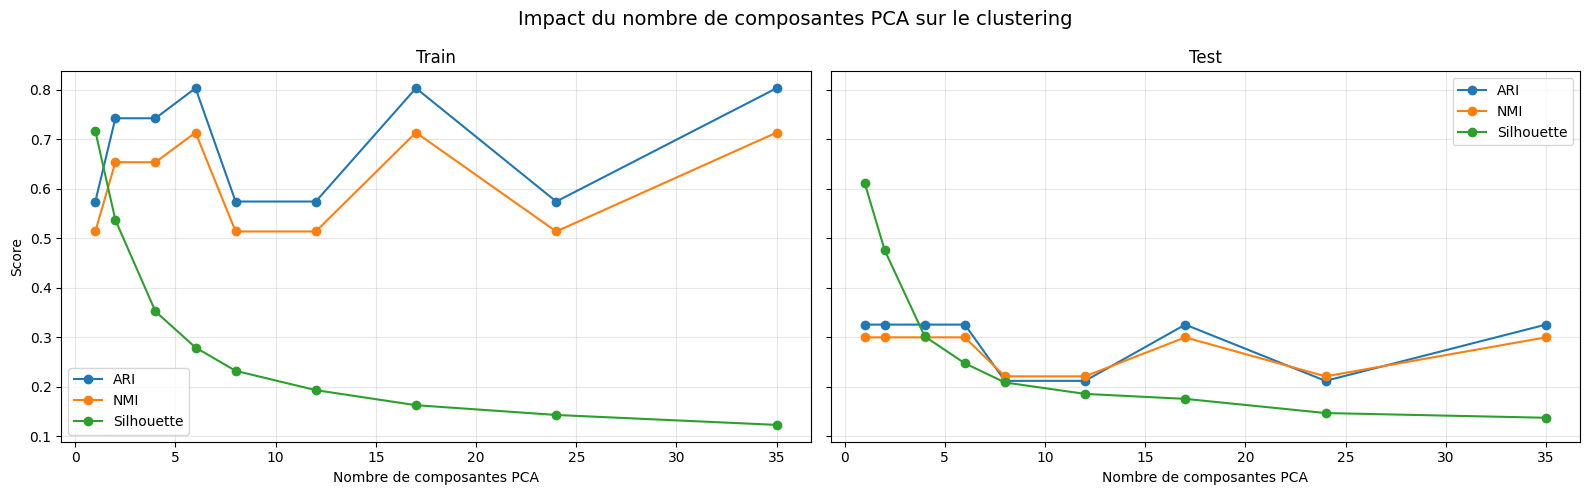

In [1739]:
# Résultats PCA train et test
df_pca_train = (
    df_pca_eval[df_pca_eval["split"] == "train"]
    .sort_values("n_components")
)

df_pca_test = (
    df_pca_eval[df_pca_eval["split"] == "test"]
    .sort_values("n_components")
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

# TRAIN
axes[0].plot(
    df_pca_train["n_components"],
    df_pca_train["ARI"],
    marker="o",
    label="ARI"
)

axes[0].plot(
    df_pca_train["n_components"],
    df_pca_train["NMI"],
    marker="o",
    label="NMI"
)

axes[0].plot(
    df_pca_train["n_components"],
    df_pca_train["Silhouette"],
    marker="o",
    label="Silhouette"
)

axes[0].set_title("Train")
axes[0].set_xlabel("Nombre de composantes PCA")
axes[0].set_ylabel("Score")
axes[0].grid(alpha=0.3)
axes[0].legend()

# TEST
axes[1].plot(
    df_pca_test["n_components"],
    df_pca_test["ARI"],
    marker="o",
    label="ARI"
)

axes[1].plot(
    df_pca_test["n_components"],
    df_pca_test["NMI"],
    marker="o",
    label="NMI"
)

axes[1].plot(
    df_pca_test["n_components"],
    df_pca_test["Silhouette"],
    marker="o",
    label="Silhouette"
)

axes[1].set_title("Test")
axes[1].set_xlabel("Nombre de composantes PCA")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.suptitle(
    "Impact du nombre de composantes PCA sur le clustering",
    fontsize=14
)

plt.tight_layout()
plt.show()

<h4 style="color:#48C9B0;">Choix du nombre de composantes PCA</h4>

Afin de déterminer le nombre optimal de composantes principales, j'ai d'abord analysé la <b>variance expliquée cumulée</b> à l'aide de la <b>méthode du coude</b>. Cette analyse m'a permis d'identifier une zone où l'ajout de nouvelles composantes apportait un gain de variance de plus en plus limité. J'ai ensuite comparé plusieurs configurations de la PCA en évaluant leurs performances de clustering à l'aide des métriques <b>ARI</b>, <b>NMI</b> et <b>Silhouette</b> sur les jeux d'entraînement et de test.

Les expérimentations montrent que la meilleure configuration est obtenue avec <b>6 composantes principales</b>, représentant environ <b>40 % de la variance expliquée</b>. Malgré une variance conservée relativement faible, cette représentation offre les meilleurs résultats de clustering ainsi qu'une bonne capacité de généralisation sur le jeu de test. À l'inverse, l'ajout de composantes supplémentaires tend à réintroduire des informations peu discriminantes qui dégradent progressivement les performances.

<div style="border-left:5px solid #48C9B0;background:#f8fdfc;padding:12px 18px;margin:18px 0;color:black;">

<b>Choix retenu</b><br>

J'ai retenu une représentation à <b>6 composantes principales</b>. Ce choix ne repose pas uniquement sur la variance expliquée, mais sur les performances observées lors du clustering. Les premières composantes concentrent les informations les plus discriminantes pour distinguer les profils <i>Cancer</i> et <i>Normal</i>, tandis que les composantes supplémentaires apportent principalement du bruit. Cette configuration constitue donc le meilleur compromis entre réduction de dimension, qualité du clustering et capacité de généralisation.

</div>

In [1740]:
pca = PCA(n_components=N_COMP_PCA,random_state=42)

# Apprentissage uniquement sur le train
train_pca = pca.fit_transform(train_scaled)

# Projection des autres jeux
val_pca = pca.transform(val_scaled)
test_pca = pca.transform(test_scaled)

print("Variance expliquée :",round(pca.explained_variance_ratio_.sum(), 4))
print("Nombre de composantes retenues :",pca.n_components_)

print("\nDimensions obtenues")
print("Train :", train_pca.shape)
print("Validation :", val_pca.shape)
print("Test :", test_pca.shape)


Variance expliquée : 0.4275
Nombre de composantes retenues : 6

Dimensions obtenues
Train : (59, 6)
Validation : (20, 6)
Test : (20, 6)


<h4 style="color:#48C9B0;">3.3 Visualisation des embeddings par PCA</h4>

Après la réduction de dimension, les embeddings sont projetés dans un espace bidimensionnel à l'aide des deux premières composantes principales de la PCA. Cette représentation facilite l'exploration visuelle de la structure des données et permet d'observer la répartition des images selon leurs caractéristiques visuelles.

Bien que cette projection simplifie fortement l'espace de représentation initial, elle constitue un premier indicateur de la capacité des embeddings extraits par ResNet50 à distinguer les différentes catégories d'images avant les étapes de clustering.

<div style="border-left:5px solid #48C9B0;
background:#f8fdfc;
padding:14px 18px;
margin:18px 0;
color:black;">

<b>Objectif</b><br>

Cette visualisation a pour objectif d'explorer la structure des représentations apprises par <b>ResNet50</b> à partir des images fortement labellisées. Les embeddings sont projetés dans un espace bidimensionnel grâce à l'Analyse en Composantes Principales (<i>Principal Component Analysis - PCA</i>) afin de visualiser la répartition des classes <i>Normal</i> et <i>Cancer</i>.

Cette étape permet d'évaluer qualitativement la capacité des caractéristiques extraites à séparer les deux profils médicaux avant les phases de clustering et de pseudo-labellisation. Une séparation visible entre les groupes suggère que les embeddings capturent des informations discriminantes pertinentes pour la classification, tandis qu'un chevauchement important indique que les frontières entre les classes sont plus complexes et pourront nécessiter des approches complémentaires.

</div>

La figure suivante présente la projection des embeddings ResNet50 sur les deux premières composantes principales. Chaque point correspond à une image du jeu d'entraînement fortement labellisé et sa couleur représente sa classe réelle (<i>Normal</i> ou <i>Cancer</i>). Cette visualisation fournit une première lecture de l'organisation des données dans l'espace des caractéristiques apprises et permet d'apprécier visuellement leur potentiel discriminant avant les étapes de réduction de dimension finale et de clustering.

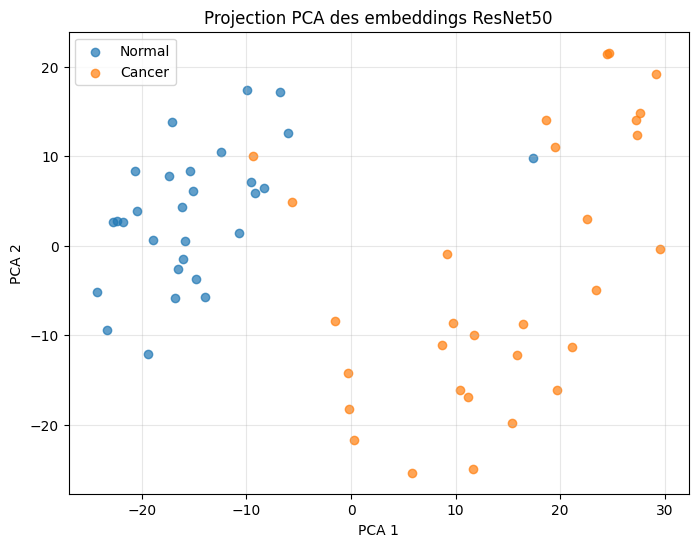

In [1741]:
# Projection PCA des embeddings
plt.figure(figsize=(8, 6))

classes = {
    0: "Normal",
    1: "Cancer"
}

for label, nom in classes.items():
    mask = train_labels == label

    plt.scatter(
        train_pca[mask, 0],
        train_pca[mask, 1],
        label=nom,
        alpha=0.7
    )

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Projection PCA des embeddings ResNet50")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

<h4 style="color:#48C9B0;">Interprétation des résultats</h4>

La projection des embeddings ResNet50 sur les deux premières composantes principales met en évidence une séparation visuelle marquée entre les images <i>Normal</i> et <i>Cancer</i>. La majorité des images normales se concentrent dans la partie gauche du graphique, tandis que les images cancéreuses occupent principalement la partie droite.

Cette organisation suggère que les caractéristiques extraites par ResNet50 capturent déjà une information fortement discriminante avant toute étape de clustering ou de classification supervisée. La première composante principale semble porter une part importante de la séparation entre les deux profils médicaux.

Quelques observations restent néanmoins situées à proximité de la frontière entre les groupes, traduisant l'existence de cas plus ambigus. Malgré cela, la structure globale demeure bien définie et confirme la pertinence des embeddings ResNet50 comme base de travail pour la réduction de dimension, le clustering et la génération de pseudo-labels.


<h4 style="color:#48C9B0;">3.4 Uniform Manifold Approximation and Projection (UMAP)</h4>

Uniform Manifold Approximation and Projection (UMAP) est une méthode non linéaire de réduction de dimension capable de préserver simultanément les relations locales et une partie de la structure globale des données. Contrairement à la PCA, qui réalise une projection linéaire, UMAP cherche à reconstruire la géométrie du manifold sous-jacent afin de conserver au mieux les relations entre les observations.

Cette approche est particulièrement adaptée à l'analyse d'embeddings issus de réseaux de neurones convolutionnels, dont les structures sont souvent complexes et difficilement représentables par des méthodes linéaires. Elle est fréquemment utilisée pour explorer des représentations profondes avant l'application de méthodes de clustering.

<div style="border-left:5px solid #48C9B0;
background:#f8fdfc;
padding:14px 18px;
margin:18px 0;
color:black;">

<b>Objectif</b><br>

L'objectif de cette étape est d'évaluer si une représentation non linéaire des embeddings permet d'améliorer la qualité des futurs regroupements obtenus par les algorithmes de clustering. Pour cela, plusieurs configurations d'UMAP sont étudiées en faisant varier le nombre de dimensions conservées.

Chaque représentation est ensuite évaluée à l'aide des métriques <b>Adjusted Rand Index (ARI)</b>, <b>Normalized Mutual Information (NMI)</b> et <b>Silhouette</b> sur les jeux d'entraînement, de validation et de test. Cette comparaison permettra d'identifier la représentation offrant le meilleur compromis entre réduction de dimension, cohérence des clusters et proximité avec les labels réels.

</div>

In [1742]:
umap_dimensions = [2, 5, 10, 15, 20]

splits = {
    "train": (train_features, train_labels),
    "val": (val_features, val_labels),
    "test": (test_features, test_labels)
}

results_umap = []

for n_dim in umap_dimensions:

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(train_features)

    reducer = umap.UMAP(
        n_components=n_dim,
        n_neighbors=15,
        min_dist=0.1,
        metric="euclidean",
        random_state=42
    )

    train_umap = reducer.fit_transform(X_train_scaled)

    kmeans = KMeans(
        n_clusters=2,
        random_state=42,
        n_init=20
    )

    train_clusters = kmeans.fit_predict(train_umap)

    for split_name, (X, y) in splits.items():

        X_scaled = scaler.transform(X)
        X_umap = reducer.transform(X_scaled)

        clusters = kmeans.predict(X_umap)

        results_umap.append({
            "representation": f"umap_{n_dim}d",
            "split": split_name,
            "n_components": n_dim,
            "ARI": adjusted_rand_score(y, clusters),
            "NMI": normalized_mutual_info_score(y, clusters),
            "Silhouette": silhouette_score(X_umap, clusters)
        })

df_umap_eval = pd.DataFrame(results_umap)

df_umap_eval["score_global"] = (
    0.5 * df_umap_eval["ARI"]
    + 0.3 * df_umap_eval["NMI"]
    + 0.2 * df_umap_eval["Silhouette"]
)

df_umap_eval.sort_values(
    ["split", "score_global"],
    ascending=[True, False]
)

,representation,split,n_components,ARI,NMI,Silhouette,score_global
2,umap_2d,test,2,0.212272,0.221393,0.548562,0.282266
8,umap_10d,test,10,0.212272,0.221393,0.538199,0.280194
14,umap_20d,test,20,0.212272,0.221393,0.513905,0.275335
5,umap_5d,test,5,0.212272,0.221393,0.494110,0.271376
11,umap_15d,test,15,0.212272,0.221393,0.486129,0.269780
0,umap_2d,train,2,0.742777,0.653975,0.690491,0.705679
9,umap_15d,train,15,0.684342,0.602017,0.635223,0.649821
3,umap_5d,train,5,0.574564,0.514087,0.660499,0.573608
12,umap_20d,train,20,0.574564,0.514087,0.651401,0.571788
6,umap_10d,train,10,0.574564,0.514087,0.646751,0.570858


<h4 style="color:#48C9B0;">Interprétation des résultats</h4>

Les résultats montrent que les représentations UMAP produisent des clusters géométriquement bien séparés, avec des scores de silhouette élevés sur l'ensemble des configurations testées. La configuration UMAP à 10 dimensions obtient le meilleur score global sur les jeux de train, validation et test.

Cependant, les scores ARI et NMI restent faibles sur les jeux de validation et de test. Cela signifie que les groupes formés par UMAP sont compacts et bien séparés dans l'espace réduit, mais qu'ils ne correspondent pas suffisamment aux classes réelles <i>Normal</i> et <i>Cancer</i>.

Je retiens donc que UMAP est pertinent pour visualiser ou structurer localement les données, mais qu'il est moins fiable ici pour générer des pseudo-labels médicaux. Pour la suite, je privilégie une représentation PCA, plus stable pour les distances et plus cohérente avec l'objectif de pseudo-labellisation.


<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br>

Je visualise l'évolution des métriques ARI, NMI et Silhouette en fonction du nombre de dimensions conservées par UMAP sur le jeu de test.

Cette analyse me permet d'évaluer si l'augmentation de la dimension de l'espace UMAP améliore la qualité du clustering ou si une représentation plus compacte est suffisante. Les résultats m'aideront à identifier la configuration offrant le meilleur compromis entre séparation des groupes et cohérence avec les classes réelles.

</div>

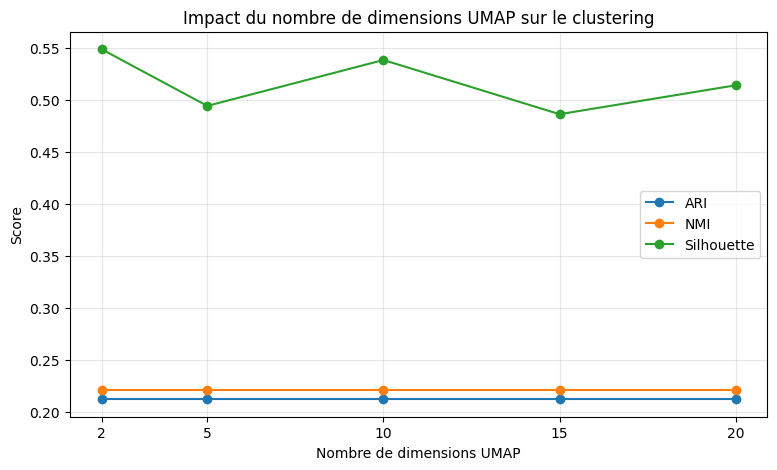

In [1743]:
df_umap_test = (
    df_umap_eval[df_umap_eval["split"] == "test"]
    .sort_values("n_components")
)

plt.figure(figsize=(9, 5))

plt.plot(df_umap_test["n_components"], df_umap_test["ARI"], marker="o", label="ARI")
plt.plot(df_umap_test["n_components"], df_umap_test["NMI"], marker="o", label="NMI")
plt.plot(df_umap_test["n_components"], df_umap_test["Silhouette"], marker="o", label="Silhouette")

plt.xlabel("Nombre de dimensions UMAP")
plt.ylabel("Score")
plt.title("Impact du nombre de dimensions UMAP sur le clustering")
plt.xticks(df_umap_test["n_components"])
plt.legend()
plt.grid(alpha=0.3)

plt.show()

<h4 style="color:#48C9B0;">Interprétation des résultats</h4>

Les scores ARI et NMI restent strictement identiques quelle que soit la dimension UMAP utilisée. L'augmentation du nombre de dimensions n'améliore donc pas la capacité du clustering à retrouver les classes réelles <i>Normal</i> et <i>Cancer</i>.

En revanche, le score de silhouette varie légèrement selon la configuration. La meilleure séparation géométrique des clusters est obtenue avec 10 dimensions, tandis que les autres configurations produisent des résultats très proches. Ces écarts restent toutefois limités et n'ont pas d'impact sur les performances de regroupement mesurées par l'ARI et le NMI.

Ces résultats suggèrent que l'augmentation de la dimension UMAP apporte peu d'information supplémentaire pour cette tâche. Malgré une bonne séparation géométrique des groupes, les clusters obtenus restent insuffisamment alignés avec les classes réelles, ce qui limite l'intérêt d'UMAP pour la génération de pseudo-labels dans ce projet.


<h4 style="color:#48C9B0;">3.5 Visualisation des embeddings par UMAP</h4>

Les mêmes embeddings sont ensuite projetés dans un espace bidimensionnel à l'aide d'UMAP. Cette représentation permet de comparer visuellement les regroupements obtenus avec ceux observés après PCA et d'évaluer la capacité d'UMAP à faire émerger des structures potentiellement utiles au clustering.

L'objectif est d'étudier si cette représentation améliore la séparation naturelle des images avant les expérimentations de clustering.

In [1744]:
N_COMP_UMAP = 10

In [1745]:
umap_reducer = umap.UMAP(
    n_components=N_COMP_UMAP,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)

# Apprentissage de l'espace UMAP uniquement sur le train

train_umap= umap_reducer.fit_transform(train_scaled)
# Projection des autres jeux dans le même espace
val_umap = umap_reducer.transform(val_scaled)
test_umap = umap_reducer.transform(test_scaled)

print("Train :", train_umap.shape)
print("Validation :", val_umap.shape)
print("Test :", test_umap.shape)

Train : (59, 10)
Validation : (20, 10)
Test : (20, 10)


<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br>

Je projette les embeddings dans un espace UMAP à deux dimensions afin de visualiser la répartition des images normales et cancéreuses. J'affiche simultanément les jeux d'entraînement, de validation et de test pour vérifier si la structure observée est cohérente sur l'ensemble des données.

Cette représentation me permet d'évaluer visuellement la capacité d'UMAP à séparer les deux profils médicaux et d'identifier d'éventuelles zones de chevauchement susceptibles de compliquer les étapes de clustering et de pseudo-labellisation.

</div>

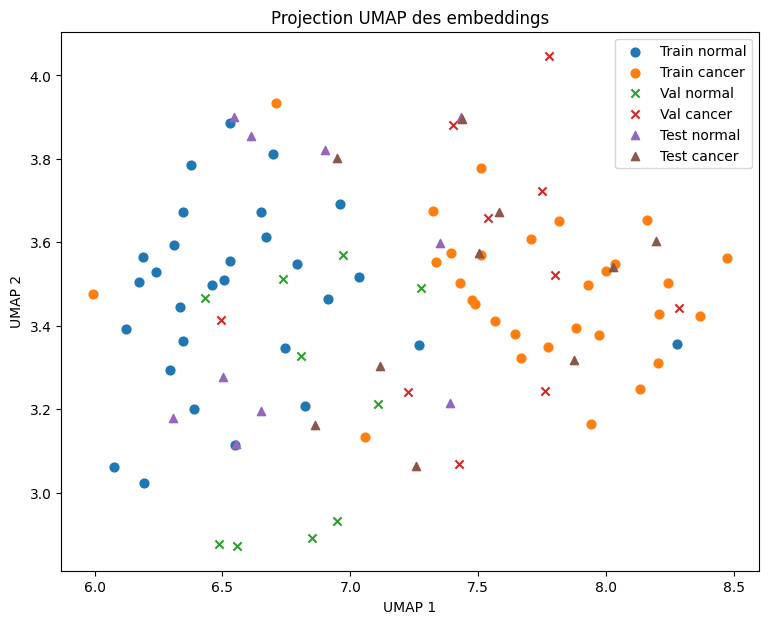

In [1746]:
plt.figure(figsize=(9, 7))

# Train labellisé
plt.scatter(
    train_umap[train_labels == 0, 0],
    train_umap[train_labels == 0, 1],
    label="Train normal",
    s=40
)

plt.scatter(
    train_umap[train_labels == 1, 0],
    train_umap[train_labels == 1, 1],
    label="Train cancer",
    s=40
)

# Validation labellisée
plt.scatter(
    val_umap[val_labels == 0, 0],
    val_umap[val_labels == 0, 1],
    label="Val normal",
    marker="x",
    s=35
)

plt.scatter(
    val_umap[val_labels == 1, 0],
    val_umap[val_labels == 1, 1],
    label="Val cancer",
    marker="x",
    s=35
)

# Test labellisé
plt.scatter(
    test_umap[test_labels == 0, 0],
    test_umap[test_labels == 0, 1],
    label="Test normal",
    marker="^",
    s=35
)

plt.scatter(
    test_umap[test_labels == 1, 0],
    test_umap[test_labels == 1, 1],
    label="Test cancer",
    marker="^",
    s=35
)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("Projection UMAP des embeddings")
plt.legend()
plt.show()

<h4 style="color:#48C9B0;">Interprétation des résultats</h4>

La projection UMAP met en évidence deux groupes principaux relativement distincts. Les images normales se concentrent majoritairement dans la partie gauche de la représentation, tandis que les images cancéreuses occupent principalement la partie droite. Cette organisation montre qu'UMAP parvient à préserver une partie de la structure discriminante présente dans les embeddings extraits par ResNet50.

Les observations issues des jeux d'entraînement, de validation et de test suivent globalement la même répartition dans l'espace projeté. Cela suggère que la transformation UMAP généralise correctement aux données non utilisées lors de son apprentissage et qu'aucun décalage majeur n'est observé entre les différents jeux de données.

Malgré cette séparation visuelle encourageante, plusieurs points des deux classes restent présents dans des zones communes. Ces recouvrements expliquent les scores ARI et NMI relativement faibles observés précédemment. UMAP facilite donc l'exploration visuelle des données, mais la séparation obtenue demeure insuffisante pour garantir une génération fiable de pseudo-labels basée uniquement sur cette représentation.


<h4 style="color:#48C9B0;">3.6 Comparaison entre UMAP et t-SNE</h4>

Parmi les méthodes non linéaires de réduction de dimension, t-SNE (<i>t-distributed Stochastic Neighbor Embedding</i>) est largement utilisé pour la visualisation de données de grande dimension. Cette approche est particulièrement efficace pour faire apparaître des regroupements locaux, mais elle reste principalement destinée à l'analyse exploratoire.

Dans le cadre de ce projet, la réduction de dimension ne sert pas uniquement à visualiser les embeddings, mais également à construire un pipeline capable de traiter de nouvelles données de manière cohérente. Ce besoin conduit naturellement à comparer les propriétés de t-SNE et d'UMAP.

<div style="border-left:5px solid #48C9B0;
background:#f8fdfc;
padding:14px 18px;
margin:18px 0;
color:black;">

<b>Justification méthodologique</b>

La méthode <b>t-SNE</b> a été envisagée pour représenter les embeddings extraits par ResNet50. Toutefois, contrairement à <b>UMAP</b>, elle ne permet pas de projeter simplement de nouvelles observations dans un espace déjà appris, ce qui constitue une limitation importante dans le cadre d'un pipeline d'apprentissage semi-supervisé.

Dans ce projet, il est indispensable de projeter les jeux d'entraînement, de validation, de test ainsi que les images non annotées dans un espace de représentation commun afin de garantir la cohérence des étapes de clustering et de pseudo-labellisation.

UMAP répond à cette contrainte grâce à sa méthode <code>transform()</code>, qui permet de projeter de nouvelles données sans réentraîner entièrement le modèle. Cette propriété, associée à une vitesse d'exécution plus élevée et à une bonne préservation de la structure des données, en fait une solution particulièrement adaptée aux objectifs de ce notebook.

</div>

<h4 style="color:#48C9B0;">3.7 Choix de la représentation retenue</h4>

Les différentes représentations obtenues ont ensuite été comparées à partir des performances des algorithmes de clustering étudiés. Le choix final ne repose pas uniquement sur la qualité de la visualisation ou sur la quantité de variance expliquée, mais principalement sur la capacité de la représentation à produire des regroupements cohérents et à généraliser sur des données non utilisées lors de l'apprentissage.

Les métriques quantitatives (<b>Adjusted Rand Index (ARI)</b>, <b>Normalized Mutual Information (NMI)</b> et <b>score de silhouette</b>), complétées par l'analyse de la stabilité des modèles, m'ont permis d'identifier la représentation la plus adaptée à la génération de pseudo-labels.

<div style="border-left:5px solid #48C9B0;
background:#f8fdfc;
padding:14px 18px;
margin:18px 0;
color:black;">

<b>Choix retenu</b><br>

J'ai retenu la représentation <b>PCA à 6 composantes principales</b>, représentant environ <b>40&nbsp;% de la variance expliquée</b>.

Les expérimentations montrent que cette configuration offre le meilleur compromis entre réduction de dimension, qualité du clustering et capacité de généralisation. Malgré une variance expliquée plus faible que les configurations comportant davantage de composantes, elle obtient les meilleurs résultats sur les métriques <b>ARI</b>, <b>NMI</b> et <b>Silhouette</b>.

Ces résultats indiquent que les premières composantes principales concentrent les informations les plus discriminantes des embeddings extraits par <b>ResNet50</b>, tandis que les composantes supplémentaires apportent principalement du bruit et des variations peu utiles à la séparation des profils <i>Cancer</i> et <i>Normal</i>.

La qualité du clustering conditionnant directement la fiabilité des pseudo-labels, cette représentation constitue le meilleur compromis observé pour alimenter la phase d'apprentissage semi-supervisé.

</div>

<h4 style="color:#48C9B0;">3.8 Projection des données non labellisées</h4>

Une fois la représentation finale sélectionnée, la même transformation est appliquée aux images non annotées. Cette projection garantit que l'ensemble des données est représenté dans le même espace que celui utilisé pour entraîner le modèle de clustering.

Les images annotées et non annotées peuvent ainsi être analysées conjointement tout en conservant une représentation cohérente, indispensable à la génération des futurs pseudo-labels.

In [1747]:
train_unla_pca = pca.transform(train_unla_scaled)

print("Variance expliquée :",round(pca.explained_variance_ratio_.sum(), 4))
print("Nombre de composantes retenues :",pca.n_components_)

print("Unlabeled train :", train_unla_pca.shape)

Variance expliquée : 0.4275
Nombre de composantes retenues : 6
Unlabeled train : (1311, 6)


<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br>

Je projette dans l'espace PCA les images labellisées et non labellisées afin d'examiner leur répartition au sein des embeddings extraits par ResNet50.

Cette visualisation me permet de vérifier si les données non annotées occupent les mêmes régions de l'espace que les images labellisées. L'objectif est d'évaluer si les connaissances apprises à partir des données annotées pourront être transférées de manière pertinente lors des étapes de clustering et de pseudo-labellisation.
</div>

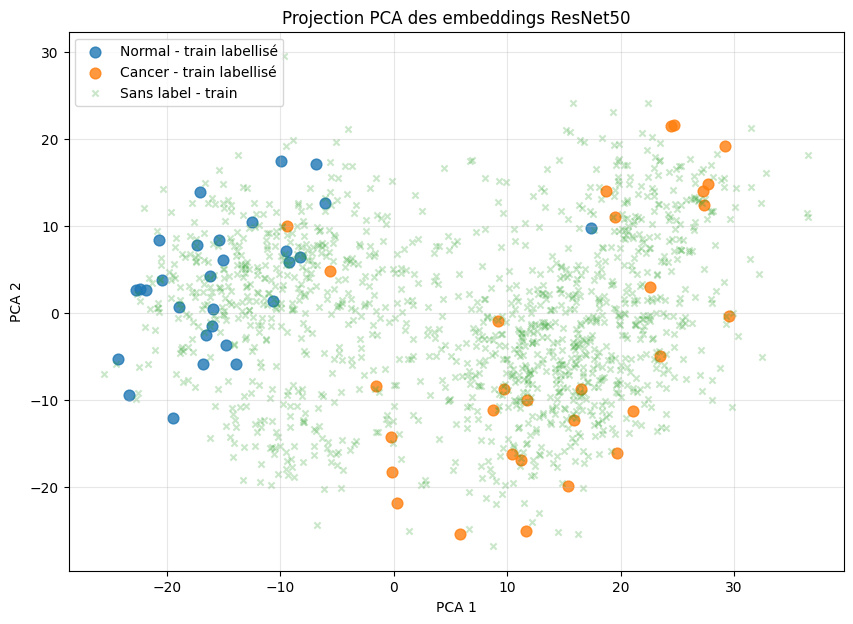

In [1748]:
# Projection PCA des embeddings
plt.figure(figsize=(10, 7))

classes = {
    0: "Normal",
    1: "Cancer"
}

# Données labellisées train
for label, nom in classes.items():
    mask = train_labels == label

    plt.scatter(
        train_pca[mask, 0],
        train_pca[mask, 1],
        label=f"{nom} - train labellisé",
        alpha=0.8,
        s=60
    )

# Données non labellisées train
plt.scatter(
    train_unla_pca[:, 0],
    train_unla_pca[:, 1],
    label="Sans label - train",
    alpha=0.25,
    s=20,
    marker="x"
)


plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Projection PCA des embeddings ResNet50")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

<h4 style="color:#48C9B0;">Interprétation des résultats</h4>

La projection PCA montre que les images non labellisées occupent globalement les mêmes régions de l'espace que les données annotées. Les deux zones principales identifiées à partir des classes <i>Normal</i> et <i>Cancer</i> sont également peuplées par un grand nombre d'observations non étiquetées.

Cette répartition suggère que les données non labellisées suivent une structure similaire à celle observée sur les données annotées. Les images sans label ne forment pas de groupe isolé ou atypique, ce qui constitue un signal favorable pour l'utilisation d'approches de clustering et de pseudo-labellisation.

La présence de nombreuses observations non annotées à proximité des régions occupées par les classes connues laisse penser qu'une partie importante de ces images pourra être associée à un profil probable avec un niveau de confiance satisfaisant. Cette observation conforte la pertinence d'exploiter les données non labellisées dans la suite du pipeline semi-supervisé.

<h4 style="color:#48C9B0;">3.9 Synthèse de la réduction de dimension</h4>

Cette première phase permet d'obtenir une représentation compacte, homogène et exploitable des images médicales. La réduction de dimension facilite les traitements ultérieurs tout en conservant les caractéristiques les plus pertinentes des embeddings extraits par <b>ResNet50</b>.

Le choix de la représentation retenue constitue une étape clé du pipeline, puisqu'il influence directement la qualité des regroupements obtenus par les algorithmes de clustering et, par conséquent, la fiabilité des pseudo-labels générés pour l'apprentissage semi-supervisé.

<div style="border-left:5px solid #48C9B0;
background:#f8fdfc;
padding:14px 18px;
margin:18px 0;
color:black;">

<b>Conclusion</b><br>

L'analyse des différentes méthodes de réduction de dimension montre que la <b>Principal Component Analysis (PCA)</b> est la représentation la plus adaptée aux objectifs de ce projet. Elle permet de compresser efficacement les <b>2 048 caractéristiques</b> extraites par <b>ResNet50</b> tout en préservant les informations les plus discriminantes pour le clustering.

Après avoir étudié la variance expliquée à l'aide de la <b>méthode du coude</b> puis comparé plusieurs configurations de PCA, j'ai retenu une représentation à <b>6 composantes principales</b>, correspondant à environ <b>40&nbsp;% de la variance expliquée</b>. Bien qu'elle conserve une part limitée de la variance totale, cette configuration obtient les meilleurs résultats de clustering selon les métriques <b>Adjusted Rand Index (ARI)</b>, <b>Normalized Mutual Information (NMI)</b> et <b>Silhouette</b>. Elle constitue ainsi le meilleur compromis entre réduction de dimension, qualité des regroupements et capacité de généralisation.

Enfin, la transformation PCA a été ajustée exclusivement sur le jeu d'entraînement fortement labellisé avant d'être appliquée aux jeux de validation, de test et aux données non annotées. Cette stratégie garantit l'absence de fuite d'information et assure une représentation cohérente de l'ensemble des données dans un même espace de caractéristiques.

À partir de cette étape, la phase de réduction de dimension est considérée comme finalisée. Les analyses suivantes utiliseront exclusivement cette représentation afin de construire les clusters, générer les pseudo-labels puis entraîner le modèle semi-supervisé.

</div>

<h2 style="color:#48C9B0;">4. Clustering non supervisé</h2>

<h4 style="color:#48C9B0;">4.1 K-Means</h4>

K-Means est le premier algorithme de clustering évalué dans ce projet. Cette méthode non supervisée partitionne automatiquement les observations en un nombre fixé de groupes en minimisant la distance entre chaque observation et le centroïde de son cluster.

Sa simplicité d'implémentation, sa rapidité d'exécution et sa capacité à attribuer un cluster à de nouvelles observations en font un candidat particulièrement adapté à la génération de pseudo-labels dans un contexte d'apprentissage semi-supervisé.

<div style="border-left:5px solid #48C9B0;
background:#f8fdfc;
padding:14px 18px;
margin:18px 0;
color:black;">

<b>Objectif</b><br>

Après avoir retenu la représentation <b>PCA à 6 composantes</b>, j'applique un algorithme <b>K-Means</b> afin d'identifier automatiquement des groupes d'images présentant des caractéristiques visuelles similaires.

Le nombre de clusters est fixé à <b>deux</b>, conformément au problème étudié qui distingue deux profils médicaux : <i>Normal</i> et <i>Cancer</i>. Le modèle est entraîné exclusivement sur le jeu d'entraînement fortement labellisé afin de garantir l'absence de fuite d'information.

Les performances du modèle seront ensuite évaluées afin de déterminer si les regroupements obtenus sont suffisamment cohérents pour être utilisés dans la génération de pseudo-labels.

</div>

<h4 style="color:#48C9B0;">Évaluation du clustering</h4>

Cette étape vise à évaluer la qualité des regroupements obtenus par <b>K-Means</b> sur les jeux d'entraînement, de validation et de test.

Les performances sont analysées à l'aide de trois métriques complémentaires :

<ul>
<li><b>Le score de silhouette</b> mesure la qualité géométrique des regroupements en évaluant leur compacité et leur séparation, sans utiliser les labels réels.</li>

<li><b>L'Adjusted Rand Index (ARI)</b> mesure la correspondance entre les clusters obtenus et les annotations médicales disponibles, tout en corrigeant les regroupements dus au hasard.</li>

<li><b>La Normalized Mutual Information (NMI)</b> mesure la quantité d'information partagée entre les clusters prédits et les classes réelles, indépendamment de la numérotation des clusters.</li>
</ul>

Ces trois métriques sont complémentaires : le score de silhouette évalue la structure intrinsèque des données, tandis que l'ARI et la NMI mesurent la cohérence entre les regroupements obtenus et les annotations médicales disponibles.

L'objectif n'est pas d'obtenir une séparation parfaite entre les deux profils médicaux, mais d'identifier une structure suffisamment fiable pour générer des pseudo-labels de qualité. Les résultats obtenus serviront également de référence pour comparer <b>K-Means</b> aux autres méthodes de clustering étudiées dans les sections suivantes.

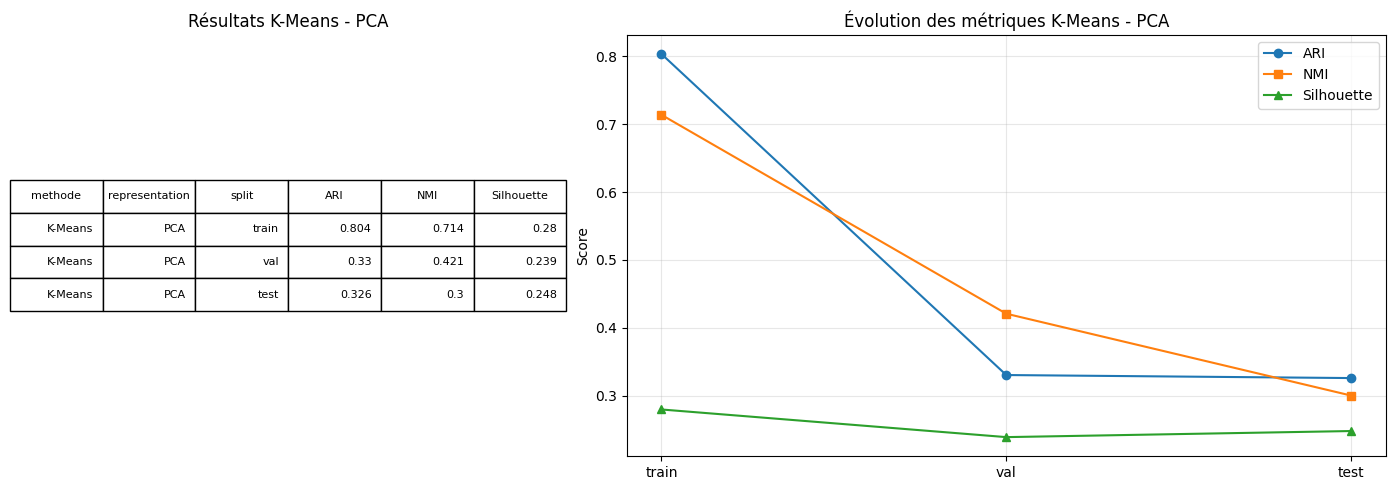

In [1749]:
# K-Means sur la représentation PCA retenue
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20
)

# Apprentissage uniquement sur le train PCA
kmeans.fit(train_pca)

kmeans_results = []

for split_name, X, y in [
    ("train", train_pca, train_labels),
    ("val", val_pca, val_labels),
    ("test", test_pca, test_labels)
]:

    clusters = kmeans.predict(X)

    kmeans_results.append({
        "methode": "K-Means",
        "representation": "PCA",
        "split": split_name,
        "ARI": adjusted_rand_score(y, clusters),
        "NMI": normalized_mutual_info_score(y, clusters),
        "Silhouette": silhouette_score(X, clusters)
    })

df_kmeans = pd.DataFrame(kmeans_results)

# Tableau + courbes K-Means
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
    gridspec_kw={"width_ratios": [1.2, 1.8]}
)

# Tableau
axes[0].axis("off")

table_data = df_kmeans.round(3)

table = axes[0].table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.1, 1.8)

axes[0].set_title("Résultats K-Means - PCA")

# Courbes
axes[1].plot(
    df_kmeans["split"],
    df_kmeans["ARI"],
    marker="o",
    label="ARI"
)

axes[1].plot(
    df_kmeans["split"],
    df_kmeans["NMI"],
    marker="s",
    label="NMI"
)

axes[1].plot(
    df_kmeans["split"],
    df_kmeans["Silhouette"],
    marker="^",
    label="Silhouette"
)

axes[1].set_ylabel("Score")
axes[1].set_title("Évolution des métriques K-Means - PCA")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

<h4 style="color:#48C9B0;">Analyse des performances de K-Means sur les embeddings PCA</h4>

Les résultats montrent que l'algorithme <b>K-Means</b> parvient à identifier une structure cohérente au sein des embeddings réduits par <b>PCA</b>. Sur le jeu d'entraînement, les performances sont élevées avec un <b>ARI de 0,804</b> et un <b>NMI de 0,714</b>, traduisant une forte concordance entre les clusters obtenus et les labels réels. Les embeddings extraits par <b>ResNet50</b> conservent ainsi des informations suffisamment discriminantes pour séparer les deux profils médicaux.

Les performances diminuent sur les jeux de validation et de test, avec un <b>ARI d'environ 0,33</b> et un <b>NMI compris entre 0,30 et 0,42</b>. Cette baisse était attendue compte tenu du faible nombre d'images annotées disponibles et traduit une capacité de généralisation plus limitée sur des données non utilisées lors de l'apprentissage.

Les scores de silhouette restent relativement stables entre les différents jeux de données, avec des valeurs comprises entre <b>0,24</b> et <b>0,28</b>. Bien que ces valeurs restent modestes, elles indiquent que les deux groupes présentent une cohésion interne satisfaisante tout en conservant un certain chevauchement, ce qui est cohérent avec la variabilité des images médicales.

<div style="border-left:5px solid #48C9B0;background:#f8fdfc;padding:14px 18px;margin:18px 0;color:black;">

<b>Conclusion</b><br>

Ces résultats montrent que <b>K-Means</b> capture correctement la structure principale des embeddings tout en conservant une bonne stabilité entre les différents jeux de données. Malgré une baisse des performances en validation et en test, les métriques obtenues restent suffisantes pour identifier des groupes cohérents qui serviront de base à la génération des pseudo-labels dans la phase d'apprentissage semi-supervisé.

</div>

<h4 style="color:#48C9B0;">4.2 Clustering hiérarchique</h4>

Le clustering hiérarchique constitue une alternative à K-Means ne reposant pas sur une optimisation itérative des centroïdes. Cette famille d'algorithmes construit progressivement une hiérarchie de regroupements en fusionnant les observations les plus proches selon un critère de liaison défini.

Contrairement à K-Means, cette approche ne suppose pas que les clusters soient nécessairement sphériques et permet d'explorer différentes stratégies de regroupement des embeddings.

<div style="border-left:5px solid #48C9B0;
background:#f8fdfc;
padding:14px 18px;
margin:18px 0;
color:black;">

<b>Objectif</b><br>

J'évalue plusieurs variantes du clustering hiérarchique sur la représentation <b>PCA à 6 composantes</b> afin d'étudier leur capacité à regrouper automatiquement les images selon leurs caractéristiques visuelles.

Les méthodes de liaison <i>Ward</i>, <i>Complete</i> et <i>Average</i> sont appliquées séparément aux jeux d'entraînement, de validation et de test. L'objectif est de déterminer laquelle produit les regroupements les plus cohérents avec les deux profils médicaux étudiés (<i>Normal</i> et <i>Cancer</i>).

Les performances sont évaluées à l'aide de l'<b>Adjusted Rand Index (ARI)</b>, de la <b>Normalized Mutual Information (NMI)</b> et du <b>score de silhouette</b>. Ces métriques permettent d'apprécier simultanément la correspondance entre les clusters et les labels réels ainsi que la qualité géométrique des regroupements obtenus.
</div>

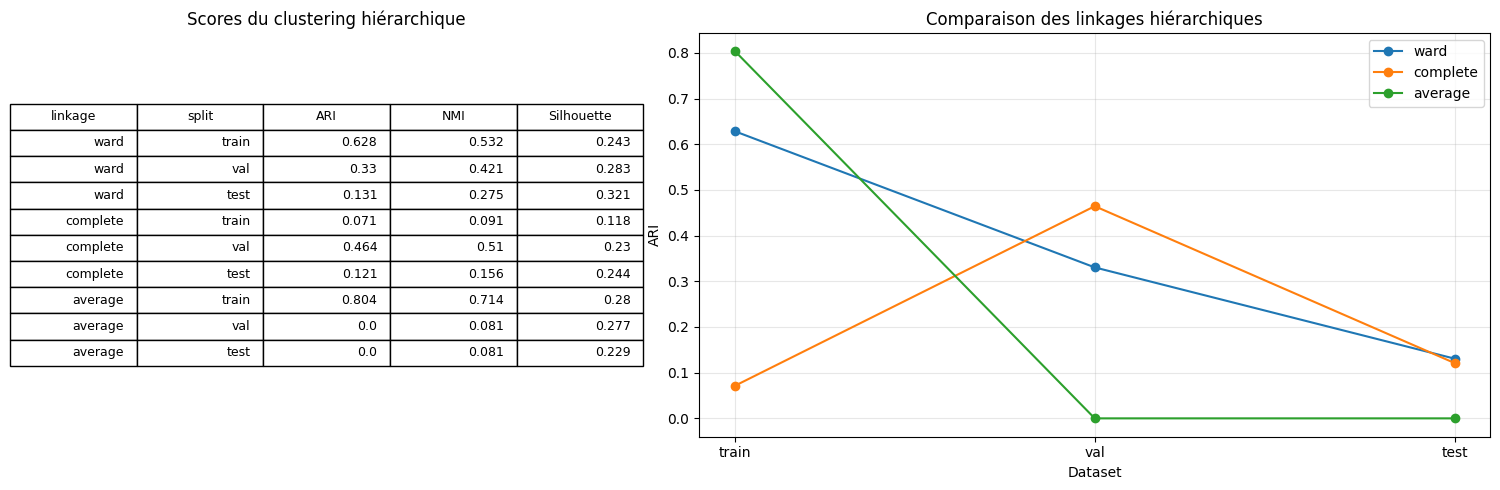

In [1750]:
# Clustering hiérarchique + tableau + graphique
# Représentation PCA retenue
linkages = ["ward", "complete", "average"]

hierarchical_results = []

for linkage in linkages:

    for split_name, X, y in [
        ("train", train_pca, train_labels),
        ("val", val_pca, val_labels),
        ("test", test_pca, test_labels)
    ]:
        model = AgglomerativeClustering(
            n_clusters=2,
            linkage=linkage
        )

        clusters = model.fit_predict(X)

        hierarchical_results.append({
            "methode": f"Hiérarchique - {linkage}",
            "linkage": linkage,
            "split": split_name,
            "ARI": adjusted_rand_score(y, clusters),
            "NMI": normalized_mutual_info_score(y, clusters),
            "Silhouette": silhouette_score(X, clusters)
        })

df_hierarchical = pd.DataFrame(hierarchical_results)

# Affichage tableau + graphique côte à côte
fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5),
    gridspec_kw={"width_ratios": [1.2, 1.8]}
)

# Tableau
axes[0].axis("off")

table_data = df_hierarchical[
    ["linkage", "split", "ARI", "NMI", "Silhouette"]
].round(3)

table = axes[0].table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.5)

axes[0].set_title("Scores du clustering hiérarchique")

# Graphique ARI par linkage
for linkage in linkages:
    data = df_hierarchical[
        df_hierarchical["linkage"] == linkage
    ]

    axes[1].plot(
        data["split"],
        data["ARI"],
        marker="o",
        label=linkage
    )

axes[1].set_xlabel("Dataset")
axes[1].set_ylabel("ARI")
axes[1].set_title("Comparaison des linkages hiérarchiques")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


<h4 style="color:#48C9B0;">Analyse du clustering hiérarchique</h4>

Trois stratégies de liaison ont été comparées pour le clustering hiérarchique : <b>Ward</b>, <b>Complete</b> et <b>Average</b>. Les performances ont été évaluées à l'aide des métriques <b>ARI</b>, <b>NMI</b> et <b>Silhouette</b> sur les jeux d'entraînement, de validation et de test.

La méthode <b>Average</b> obtient les meilleurs résultats sur le jeu d'entraînement avec un <b>ARI de 0,804</b> et un <b>NMI de 0,714</b>. En revanche, ses performances s'effondrent sur les jeux de validation et de test, ce qui traduit une très faible capacité de généralisation et suggère un surapprentissage de la structure du jeu d'entraînement.

La méthode <b>Ward</b> présente des performances plus équilibrées. Bien que ses résultats soient légèrement inférieurs sur le jeu d'entraînement (<b>ARI = 0,628</b>), elle conserve les meilleurs scores sur les jeux de validation et de test parmi les méthodes hiérarchiques évaluées. Elle apparaît ainsi comme la stratégie de liaison la plus robuste.

La méthode <b>Complete</b> obtient des résultats intermédiaires mais reste globalement moins performante que <b>Ward</b>. Les scores de silhouette demeurent par ailleurs relativement modestes pour les trois approches, ce qui confirme que la séparation entre les profils <i>Normal</i> et <i>Cancer</i> reste partielle dans l'espace des embeddings.

<div style="border-left:5px solid #48C9B0;background:#f8fdfc;padding:14px 18px;margin:18px 0;color:black;">

<b>Conclusion</b><br>

Parmi les méthodes hiérarchiques étudiées, <b>Ward</b> est retenue comme la plus robuste grâce à sa meilleure capacité de généralisation. Toutefois, contrairement à <b>K-Means</b>, elle ne permet pas d'attribuer directement un cluster à de nouvelles observations sans réentraîner ou adapter le modèle. Cette limitation la rend moins adaptée à la génération automatique de pseudo-labels sur les images non annotées. Pour cette raison, <b>K-Means</b> reste privilégié pour la suite du pipeline d'apprentissage semi-supervisé.

</div>

<h4 style="color:#48C9B0;">4.3 DBSCAN</h4>

DBSCAN (<i>Density-Based Spatial Clustering of Applications with Noise</i>) est un algorithme de clustering fondé sur la densité des observations. Contrairement à K-Means ou au clustering hiérarchique, il ne nécessite pas de fixer le nombre de clusters à l'avance et possède la capacité d'identifier automatiquement les observations isolées considérées comme du bruit.

Cette approche est particulièrement adaptée lorsque les groupes présentent des formes complexes ou lorsque certaines observations atypiques ne doivent appartenir à aucun cluster.

<div style="border-left:5px solid #48C9B0;
background:#f8fdfc;
padding:14px 18px;
margin:18px 0;
color:black;">

<b>Objectif</b><br>

J'évalue les performances de <b>DBSCAN</b> sur la représentation <b>PCA à 6 composantes</b> en faisant varier les paramètres <code>eps</code> (rayon de voisinage) et <code>min_samples</code> (nombre minimal de voisins). L'objectif est de déterminer si une approche basée sur la densité permet de mieux représenter la structure des embeddings que les méthodes précédemment étudiées.

Contrairement à K-Means et au clustering hiérarchique, DBSCAN est capable d'identifier automatiquement les observations atypiques en les classant comme du bruit plutôt que de les forcer à appartenir à un groupe. Cette propriété peut être particulièrement intéressante dans un contexte médical, où certaines images présentent des caractéristiques inhabituelles.

Les performances sont évaluées sur les jeux d'entraînement, de validation et de test à l'aide de l'<b>Adjusted Rand Index (ARI)</b>, de la <b>Normalized Mutual Information (NMI)</b>, du <b>score de silhouette</b> ainsi que du <b>taux d'observations identifiées comme bruit</b>. Cette analyse permettra d'évaluer si DBSCAN constitue une alternative pertinente aux méthodes de clustering précédemment étudiées.

</div>

In [1751]:
# DBSCAN : recherche des meilleurs couples eps / min_samples
# avec résultats valides sur train, validation et test
eps_values = [0.1, 0.2, 0.3, 0.5, 0.8, 1, 1.5, 2, 3]
min_samples_values = [3, 5, 10]

dbscan_results = []

for eps in eps_values:
    for min_samples in min_samples_values:

        for split_name, X, y in [
            ("train", train_pca, train_labels),
            ("val", val_pca, val_labels),
            ("test", test_pca, test_labels)
        ]:
            model = DBSCAN(
                eps=eps,
                min_samples=min_samples
            )

            clusters = model.fit_predict(X)

            n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
            noise_rate = np.mean(clusters == -1)

            if n_clusters > 1:
                ari = adjusted_rand_score(y, clusters)
                nmi = normalized_mutual_info_score(y, clusters)
                silhouette = silhouette_score(X, clusters)
            else:
                ari = np.nan
                nmi = np.nan
                silhouette = np.nan

            dbscan_results.append({
                "methode": "DBSCAN",
                "split": split_name,
                "eps": eps,
                "min_samples": min_samples,
                "n_clusters": n_clusters,
                "noise_rate": noise_rate,
                "ARI": ari,
                "NMI": nmi,
                "Silhouette": silhouette
            })

df_dbscan = pd.DataFrame(dbscan_results)

# Conservation uniquement des résultats valides
df_dbscan_valid = df_dbscan.dropna(
    subset=["ARI", "NMI", "Silhouette"]
).copy()

# Sélection des couples présents sur train, val et test
configs_completes = (
    df_dbscan_valid
    .groupby(["eps", "min_samples"])["split"]
    .nunique()
    .reset_index()
)

configs_completes = configs_completes[
    configs_completes["split"] == 3
][["eps", "min_samples"]]

df_dbscan_complete = df_dbscan_valid.merge(
    configs_completes,
    on=["eps", "min_samples"],
    how="inner"
)

# Classement des couples eps / min_samples
df_dbscan_resume = (
    df_dbscan_complete
    .groupby(["eps", "min_samples"], as_index=False)
    .agg({
        "ARI": "mean",
        "NMI": "mean",
        "Silhouette": "mean",
        "noise_rate": "mean"
    })
    .rename(columns={
        "ARI": "ARI_moyen",
        "NMI": "NMI_moyen",
        "Silhouette": "Silhouette_moyenne",
        "noise_rate": "noise_rate_moyen"
    })
)

top3_configs = (
    df_dbscan_resume
    .sort_values(
        ["ARI_moyen", "NMI_moyen", "Silhouette_moyenne"],
        ascending=False
    )
    .head(3)[["eps", "min_samples"]]
)

df_dbscan_top3 = (
    df_dbscan_complete
    .merge(
        top3_configs,
        on=["eps", "min_samples"],
        how="inner"
    )
    .sort_values(["eps", "min_samples", "split"])
)

df_dbscan_top3.round(3)

,methode,split,eps,min_samples,n_clusters,noise_rate,ARI,NMI,Silhouette


<h4 style="color:#48C9B0;">Interprétation des résultats</h4>

Aucune configuration de paramètres testée n'a permis à DBSCAN de produire simultanément des résultats exploitables sur les jeux d'entraînement, de validation et de test. Le tableau des meilleures configurations est vide, ce qui indique que les combinaisons de <i>eps</i> et <i>min_samples</i> évaluées n'ont pas généré au moins deux clusters cohérents sur l'ensemble des jeux de données.

Ce comportement suggère que les données projetées dans l'espace PCA ne présentent pas de zones de densité suffisamment marquées pour être correctement séparées par une approche basée sur la densité. DBSCAN tend probablement à fusionner les observations dans un unique groupe ou, au contraire, à considérer une part importante des données comme du bruit.

Dans ce contexte, DBSCAN apparaît moins adapté que K-Means ou le clustering hiérarchique pour identifier la structure des embeddings ResNet50. Cette méthode ne sera donc pas retenue pour la génération des pseudo-labels, les résultats obtenus étant insuffisamment stables et interprétables.

<h4 style="color:#48C9B0;">4.4 Spectral Clustering</h4>

Spectral Clustering est une méthode de clustering reposant sur une représentation des données sous forme de graphe reliant les observations les plus proches. Contrairement aux approches fondées uniquement sur les distances euclidiennes, la segmentation est réalisée à partir des propriétés spectrales de ce graphe, ce qui permet de mieux prendre en compte les relations de voisinage entre les observations.

Cette approche est particulièrement intéressante lorsque les groupes présentent des frontières complexes ou des structures non linéaires, susceptibles de ne pas être correctement identifiées par des méthodes telles que K-Means.

<div style="border-left:5px solid #48C9B0;
background:#f8fdfc;
padding:14px 18px;
margin:18px 0;
color:black;">

<b>Objectif</b><br>

J'évalue les performances du <b>Spectral Clustering</b> sur la représentation <b>PCA à 6 composantes</b> afin de déterminer si une approche fondée sur les relations de voisinage permet de mieux représenter la structure des embeddings extraits par ResNet50.

Le nombre de clusters est fixé à <b>deux</b> afin de rester cohérent avec le problème de classification étudié, qui distingue les profils médicaux <i>Normal</i> et <i>Cancer</i>. Les regroupements obtenus sont évalués sur les jeux d'entraînement, de validation et de test.

Les performances sont mesurées à l'aide de l'<b>Adjusted Rand Index (ARI)</b>, de la <b>Normalized Mutual Information (NMI)</b> et du <b>score de silhouette</b>. Cette analyse permettra de comparer les capacités de Spectral Clustering à celles de K-Means, du clustering hiérarchique et de DBSCAN afin d'identifier la méthode la plus adaptée à la génération des futurs pseudo-labels.

</div>

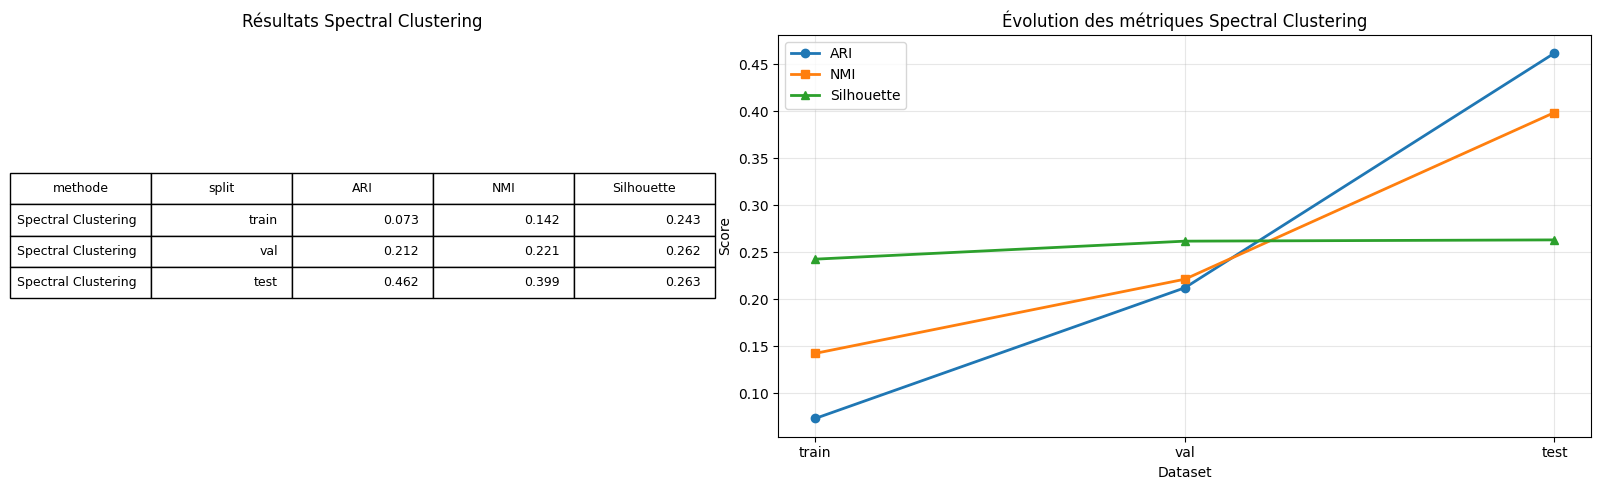

In [1752]:
from sklearn.cluster import SpectralClustering

spectral_results = []

for split_name, X, y in [
    ("train", train_pca, train_labels),
    ("val", val_pca, val_labels),
    ("test", test_pca, test_labels)
]:
    model = SpectralClustering(
        n_clusters=2,
        affinity="nearest_neighbors",
        random_state=42
    )

    clusters = model.fit_predict(X)

    spectral_results.append({
        "methode": "Spectral Clustering",
        "split": split_name,
        "ARI": adjusted_rand_score(y, clusters),
        "NMI": normalized_mutual_info_score(y, clusters),
        "Silhouette": silhouette_score(X, clusters)
    })

df_spectral = pd.DataFrame(spectral_results)

# Tableau + courbes Spectral Clustering
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 5),
    gridspec_kw={"width_ratios": [1.3, 1.8]}
)

# Tableau
axes[0].axis("off")

table_data = df_spectral.round(3)

table = axes[0].table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.8)

axes[0].set_title("Résultats Spectral Clustering")

# Courbes
axes[1].plot(
    df_spectral["split"],
    df_spectral["ARI"],
    marker="o",
    linewidth=2,
    label="ARI"
)

axes[1].plot(
    df_spectral["split"],
    df_spectral["NMI"],
    marker="s",
    linewidth=2,
    label="NMI"
)

axes[1].plot(
    df_spectral["split"],
    df_spectral["Silhouette"],
    marker="^",
    linewidth=2,
    label="Silhouette"
)

axes[1].set_xlabel("Dataset")
axes[1].set_ylabel("Score")
axes[1].set_title(
    "Évolution des métriques Spectral Clustering"
)

axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

<h4 style="color:#48C9B0;">Analyse du Spectral Clustering</h4>

Le <b>Spectral Clustering</b> a été évalué afin d'explorer une approche capable de capturer des relations plus complexes entre les observations grâce à une représentation sous forme de graphe.

Les performances obtenues sur le <b>jeu d'entraînement</b> restent faibles, avec un <b>ARI de 0,073</b> et un <b>NMI de 0,142</b>, montrant que cette méthode ne parvient pas à retrouver fidèlement les deux classes médicales à partir des embeddings utilisés. Les résultats s'améliorent sur le <b>jeu de validation</b> (<b>ARI = 0,212</b>, <b>NMI = 0,221</b>) puis atteignent leur meilleur niveau sur le <b>jeu de test</b>, avec un <b>ARI de 0,462</b> et un <b>NMI de 0,399</b>.

Les scores de silhouette restent quant à eux très stables, compris entre <b>0,243</b> et <b>0,263</b>, indiquant une qualité géométrique relativement constante des clusters malgré les variations observées sur les métriques ARI et NMI.

<div style="border-left:5px solid #48C9B0;background:#f8fdfc;padding:14px 18px;margin:18px 0;color:black;">

<b>Conclusion</b><br>

Malgré les bonnes performances obtenues sur le jeu de test, les résultats restent instables entre les différents jeux de données. Cette variabilité, liée notamment au faible nombre d'images annotées, ne permet pas de considérer le <b>Spectral Clustering</b> comme une méthode suffisamment robuste pour la génération de pseudo-labels.

Par ailleurs, contrairement à <b>K-Means</b>, cette approche ne dispose pas d'une méthode <code>predict()</code> permettant d'attribuer directement un cluster à de nouvelles observations. Elle nécessite de reconstruire le graphe de voisinage ou de recourir à des méthodes supplémentaires pour intégrer de nouvelles images.

Pour ces raisons, <b>K-Means</b> a été retenu pour la suite du projet. Bien que ses performances soient légèrement inférieures sur le jeu de test, il offre une meilleure stabilité globale et permet de pseudo-labelliser directement les images non annotées, propriété indispensable dans le cadre de l'approche semi-supervisée.

</div>

<h4 style="color:#48C9B0;">4.5 Comparaison des méthodes</h4>

Après avoir évalué individuellement chaque algorithme, je compare leurs performances afin d'identifier la méthode la plus adaptée à la génération de pseudo-labels. Toutes les approches sont appliquées aux mêmes embeddings issus de la <b>PCA</b> et évaluées dans des conditions identiques.

Cette comparaison s'appuie sur les métriques <b>Adjusted Rand Index (ARI)</b>, <b>Normalized Mutual Information (NMI)</b> et <b>score de silhouette</b>, qui permettent d'apprécier à la fois la cohérence des regroupements et leur qualité géométrique.

<div style="border-left:5px solid #48C9B0;
background:#f8fdfc;
padding:14px 18px;
margin:18px 0;
color:black;">

<b>Objectif</b><br>

Je compare les performances de <b>K-Means</b>, du <b>clustering hiérarchique</b>, de <b>DBSCAN</b> et du <b>Spectral Clustering</b> afin d'identifier la méthode offrant le meilleur compromis entre qualité des regroupements, stabilité des résultats et capacité à être intégrée dans le pipeline de pseudo-labellisation.

Cette analyse servira de base au choix du modèle de clustering retenu pour la suite de l'approche semi-supervisée.

</div>

In [1753]:
best_dbscan_train = (
    df_dbscan[df_dbscan["split"] == "train"]
    .sort_values(
        ["ARI", "NMI", "Silhouette"],
        ascending=False
    )
    .iloc[[0]]
)

comparatif_final_train = pd.concat([
    df_kmeans[df_kmeans["split"] == "train"],
    df_hierarchical[df_hierarchical["split"] == "train"],
    best_dbscan_train,
    df_spectral[df_spectral["split"] == "train"]
])

comparatif_final_train = comparatif_final_train.reset_index(drop=True)

<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color:black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br>

Je compare les meilleures configurations obtenues pour chaque algorithme de clustering afin d'identifier la méthode la plus adaptée à la génération de pseudo-labels. Une attention particulière est portée aux performances obtenues sur le <b>jeu de test</b>, qui permettent d'évaluer leur capacité à généraliser sur des données jamais utilisées lors de leur apprentissage.

Les différentes approches sont comparées à l'aide des métriques <b>ARI</b>, <b>NMI</b> et <b>Silhouette</b>, qui mesurent respectivement la cohérence entre les clusters et les labels réels ainsi que la qualité géométrique des regroupements.

Cette comparaison me permet de sélectionner le modèle offrant le meilleur compromis entre performances, stabilité et facilité d'intégration dans le pipeline de pseudo-labellisation.

</div>

In [1754]:
best_dbscan_test = (
    df_dbscan[df_dbscan["split"] == "test"]
    .sort_values(
        ["ARI", "NMI", "Silhouette"],
        ascending=False
    )
    .iloc[[0]]
)

comparatif_final_test = pd.concat([
    df_kmeans[df_kmeans["split"] == "test"],
    df_hierarchical[df_hierarchical["split"] == "test"],
    best_dbscan_test,
    df_spectral[df_spectral["split"] == "test"]
])

comparatif_final_test = comparatif_final_test.reset_index(drop=True)


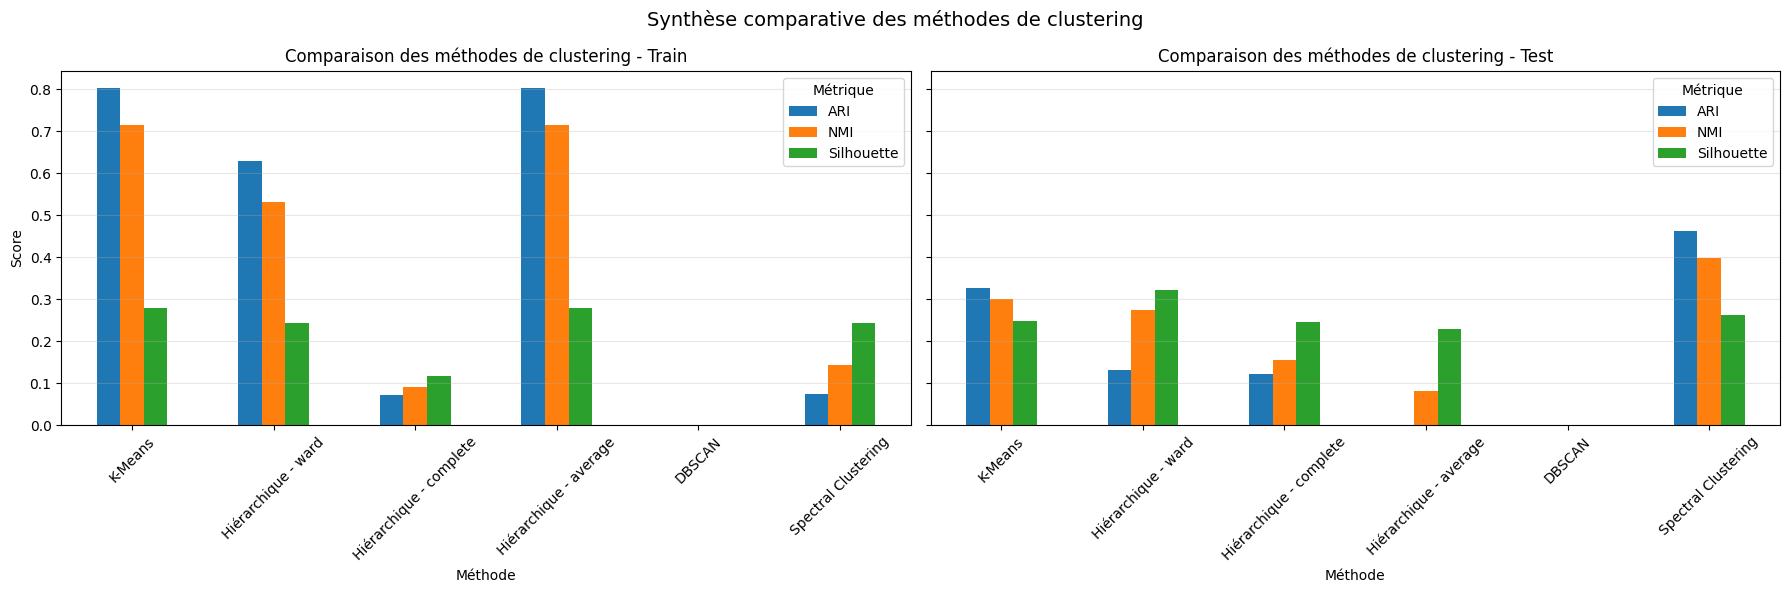

In [1755]:
# Préparation des données
comparatif_final_train_plot = comparatif_final_train.copy()
comparatif_final_test_plot = comparatif_final_test.reset_index(drop=True).copy()

# Noms plus lisibles si besoin
comparatif_final_train_plot["methode"] = comparatif_final_train_plot["methode"].fillna("DBSCAN")
comparatif_final_test_plot["methode"] = comparatif_final_test_plot["methode"].fillna("DBSCAN")

metrics = ["ARI", "NMI", "Silhouette"]

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

# Train
comparatif_final_train_plot.set_index("methode")[metrics].plot(
    kind="bar",
    ax=axes[0]
)

axes[0].set_title("Comparaison des méthodes de clustering - Train")
axes[0].set_xlabel("Méthode")
axes[0].set_ylabel("Score")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(axis="y", alpha=0.3)
axes[0].legend(title="Métrique")

# Test
comparatif_final_test_plot.set_index("methode")[metrics].plot(
    kind="bar",
    ax=axes[1]
)

axes[1].set_title("Comparaison des méthodes de clustering - Test")
axes[1].set_xlabel("Méthode")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(axis="y", alpha=0.3)
axes[1].legend(title="Métrique")

plt.suptitle("Synthèse comparative des méthodes de clustering", fontsize=14)
plt.tight_layout()
plt.show()

<h4 style="color:#48C9B0;">Comparaison des méthodes de clustering</h4>

Plusieurs approches de clustering ont été évaluées sur les embeddings réduits par PCA afin d'identifier la méthode la plus adaptée à la génération de pseudo-labels.

Sur le jeu d'entraînement, <b>K-Means</b> et le clustering hiérarchique avec liaison <b>Average</b> obtiennent les meilleurs résultats, avec un <b>ARI proche de 0,80</b> et un <b>NMI d'environ 0,71</b>. La méthode <b>Ward</b> présente également de bonnes performances, tandis que les variantes <b>Complete</b> et <b>DBSCAN</b> ne parviennent pas à retrouver correctement la structure des données.

Sur le jeu de test, <b>Spectral Clustering</b> obtient les meilleurs résultats, avec un <b>ARI d'environ 0,46</b> et un <b>NMI proche de 0,40</b>. <b>K-Means</b> conserve néanmoins des performances satisfaisantes (<b>ARI ≈ 0,33</b>, <b>NMI ≈ 0,30</b>), tandis que les différentes variantes du clustering hiérarchique et <b>DBSCAN</b> montrent une capacité de généralisation plus limitée.

Les scores de silhouette restent globalement modestes quelle que soit la méthode étudiée, ce qui traduit un chevauchement partiel entre les profils <i>Cancer</i> et <i>Normal</i>. Cette observation est cohérente avec la variabilité des images médicales et confirme que la séparation entre les deux classes demeure complexe.

<div style="border-left:5px solid #48C9B0;background:#f8fdfc;padding:14px 18px;margin:18px 0;color:black;">

<b>Choix retenu</b><br><br>

Bien que <b>Spectral Clustering</b> obtienne les meilleurs résultats sur le jeu de test, j'ai retenu <b>K-Means</b> pour la suite du projet. Contrairement aux autres méthodes évaluées, il permet d'attribuer directement un cluster à de nouvelles observations grâce à sa méthode <code>predict()</code>, propriété indispensable pour pseudo-labelliser automatiquement les images non annotées.

En complément, <b>K-Means</b> offre une mise en œuvre simple, un temps de calcul réduit et des résultats suffisamment robustes pour construire un pipeline reproductible. Il constitue ainsi le meilleur compromis entre performances, simplicité d'utilisation et capacité à être intégré dans l'approche semi-supervisée.

</div>

<h4 style="color:#48C9B0;">Choix du modèle de clustering retenu</h4>

Les performances obtenues ne constituent pas le seul critère de sélection. Le modèle retenu doit également être capable de s'intégrer au pipeline de pseudo-labellisation en attribuant automatiquement un cluster aux <b>plus de 1&nbsp;300 images non annotées</b> du projet.

Dans ce contexte, <b>K-Means</b> présente un avantage déterminant grâce à sa méthode <code>predict()</code>, qui permet d'affecter directement chaque nouvelle image au cluster le plus proche à partir des centroïdes appris sur le jeu d'entraînement. À l'inverse, les méthodes de <b>clustering hiérarchique</b> et le <b>Spectral Clustering</b> ne disposent pas naturellement de cette fonctionnalité et nécessitent la reconstruction du modèle ou des traitements complémentaires pour intégrer de nouvelles observations.

Même si <b>Spectral Clustering</b> obtient les meilleurs résultats sur le jeu de test, <b>K-Means</b> offre le meilleur compromis entre performances, simplicité de mise en œuvre, rapidité d'exécution et capacité à généraliser le clustering aux données non annotées.

Pour ces raisons, <b>K-Means est retenu pour la suite du projet</b>. Il servira à attribuer automatiquement un profil probable à chaque image non annotée avant le calcul d'un score de confiance et la génération des pseudo-labels utilisés lors de l'apprentissage semi-supervisé.

<h4 style="color:#48C9B0;">4.6 Recherche du nombre optimal de clusters pour K-Means</h4>

L'algorithme <b>K-Means</b> nécessite de définir au préalable le nombre de clusters à construire. Bien que le problème étudié comporte deux classes médicales (<i>Normal</i> et <i>Cancer</i>), il est important de vérifier que cette hypothèse reste cohérente avec l'organisation naturelle des embeddings.

Une analyse du <b>score de silhouette</b> est donc réalisée pour plusieurs valeurs de <i>K</i> afin d'évaluer la qualité intrinsèque des regroupements et de confirmer le choix retenu pour la suite des expérimentations.

<div style="border-left:5px solid #48C9B0;
background:#f8fdfc;
padding:14px 18px;
margin:18px 0;
color:black;">

<b>Objectif</b><br>

Je cherche à déterminer le nombre de clusters le plus adapté aux embeddings projetés par la <b>PCA à 6 composantes</b>, retenue lors de l'étape précédente. Pour cela, plusieurs valeurs de <i>K</i> sont évaluées à l'aide du <b>score de silhouette</b> calculé sur le jeu d'entraînement.

Le score de silhouette mesure simultanément la <b>compacité</b> des clusters et leur <b>séparation</b>. Une valeur élevée indique que les observations sont proches des points appartenant à leur propre groupe tout en restant éloignées des autres clusters, traduisant ainsi un meilleur partitionnement.

Cette analyse permet de vérifier si le choix de <b>deux clusters</b>, correspondant aux deux profils médicaux <i>Normal</i> et <i>Cancer</i>, est cohérent avec la structure des embeddings ou si un nombre différent de groupes permettrait de mieux représenter les données.

</div>

In [1756]:
kmeans_results = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    clusters = kmeans.fit_predict(train_pca)

    kmeans_results.append({
        "k": k,
        "silhouette_score": silhouette_score(
            train_pca,
            clusters
        )
    })

df_kmeans_results = pd.DataFrame(kmeans_results)
display(df_kmeans_results)

,k,silhouette_score
0,2,0.279636
1,3,0.307955
2,4,0.312480
3,5,0.305430
4,6,0.310991
5,7,0.323826
6,8,0.287880
7,9,0.299671
8,10,0.299546


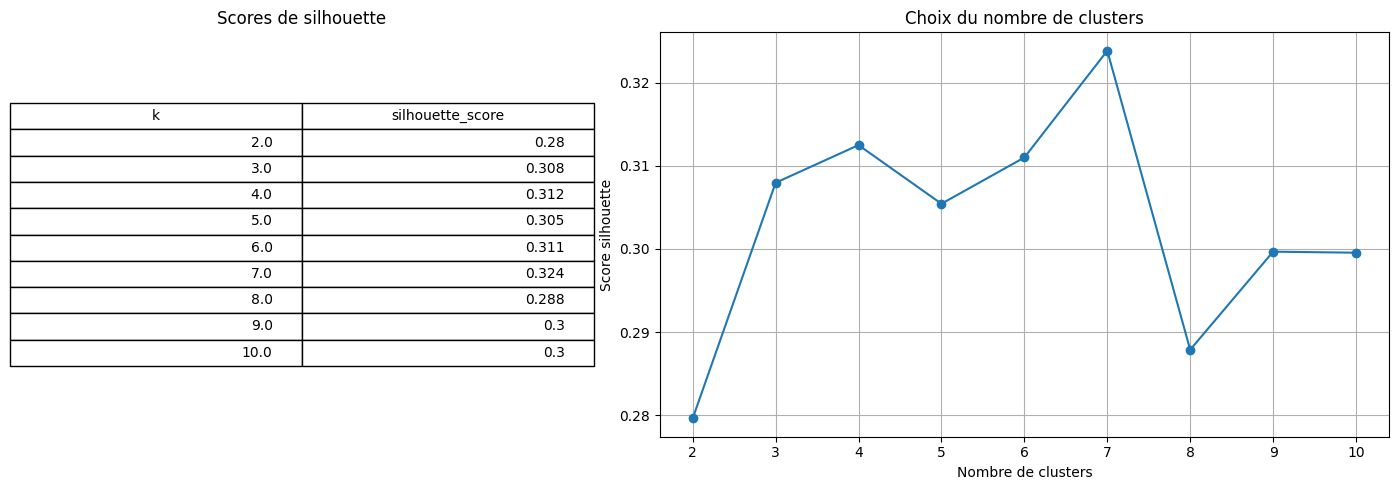

In [1757]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
    gridspec_kw={"width_ratios": [1, 1.5]}
)

# Tableau
axes[0].axis("off")

table = axes[0].table(
    cellText=df_kmeans_results.round(3).values,
    colLabels=df_kmeans_results.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

axes[0].set_title("Scores de silhouette")

# Graphique
axes[1].plot(
    df_kmeans_results["k"],
    df_kmeans_results["silhouette_score"],
    marker="o"
)

axes[1].set_xlabel("Nombre de clusters")
axes[1].set_ylabel("Score silhouette")
axes[1].set_title("Choix du nombre de clusters")
axes[1].grid(True)

plt.tight_layout()
plt.show()

<h4 style="color:#48C9B0;">Choix du nombre de clusters</h4>

L'analyse des scores de silhouette montre que la meilleure valeur est obtenue pour <b>k = 7</b>. Toutefois, les écarts entre les différentes valeurs de <i>K</i> restent relativement faibles, ce qui suggère qu'aucun nombre de clusters ne se distingue nettement comme une structure naturelle des données.

Le choix du nombre de clusters ne repose donc pas uniquement sur ce critère. L'objectif du projet est de générer des pseudo-labels destinés à entraîner un modèle de classification binaire distinguant les profils <i>Normal</i> et <i>Cancer</i>. L'utilisation d'un nombre élevé de clusters impliquerait une étape supplémentaire consistant à interpréter, fusionner ou mapper plusieurs groupes vers ces deux classes, augmentant ainsi la complexité du pipeline et le risque d'erreurs de pseudo-labellisation.

J'ai donc retenu <b>k = 2</b>, une configuration directement cohérente avec l'objectif de génération de pseudo-labels. Elle permet d'associer simplement chaque cluster à un profil médical tout en conservant une méthode facilement interprétable et reproductible.

<div style="border-left:5px solid #48C9B0;background:#f8fdfc;padding:14px 18px;margin:18px 0;color:black;">

<b>Choix retenu</b><br>

Bien que le score de silhouette soit légèrement supérieur pour <b>k = 7</b>, le gain obtenu reste limité (<b>0,324 contre 0,280</b>) et ne justifie pas la complexité supplémentaire induite par la gestion de plusieurs clusters.

Le choix de <b>k = 2</b> constitue ainsi le meilleur compromis entre qualité du partitionnement, simplicité d'interprétation et intégration dans le pipeline de pseudo-labellisation. Cette configuration permet d'associer directement chaque cluster à l'un des deux profils médicaux et facilite la génération automatique de pseudo-labels pour l'apprentissage semi-supervisé.

</div>

In [1758]:
k_optimal = 2

<h4 style="color:#48C9B0;">4.7 Analyse de la stabilité de K-Means</h4>

L'algorithme <b>K-Means</b> étant sensible à l'initialisation aléatoire de ses centroïdes, une même configuration peut produire des partitions légèrement différentes d'une exécution à l'autre. Il est donc nécessaire d'évaluer la stabilité du modèle avant de le retenir pour la génération des pseudo-labels.

<div style="border-left:5px solid #48C9B0;
background:#f8fdfc;
padding:14px 18px;
margin:18px 0;
color:black;">

<b>Objectif</b><br>

J'étudie l'influence du paramètre <code>n_init</code>, qui correspond au nombre d'initialisations aléatoires réalisées avant de conserver la meilleure solution.

Pour chaque valeur testée, <b>K-Means</b> est entraîné sur les embeddings projetés par la <b>PCA à 6 composantes</b>, puis évalué à l'aide de l'<b>Adjusted Rand Index (ARI)</b>. Cette analyse permet de vérifier si l'augmentation de <code>n_init</code> améliore la stabilité des résultats ou si un nombre plus faible d'initialisations suffit à obtenir des performances comparables.

Les résultats serviront à sélectionner la valeur de <code>n_init</code> utilisée pour le modèle final de génération des pseudo-labels.

</div>

In [1823]:
from sklearn.metrics import adjusted_rand_score

for n_init in [10, 20, 50, 100, 200]:

    kmeans = KMeans(
        n_clusters=2,
        n_init=n_init,
        random_state=42
    )

    clusters = kmeans.fit_predict(train_pca)

    ari = adjusted_rand_score(train_labels, clusters)

    print(f"n_init={n_init:3d} | ARI={ari:.4f}")

n_init= 10 | ARI=0.8036
n_init= 20 | ARI=0.8036
n_init= 50 | ARI=0.8036
n_init=100 | ARI=0.8036
n_init=200 | ARI=0.8036


<h4 style="color:#48C9B0;">Interprétation des résultats</h4>


Les résultats obtenus sont strictement identiques pour toutes les valeurs de <i>n_init</i> testées. L'ARI reste constant à 0,8036, que l'algorithme soit initialisé 10, 20, 50, 100 ou 200 fois.

Cette stabilité indique que la solution trouvée par K-Means est robuste et que l'algorithme converge systématiquement vers le même regroupement. L'initialisation aléatoire des centroïdes n'a donc pas d'influence significative sur les performances dans cette configuration.

J'ai retenu <i>n_init = 20</i> pour la suite du projet. Cette valeur offre un bon compromis entre coût de calcul et robustesse, sans gain mesurable à augmenter davantage le nombre d'initialisations.

<h4 style="color:#48C9B0;">4.8 Sélection du modèle final</h4>

À l'issue des différentes expérimentations, j'ai retenu le modèle offrant le meilleur compromis entre performances, stabilité, simplicité d'utilisation et capacité à être intégré dans le pipeline de pseudo-labellisation.

Ce modèle sera utilisé pour attribuer automatiquement un cluster à chaque image non annotée avant la génération des pseudo-labels destinés à l'apprentissage semi-supervisé.

<div style="border-left:5px solid #48C9B0;
background:#f8fdfc;
padding:14px 18px;
margin:18px 0;
color:black;">

<b>Choix retenu</b><br>

J'ai retenu un modèle <b>K-Means</b> entraîné sur les embeddings projetés par la <b>PCA à 6 composantes</b>, avec un nombre de clusters fixé à <b>K = 2</b> et <b>20 initialisations aléatoires (<code>n_init = 20</code>)</b>.

Bien que le score de silhouette atteigne son maximum pour un nombre de clusters plus élevé, les gains observés restent limités. Le choix de <b>K = 2</b> est donc privilégié afin de rester cohérent avec l'objectif du projet, qui consiste à générer des pseudo-labels correspondant aux deux profils médicaux <i>Normal</i> et <i>Cancer</i>.

L'analyse de stabilité montre par ailleurs que <code>n_init = 20</code> permet d'obtenir des résultats reproductibles tout en limitant l'influence de l'initialisation aléatoire des centroïdes.

Enfin, même si <b>Spectral Clustering</b> obtient les meilleurs résultats sur certaines métriques de test, <b>K-Means</b> est la seule méthode étudiée permettant d'attribuer directement un cluster à de nouvelles observations grâce à la méthode <code>predict()</code>. Cette propriété est indispensable pour pseudo-labelliser automatiquement l'ensemble des images non annotées à partir du modèle appris sur les données fortement labellisées.

Cette configuration constitue ainsi le meilleur compromis entre qualité du clustering, robustesse, simplicité de mise en œuvre et intégration dans le pipeline d'apprentissage semi-supervisé.

À partir de cette étape, les autres méthodes de clustering ne seront plus utilisées. Toutes les analyses suivantes reposent exclusivement sur ce modèle K-Means, qui servira à attribuer un cluster aux images non annotées, à générer les pseudo-labels, à calculer leur score de confiance puis à construire le jeu de données faiblement labellisé utilisé pour le pré-entraînement du modèle semi-supervisé.

</div>

<h4 style="color:#48C9B0;">4.9 Entraînement du modèle K-Means final</h4>

Le modèle K-Means retenu est désormais entraîné sur les embeddings du jeu d'entraînement fortement labellisé. Une fois ajusté, il est utilisé pour attribuer un cluster aux jeux de validation, de test et aux images non annotées, garantissant ainsi une représentation cohérente de l'ensemble des données.

<div style="border-left:5px solid #48C9B0;
background:#f8fdfc;
padding:14px 18px;
margin:18px 0;
color:black;">

<b>Objectif</b><br>

J'entraîne le modèle <b>K-Means</b> final à partir des embeddings réduits par la <b>PCA à 6 composantes</b>, avec les paramètres retenus (<b>K = 2</b> et <b>n_init = 20</b>).

L'apprentissage est réalisé exclusivement sur le jeu d'entraînement fortement labellisé afin d'éviter toute fuite d'information. Le modèle obtenu est ensuite utilisé pour prédire le cluster des jeux de validation, de test et des images non annotées.

Ces prédictions serviront directement à associer un profil probable à chaque image et constitueront la base de la génération des pseudo-labels ainsi que du calcul des scores de confiance.

</div>

In [1760]:
# KMeans final
# Entraînement uniquement sur le train labellisé
kmeans_final = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

# Apprentissage uniquement sur le train
kmeans_final.fit(train_pca)

# Prédictions sur les données labellisées
train_clusters = kmeans_final.predict(
    train_pca
)

val_clusters = kmeans_final.predict(
    val_pca
)

test_clusters = kmeans_final.predict(
    test_pca
)

# Prédictions sur les données non labellisées
train_unla_clusters = kmeans_final.predict(
    train_unla_pca
)

<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br>

Je rassemble dans un même tableau les résultats du clustering obtenus sur les jeux d'entraînement, de validation et de test.

Pour chaque image labellisée, je conserve le label réel, le cluster attribué par K-Means ainsi que les coordonnées de projection dans l'espace PCA. Cette structure facilitera l'analyse de la correspondance entre les clusters et les classes médicales réelles.

Ces informations serviront également à établir le mapping entre les clusters et les profils probables <i>Normal</i> ou <i>Cancer</i>, étape indispensable avant la pseudo-labellisation des données non annotées.

</div>

In [1761]:
# Résultats labellisés avec projection PCA
df_train_results = pd.DataFrame({
    "split": "train",
    "label_reel": train_labels,
    "cluster": train_clusters,
    "pca_1": train_pca[:, 0],
    "pca_2": train_pca[:, 1]
})

df_val_results = pd.DataFrame({
    "split": "val",
    "label_reel": val_labels,
    "cluster": val_clusters,
    "pca_1": val_pca[:, 0],
    "pca_2": val_pca[:, 1]
})

df_test_results = pd.DataFrame({
    "split": "test",
    "label_reel": test_labels,
    "cluster": test_clusters,
    "pca_1": test_pca[:, 0],
    "pca_2": test_pca[:, 1]
})

df_labeled_results = pd.concat(
    [
        df_train_results,
        df_val_results,
        df_test_results
    ],
    ignore_index=True
)

df_labeled_results.head()

,split,label_reel,cluster,pca_1,pca_2
0,train,1,1,27.247978,13.993297
1,train,1,1,5.832128,-25.373098
2,train,1,1,19.668020,-16.085997
3,train,0,0,-15.907005,0.513734
4,train,1,1,0.317445,-21.762442


In [1762]:
pd.crosstab(
    df_train_results["label_reel"],
    df_train_results["cluster"],
    margins=True
)

cluster,0,1,All
label_reel,,,
0,28,1,29
1,2,28,30
All,30,29,59


In [1763]:
# Résultats non labellisés avec projection PCA
df_train_unla_results = pd.DataFrame({
    "split": "train_unla",
    "cluster": train_unla_clusters,
    "pca_1": train_unla_pca[:, 0],
    "pca_2": train_unla_pca[:, 1]
})

df_train_unla_results.head()

,split,cluster,pca_1,pca_2
0,train_unla,1,6.766999,0.486715
1,train_unla,1,12.184685,4.883969
2,train_unla,1,11.988616,1.426672
3,train_unla,1,20.960814,8.840153
4,train_unla,1,9.053870,-21.930515


<h4 style="color:#48C9B0;">5. Analyse des clusters à partir des labels connus</h4>


<h4 style="color:#48C9B0;">5.1 Répartition des profils <i>Normal</i> et <i>Cancer</i></h4>

Avant de pouvoir utiliser les clusters pour générer des pseudo-labels, il est nécessaire d'interpréter leur signification à partir des données fortement labellisées. Cette étape consiste à comparer les clusters découverts automatiquement par K-Means aux labels médicaux réels afin d'identifier le profil majoritairement représenté dans chaque groupe.

L'objectif n'est plus d'évaluer les performances du clustering, mais de comprendre à quelle classe médicale correspond chaque cluster.

<div style="border-left:5px solid #48C9B0;
background:#f8fdfc;
padding:14px 18px;
margin:18px 0;
color:black;">

<b>Objectif</b><br>

Je cherche à analyser la composition de chaque cluster appris par <b>K-Means</b> sur le jeu d'entraînement fortement labellisé.

Pour chaque cluster, je calcule la proportion d'images appartenant aux profils <i>Normal</i> et <i>Cancer</i>. Cette analyse permet de déterminer si les regroupements découverts automatiquement correspondent majoritairement à l'une des deux classes médicales.

L'identification du profil dominant dans chaque cluster constitue une étape essentielle, puisqu'elle permettra d'associer chaque cluster à un profil médical probable et de générer ensuite des pseudo-labels pour les images non annotées.

</div>

In [1764]:
pd.crosstab(
    df_train_results["cluster"],
    df_train_results["label_reel"],
    normalize="index"
)

label_reel,0,1
cluster,,
0,0.933333,0.066667
1,0.034483,0.965517


In [1765]:
# Composition des clusters sur le train uniquement
cluster_label_table_train = pd.crosstab(
    df_train_results["cluster"],
    df_train_results["label_reel"],
    normalize="index"
)

cluster_label_table_train.columns = ["normal", "cancer"]

cluster_label_table_train

,normal,cancer
cluster,,
0,0.933333,0.066667
1,0.034483,0.965517


<h4 style="color:#48C9B0;">5.2 Analyse de la pureté des clusters</h4>

Afin d'évaluer la cohérence des clusters obtenus avec les classes médicales réelles, j'ai analysé la répartition des labels annotés <b>uniquement sur le jeu d'entraînement fortement labellisé</b>, utilisé pour entraîner le modèle K-Means. Cette approche permet d'éviter toute fuite d'information provenant des jeux de validation et de test.

Les résultats montrent une forte spécialisation des deux clusters. Le <b>cluster 0</b> est composé à <b>93,3 % d'images normales</b> contre seulement <b>6,7 % d'images cancéreuses</b>. À l'inverse, le <b>cluster 1</b> contient <b>96,6 % d'images cancéreuses</b> pour seulement <b>3,4 % d'images normales</b>.

Cette forte pureté indique que les groupes découverts automatiquement par K-Means correspondent largement aux deux profils médicaux recherchés. Malgré des scores ARI et NMI imparfaits, les clusters obtenus restent donc très cohérents avec les labels réels disponibles.

Les proportions de la classe majoritaire dans chaque cluster sont ensuite utilisées comme une <b>première estimation de la fiabilité du profil attribué</b>. Elles seront combinées, dans la section suivante, à la distance de chaque image à son centroïde afin de calculer un <b>score de confiance individuel</b> pour chaque pseudo-label.

Cette forte pureté constitue un élément déterminant pour la suite du projet, car elle justifie l'utilisation des clusters comme source de pseudo-labels pour les images non annotées dans l'approche semi-supervisée.

<h4 style="color:#48C9B0;">5.4 Mapping des clusters vers les profils médicaux</h4>

Une fois la composition et la pureté des clusters analysées, chaque groupe peut être associé au profil médical majoritairement représenté parmi les données fortement labellisées. Cette étape transforme les identifiants de clusters produits par K-Means en classes médicales interprétables.

Le mapping obtenu permettra ensuite d'attribuer automatiquement un profil probable à chaque image non annotée en fonction du cluster auquel elle appartient.

<div style="border-left:5px solid #48C9B0;
background:#f8fdfc;
color:black;
padding:14px 18px;
margin:18px 0;">

<b>Objectif</b><br>

À partir des analyses précédentes, j'associe chaque cluster au profil médical (<i>Normal</i> ou <i>Cancer</i>) qui y est majoritairement représenté.

Ce mapping permet de convertir les identifiants numériques des clusters en profils médicaux probables. Chaque nouvelle image pourra ainsi recevoir automatiquement un pseudo-label correspondant au profil associé à son cluster.

Cette correspondance constitue le lien entre la phase de clustering non supervisé et la phase de pseudo-labellisation présentée dans la section suivante.

</div>

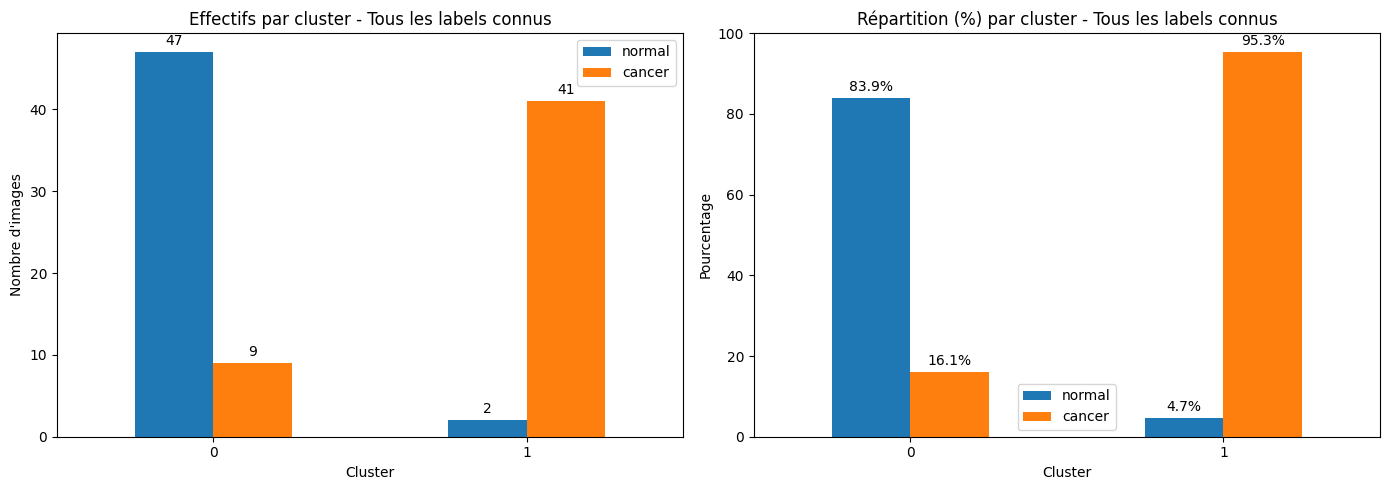

In [1766]:
cluster_counts = pd.crosstab(
    df_labeled_results["cluster"],
    df_labeled_results["label_reel"]
)

cluster_counts.columns = ["normal", "cancer"]

cluster_percentages = pd.crosstab(
    df_labeled_results["cluster"],
    df_labeled_results["label_reel"],
    normalize="index"
) * 100

cluster_percentages.columns = ["normal", "cancer"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Effectifs
cluster_counts.plot(
    kind="bar",
    ax=axes[0]
)

axes[0].set_title("Effectifs par cluster - Tous les labels connus")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Nombre d'images")
axes[0].tick_params(axis="x", rotation=0)

for container in axes[0].containers:
    axes[0].bar_label(
        container,
        fmt="%d",
        padding=3
    )

# Pourcentages
cluster_percentages.plot(
    kind="bar",
    ax=axes[1]
)

axes[1].set_title("Répartition (%) par cluster - Tous les labels connus")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Pourcentage")
axes[1].tick_params(axis="x", rotation=0)

for container in axes[1].containers:
    axes[1].bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

<h4 style="color:#48C9B0;">Interprétation des résultats</h4>

L'analyse de la composition des clusters, réalisée sur <b>l'ensemble des données fortement labellisées</b>, montre une forte correspondance entre les regroupements obtenus par <b>K-Means</b> et les diagnostics médicaux réels. Le <b>cluster 0</b> est composé majoritairement d'images <i>Normales</i>, avec <b>83,9&nbsp;%</b> d'images saines contre <b>16,1&nbsp;%</b> d'images cancéreuses.

À l'inverse, le <b>cluster 1</b> est constitué à <b>95,3&nbsp;%</b> d'images <i>Cancéreuses</i>, avec seulement <b>4,7&nbsp;%</b> d'images normales. Cette forte homogénéité montre que les embeddings extraits par <b>ResNet50</b>, puis réduits par la <b>PCA</b>, permettent à <b>K-Means</b> d'identifier des regroupements largement cohérents avec les classes médicales.

Le <b>cluster 0</b> est ainsi associé au profil probable <i>Normal</i>, tandis que le <b>cluster 1</b> est associé au profil probable <i>Cancer</i>. Les proportions de la classe majoritaire observées dans chaque cluster constituent une <b>première estimation de la fiabilité du profil attribué</b>. Elles seront ensuite combinées à la distance de chaque image à son centroïde afin de calculer un <b>score de confiance individuel</b> pour chaque pseudo-label.

<div style="border-left:5px solid #48C9B0;background:#f8fdfc;padding:14px 18px;margin:18px 0;color:black;">

<b>Conclusion</b><br>

Cette analyse confirme que les clusters observés sur les <b>données fortement labellisées</b> sont suffisamment représentatifs des deux profils médicaux pour servir de base à la pseudo-labellisation.Malgré la présence de quelques images appartenant à la classe minoritaire dans chaque cluster, leur forte pureté permet d'associer un profil probable fiable aux images non annotées avant le calcul d'un score de confiance individuel.

</div>

In [1767]:
# Table cluster / vrai label
cluster_label_table = pd.crosstab(
    df_labeled_results["cluster"],
    df_labeled_results["label_reel"]
)

display(cluster_label_table)

# Mapping cluster -> label majoritaire
cluster_to_label = (
    cluster_label_table
    .idxmax(axis=1)
    .to_dict()
)

# Mapping cluster -> profil texte
cluster_to_profil = {
    cluster: "normal" if label == 0 else "cancer"
    for cluster, label in cluster_to_label.items()
}

print("Mapping cluster -> label :", cluster_to_label)
print("Mapping cluster -> profil :", cluster_to_profil)

label_reel,0,1
cluster,,
0,47,9
1,2,41


Mapping cluster -> label : {0: 0, 1: 1}
Mapping cluster -> profil : {0: 'normal', 1: 'cancer'}


<h2 style="color:#48C9B0;">6 Pseudo-labellisation </h2>

<h4 style="color:#48C9B0;">6.1 Attribution des pseudo-labels</h4>

Une fois le mapping entre les clusters et les profils médicaux établi, il devient possible d'attribuer automatiquement un pseudo-label à chaque image non annotée. Chaque observation est d'abord affectée à l'un des deux clusters par le modèle K-Means, puis reçoit le profil médical correspondant au cluster auquel elle appartient.

Cette étape permet de transformer les regroupements obtenus par l'apprentissage non supervisé en annotations exploitables pour l'entraînement du modèle semi-supervisé.

<div style="border-left:5px solid #48C9B0;
background:#f8fdfc;
color:black;
padding:14px 18px;
margin:18px 0;">

<b>Objectif</b><br>

J'utilise le modèle <b>K-Means</b> entraîné ainsi que le mapping défini à partir des données fortement labellisées pour attribuer un pseudo-label à chacune des images non annotées.

Chaque image est projetée dans l'espace <b>PCA</b>, puis affectée à l'un des deux clusters grâce à la méthode <code>predict()</code>. Le cluster prédit est ensuite converti en un profil médical probable (<i>Normal</i> ou <i>Cancer</i>) à l'aide du mapping établi précédemment.

Cette procédure permet de constituer un premier jeu de données faiblement labellisées, qui sera ensuite filtré selon un score de confiance afin de ne conserver que les pseudo-labels les plus fiables pour l'apprentissage semi-supervisé.

</div>

In [1768]:
df_train_unla_results["profil_probable"] = (
    df_train_unla_results["cluster"]
    .map(cluster_to_profil)
)

df_train_unla_results.head()

,split,cluster,pca_1,pca_2,profil_probable
0,train_unla,1,6.766999,0.486715,cancer
1,train_unla,1,12.184685,4.883969,cancer
2,train_unla,1,11.988616,1.426672,cancer
3,train_unla,1,20.960814,8.840153,cancer
4,train_unla,1,9.053870,-21.930515,cancer


<h4 style="color:#48C9B0;">Interprétation des résultats</h4>

Les clusters identifiés par K-Means ont été convertis en profils médicaux probables à l'aide du mapping construit à partir des données labellisées. Chaque image non annotée hérite ainsi du profil majoritaire associé à son cluster d'appartenance.

Le tableau obtenu montre que les données non labellisées disposent désormais d'un pseudo-label exploitable pour les étapes suivantes du projet. En plus du profil probable attribué, les coordonnées PCA et l'identifiant du cluster sont conservés afin de permettre le calcul ultérieur de scores de confiance.

Cette transformation constitue la première étape de la pseudo-labellisation. Les images non annotées sont désormais associées à un profil <i>Normal</i> ou <i>Cancer</i>, mais toutes ne présentent pas le même niveau de fiabilité. Une phase supplémentaire sera donc nécessaire pour estimer la confiance de chaque pseudo-label et sélectionner uniquement les observations les plus pertinentes pour l'apprentissage semi-supervisé.

<h4 style="color:#48C9B0;">6.2 Analyse des images non annotées</h4>

Une fois les pseudo-labels attribués, il est nécessaire d'examiner leur répartition au sein des données initialement non annotées. Cette analyse permet d'obtenir une première vision du comportement du modèle de clustering sur un grand volume d'images ne disposant pas de vérité terrain.

La distribution des profils probables constitue également un indicateur important de la qualité de la pseudo-labellisation avant la mise en place d'un filtrage par score de confiance.

<div style="border-left:5px solid #48C9B0;
background:#f8fdfc;
color:black;
padding:14px 18px;
margin:18px 0;">

<b>Objectif</b><br>

J'analyse la répartition des profils probables (<i>Normal</i> et <i>Cancer</i>) attribués aux images non annotées après application du modèle <b>K-Means</b> et du mapping défini à partir des données fortement labellisées.

Cette analyse permet de vérifier si la pseudo-labellisation conduit à une distribution cohérente des classes ou si l'une d'elles est largement surreprésentée. Un déséquilibre important pourrait traduire un biais du modèle de clustering ou une structure particulière du jeu de données.

Cette étape constitue une première validation qualitative des pseudo-labels avant le calcul du score de confiance, qui permettra ensuite de ne conserver que les observations les plus fiables pour l'apprentissage semi-supervisé.

</div>

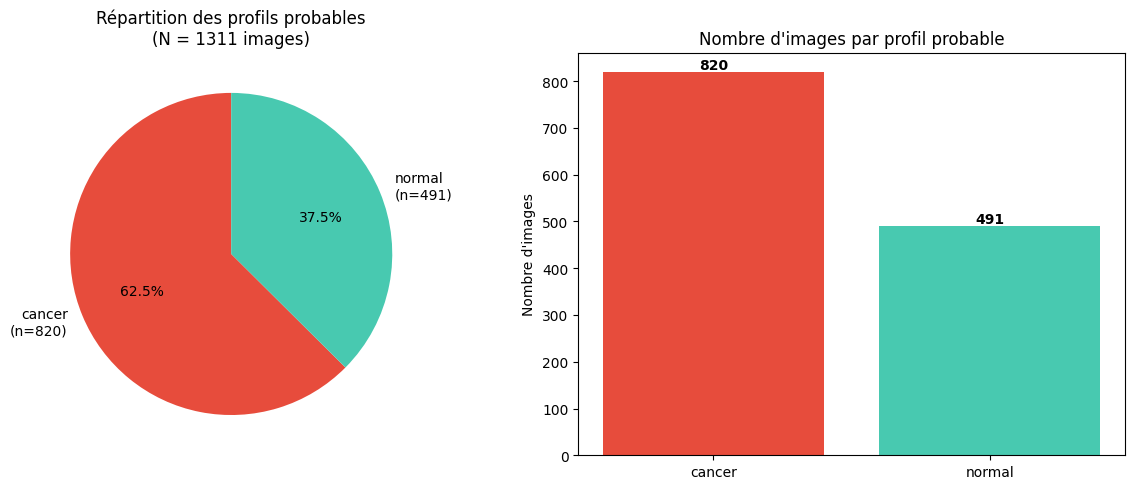

In [1769]:
# Nombre d'images par profil probable
cluster_counts = (
    df_train_unla_results["profil_probable"]
    .value_counts()
)

# Pourcentage d'images par profil probable
cluster_percent = (
    df_train_unla_results["profil_probable"]
    .value_counts(normalize=True)
    * 100
)

# Nombre total d'images pseudo-labellisées
total_images = cluster_counts.sum()

colors = {
    "normal": "#48C9B0",
    "cancer": "#E74C3C"
}

# Conservation de l'ordre des labels
ordered_labels = cluster_counts.index.tolist()

# Liste des couleurs correspondant aux labels
plot_colors = [
    colors.get(label, "gray")
    for label in ordered_labels
]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

# Camembert
axes[0].pie(
    cluster_counts,
    labels=[
        f"{label}\n(n={count})"
        for label, count in zip(
            ordered_labels,
            cluster_counts.values
        )
    ],
    autopct="%1.1f%%",
    startangle=90,
    colors=plot_colors
)

axes[0].set_title(
    f"Répartition des profils probables\n"
    f"(N = {total_images} images)"
)

# Histogramme
bars = axes[1].bar(
    ordered_labels,
    cluster_counts.values,
    color=plot_colors
)

# Affichage du nombre d'images au-dessus de chaque barre
for bar in bars:

    hauteur = bar.get_height()

    axes[1].text(
        x=bar.get_x() + bar.get_width() / 2,
        y=hauteur,
        s=f"{int(hauteur)}",
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=10
    )

axes[1].set_title(
    "Nombre d'images par profil probable"
)

axes[1].set_ylabel(
    "Nombre d'images"
)

plt.tight_layout()
plt.show()

<h4 style="color:#48C9B0;">Interprétation des résultats</h4>

Après application du clustering et du mapping des clusters vers les classes médicales, les <b>1 311 images non annotées</b> ont pu être associées à un profil probable. La majorité des observations est attribuée au profil <i>Cancer</i>, avec <b>820 images (62,5 %)</b>, contre <b>491 images (37,5 %)</b> pour le profil <i>Normal</i>.

Cette répartition montre que les données non annotées présentent un déséquilibre en faveur du profil <i>Cancer</i>. Les embeddings d'une proportion importante d'images se rapprochent davantage du cluster associé aux caractéristiques observées chez les patients atteints d'un cancer.

Cette distribution ne doit toutefois pas être interprétée comme une estimation de la prévalence réelle de la maladie dans la population. Elle reflète uniquement la structure identifiée par le modèle de clustering dans l'espace des embeddings extraits par ResNet50.

Afin d'éviter qu'une classe ne domine excessivement l'apprentissage semi-supervisé, la sélection des pseudo-labels reposera sur un score de confiance et sur une sélection équilibrée des observations les plus fiables pour chaque profil. Cette stratégie permettra de limiter l'impact du déséquilibre observé tout en conservant les images les plus représentatives de chaque groupe.

<h4 style="color:#48C9B0;">6.3 Visualisation des pseudo-labels dans l'espace PCA</h4>

Les données fortement labellisées et les images pseudo-labellisées sont projetées simultanément dans l'espace réduit obtenu par la PCA. Cette représentation permet de comparer visuellement leur répartition et d'observer si les profils probables attribués aux données non annotées sont cohérents avec l'organisation des données de référence.

Bien que cette analyse reste qualitative, elle constitue une étape de validation complémentaire avant le calcul du score de confiance.

<div style="border-left:5px solid #48C9B0;
background:#f8fdfc;
color:black;
padding:14px 18px;
margin:18px 0;">

<b>Objectif</b><br><br>

<p style="line-height:1.7;">

Je projette simultanément les images fortement labellisées et les images pseudo-labellisées dans l'espace <b>PCA à 2 composantes</b> afin d'observer leur positionnement relatif au sein des embeddings.

Les labels réels et les profils probables sont représentés séparément pour vérifier si les images non annotées s'intègrent naturellement aux groupes identifiés lors de l'analyse des données fortement labellisées. Cette comparaison permet d'évaluer visuellement la cohérence de la pseudo-labellisation produite par le modèle de clustering.

L'objectif est de m'assurer que les pseudo-labels suivent une organisation compatible avec celle observée sur les données annotées avant de calculer un score de confiance et de sélectionner les observations les plus fiables pour l'apprentissage semi-supervisé.

</p>

</div>

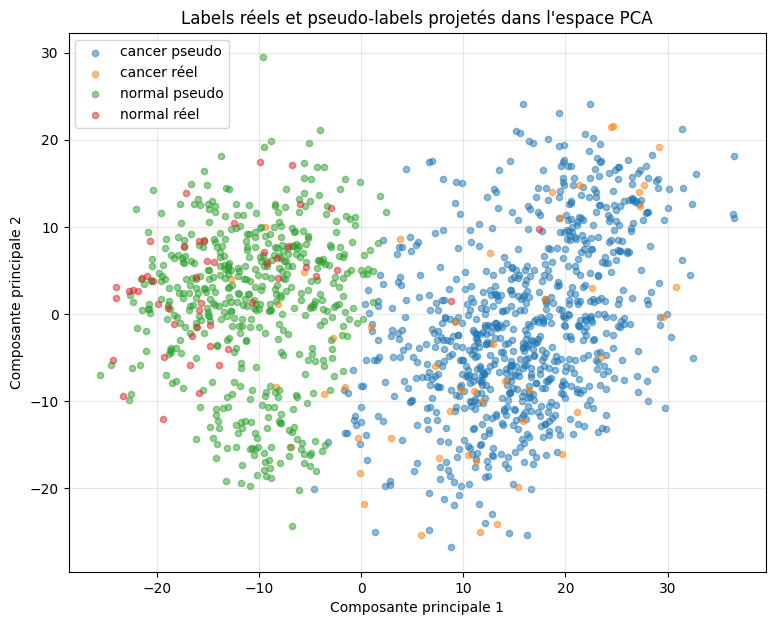

In [1770]:
# Vrais labels pour les données labellisées
df_labeled_results["profil"] = df_labeled_results["label_reel"].map({
    0: "normal réel",
    1: "cancer réel"
})

# Pseudo-labels pour les données non labellisées
df_train_unla_results["profil"] = df_train_unla_results["profil_probable"].map({
    "normal": "normal pseudo",
    "cancer": "cancer pseudo"
})

df_results = pd.concat(
    [df_labeled_results, df_train_unla_results],
    ignore_index=True
)

plt.figure(figsize=(9, 7))

for profil in sorted(df_results["profil"].dropna().unique()):

    mask = df_results["profil"] == profil

    plt.scatter(
        df_results.loc[mask, "pca_1"],
        df_results.loc[mask, "pca_2"],
        label=profil,
        alpha=0.5,
        s=20
    )

plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title("Labels réels et pseudo-labels projetés dans l'espace PCA")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

<h4 style="color:#48C9B0;">Interprétation des résultats</h4>

<p style="line-height:1.7;">
La projection conjointe des données labellisées et pseudo-labellisées met en évidence une forte cohérence entre les profils attribués par le clustering et la structure observée sur les données réelles. Les pseudo-labels <i>normal pseudo</i> et <i>cancer pseudo</i> occupent majoritairement les mêmes régions de l'espace PCA que les observations annotées correspondantes.
</p>

<p style="line-height:1.7;"><b>
Les images associées au profil <i>Normal</i> se concentrent principalement dans la partie gauche de la projection, tandis que les images associées au profil <i>Cancer</i> occupent majoritairement la partie droite. Cette organisation est cohérente avec la séparation déjà observée lors de l'analyse des embeddings ResNet50 et suggère une cohérence partielle entre les pseudo-labels et les labels connus.
</b></p>

<p style="line-height:1.7;">
On observe néanmoins quelques points situés à proximité de la frontière entre les deux groupes. Ces observations correspondent probablement à des cas plus ambigus pour lesquels le niveau de confiance devra être examiné avec attention. Elles justifient la mise en place d'un mécanisme de sélection basé sur un score de confiance plutôt que l'utilisation directe de l'ensemble des pseudo-labels.
</p>

<p style="line-height:1.7;">
Dans l'ensemble, cette visualisation constitue un indicateur favorable pour la suite du projet. Les pseudo-labels suivent globalement la même organisation que les labels réels, ce qui suggère que les données non annotées pourront enrichir le jeu d'entraînement semi-supervisé à condition de conserver uniquement les observations les plus fiables.
</p>

<h4 style="color:#48C9B0;">6.4 Calcul du score de confiance</h4>

Les pseudo-labels générés par le clustering ne présentent pas tous le même niveau de fiabilité. Afin de limiter l'introduction d'erreurs dans l'apprentissage semi-supervisé, un score de confiance est calculé pour chaque image non annotée.

Ce score repose sur plusieurs indicateurs complémentaires permettant d'estimer dans quelle mesure une image est représentative du cluster auquel elle a été affectée.

<div style="border-left:5px solid #48C9B0;
background:#f8fdfc;
color:black;
padding:14px 18px;
margin:18px 0;">

<b>Objectif</b><br>

Je calcule un score de confiance pour chaque image pseudo-labellisée afin d'estimer la fiabilité du profil médical qui lui a été attribué.

Cette confiance est évaluée à partir de plusieurs critères complémentaires, notamment la distance entre l'image et le centroïde de son cluster ainsi que la pureté du cluster auquel elle appartient. Une image proche du centroïde d'un cluster très homogène est considérée comme plus fiable qu'une observation située à proximité de la frontière entre deux groupes.

L'objectif est de classer les pseudo-labels selon leur niveau de confiance afin de ne conserver que les observations les plus fiables pour l'entraînement du modèle semi-supervisé.

</div>

<h4 style="color:#48C9B0;">La distance centroïde</h4>

In [1771]:
def compute_distance_confidence(
    distance_cluster_0,
    distance_cluster_1,
    epsilon=1e-8
):

    # Calcule un score de confiance à partir des distances
    # aux deux centroïdes d'un K-Means.

    # Score de confiance compris entre 0 et 1.
    # - 0 : image proche de la frontière entre les clusters.
    # - 1 : image clairement associée à un cluster.

    distance_cluster_0 = np.asarray(distance_cluster_0)
    distance_cluster_1 = np.asarray(distance_cluster_1)

    confiance_ditance_calc = (
        np.abs(distance_cluster_0 - distance_cluster_1)
        / (distance_cluster_0 + distance_cluster_1 + epsilon)
    )
    
    return confiance_ditance_calc 

In [1772]:
# Vérification de cohérence
print("Nombre d'images non labellisées :", len(train_unla_pca))
print("Nombre de lignes dans df_train_unla_results :", len(df_train_unla_results))

assert len(train_unla_pca) == len(df_train_unla_results), \
    "Incohérence entre les features PCA et le DataFrame train_unla."

# Prédiction des clusters K-Means
df_train_unla_results["cluster"] = kmeans_final.predict(train_unla_pca)

# Distances aux centroïdes
distances_to_centers = kmeans_final.transform(train_unla_pca)

df_train_unla_results["distance_cluster_0"] = distances_to_centers[:, 0]
df_train_unla_results["distance_cluster_1"] = distances_to_centers[:, 1]

# Distance au centroïde attribué
df_train_unla_results["distance_centroid"] = distances_to_centers.min(axis=1)

# Score de confiance par séparation relative
df_train_unla_results["confiance_distance"] = compute_distance_confidence(
    df_train_unla_results["distance_cluster_0"],
    df_train_unla_results["distance_cluster_1"]
)

# Profil probable associé à chaque cluster
df_train_unla_results["profil_probable"] = (
    df_train_unla_results["cluster"].map(cluster_to_profil)
)

# Label numérique associé
df_train_unla_results["label"] = df_train_unla_results["profil_probable"].map({
    "normal": 0,
    "cancer": 1
})

# Sécurités
assert df_train_unla_results["profil_probable"].notna().all(), \
    "Certains clusters n'ont pas de profil associé."

assert df_train_unla_results["label"].isin([0, 1]).all(), \
    "Certains labels pseudo-labellisés sont invalides."

# Affichage des pseudo-labels les plus fiables
df_train_unla_results.sort_values(
    "confiance_distance",
    ascending=False
).head(10)

Nombre d'images non labellisées : 1311
Nombre de lignes dans df_train_unla_results : 1311


,split,cluster,pca_1,pca_2,profil_probable,profil,distance_cluster_0,distance_cluster_1,distance_centroid,confiance_distance,label
322,train_unla,0,-14.308775,8.273615,normal,normal pseudo,5.909731,32.589062,5.909731,0.692991,0
53,train_unla,1,15.988368,-5.810276,cancer,cancer pseudo,33.011059,6.195561,6.195561,0.683953,1
83,train_unla,0,-16.586664,4.172316,normal,normal pseudo,6.523909,34.062344,6.523909,0.678516,0
1144,train_unla,1,18.047651,0.539159,cancer,cancer pseudo,33.882183,6.837281,6.837281,0.664176,1
610,train_unla,0,-13.609781,7.777302,normal,normal pseudo,6.533205,31.993092,6.533205,0.660844,0
965,train_unla,0,-12.744390,1.359014,normal,normal pseudo,6.435346,29.853102,6.435346,0.645323,0
779,train_unla,1,17.676777,-4.112270,cancer,cancer pseudo,34.851688,7.797211,7.797211,0.634353,1
698,train_unla,0,-14.647900,3.096051,normal,normal pseudo,7.514627,32.404980,7.514627,0.623512,0
418,train_unla,0,-15.991271,2.464705,normal,normal pseudo,8.266197,33.633911,8.266197,0.605433,0
212,train_unla,1,16.937809,-9.914498,cancer,cancer pseudo,35.592422,8.909013,8.909013,0.599608,1


<h4 style="color:#48C9B0;">Interprétation du score de confiance basé sur la distance</h4>

Après l'attribution des clusters, un score de confiance est calculé pour chaque image non annotée afin d'estimer la fiabilité du pseudo-label obtenu. Ce score repose sur la position de l'image par rapport aux deux centroïdes appris par K-Means.

Pour chaque observation, l'algorithme calcule la distance au centroïde du cluster 0 et la distance au centroïde du cluster 1. Le score de confiance est ensuite défini comme le rapport entre l'écart de ces deux distances et leur somme :

<p style="text-align:center; font-size:18px;">
<b>Confiance = |d<sub>0</sub> - d<sub>1</sub>| / (d<sub>0</sub> + d<sub>1</sub>)</b>
</p>

Cette mesure traduit le niveau de séparation entre les deux clusters pour une image donnée. Lorsque les deux distances sont très proches, l'image se situe près de la frontière entre les groupes et le score tend vers 0. À l'inverse, lorsqu'une image est nettement plus proche d'un centroïde que de l'autre, le score augmente et le pseudo-label devient plus fiable.

Les valeurs observées restent relativement modérées. Cela s'explique par le chevauchement partiel des deux profils médicaux dans l'espace des embeddings. Les images les plus fiables ne sont donc pas celles présentant une séparation parfaite entre les clusters, mais celles dont l'appartenance à un groupe est la plus marquée relativement aux autres observations.

Ce score ne constitue pas à lui seul une probabilité d'appartenance à une classe. Il représente plutôt un indicateur relatif de certitude permettant de classer les images du plus fiable au moins fiable avant la phase de sélection des pseudo-labels.


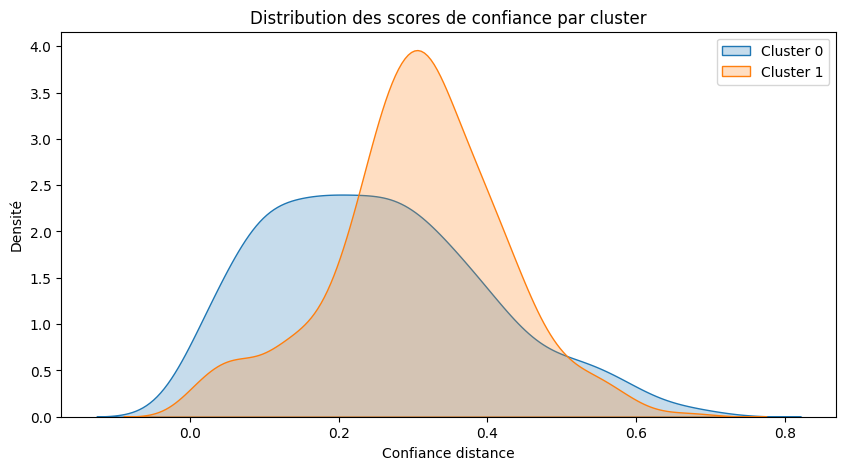

In [1773]:
plt.figure(figsize=(10,5))

for cluster in sorted(df_train_unla_results["cluster"].unique()):
    sns.kdeplot(
        data=df_train_unla_results[
            df_train_unla_results["cluster"] == cluster
        ],
        x="confiance_distance",
        fill=True,
        label=f"Cluster {cluster}"
    )

plt.title("Distribution des scores de confiance par cluster")
plt.xlabel("Confiance distance")
plt.ylabel("Densité")
plt.legend()
plt.show()

<h4 style="color:#48C9B0;">Interprétation des résultats</h4>

Les distributions montrent que la majorité des images non annotées présentent un <b>score de confiance basé sur la distance compris entre 0,20 et 0,40</b>. Les valeurs les plus élevées correspondent aux images nettement plus proches de leur centroïde que du centroïde opposé, tandis que les faibles scores traduisent une position plus ambiguë entre les deux groupes.

Le <b>cluster 1</b>, associé au profil <i>Cancer</i>, présente une distribution légèrement décalée vers les scores les plus élevés. Les images appartenant à ce cluster sont donc, en moyenne, mieux séparées du cluster opposé. Cette observation est cohérente avec sa pureté plus élevée observée précédemment.

Les deux distributions présentent néanmoins une zone de recouvrement importante. Les images situées dans cette région sont proches des deux centroïdes et leur affectation à un cluster est donc plus incertaine. À l'inverse, les observations situées dans les queues droites des distributions correspondent aux pseudo-labels les plus fiables du point de vue de la séparation géométrique.

<div style="border-left:5px solid #48C9B0;background:#f8fdfc;padding:14px 18px;margin:18px 0;color:black;">

<b>Conclusion</b><br>

Cette analyse montre que la distance aux centroïdes fournit un indicateur pertinent de la qualité de l'affectation d'une image à son cluster. Ce score ne sera toutefois pas utilisé seul : il sera combiné, dans la section suivante, avec la <b>pureté de chaque cluster</b> afin de construire un score de confiance final plus robuste pour la sélection des pseudo-labels.

</div>

In [1824]:
df_train_unla_results.groupby(
    "profil_probable"
)["confiance_distance"].describe().round(3)

,count,mean,std,min,25%,50%,75%,max
profil_probable,,,,,,,,
cancer,820.0,0.306,0.116,0.002,0.244,0.310,0.377,0.684
normal,491.0,0.249,0.148,0.003,0.129,0.235,0.343,0.693


<h4 style="color:#48C9B0;">Interprétation des résultats</h4>

Les statistiques descriptives montrent que les scores de confiance basés sur la distance restent globalement modérés. Les images associées au profil <i>Cancer</i> présentent une confiance moyenne de <b>0,306</b>, contre <b>0,249</b> pour le profil <i>Normal</i>. Les deux distributions affichent une dispersion comparable, avec un écart-type de <b>0,116</b> pour le profil <i>Cancer</i> et de <b>0,148</b> pour le profil <i>Normal</i>.

Les médianes (<b>0,310</b> pour <i>Cancer</i> et <b>0,235</b> pour <i>Normal</i>) sont proches des moyennes, ce qui traduit une répartition relativement équilibrée des scores au sein de chaque profil. Les valeurs minimales, proches de zéro, correspondent à des images situées près de la frontière entre les deux clusters et dont l'affectation est donc plus incertaine.

Les quartiles montrent que la majorité des observations possède un score de confiance inférieur à <b>0,40</b>. À l'inverse, seules quelques images atteignent des valeurs supérieures à <b>0,60</b>, indiquant une séparation beaucoup plus nette entre les deux centroïdes.

Ces résultats confirment que la confiance basée sur la distance permet de distinguer les images dont l'appartenance à un cluster est clairement établie de celles situées dans des zones de recouvrement. Cette information sera ensuite combinée à la pureté des clusters afin de construire un score de confiance final plus robuste.

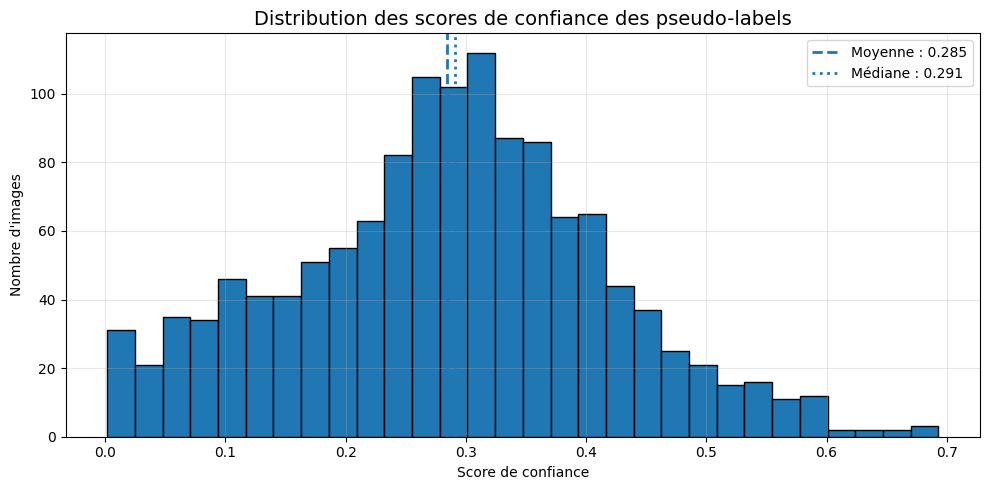

In [1825]:
mean_conf = df_train_unla_results["confiance_distance"].mean()
median_conf = df_train_unla_results["confiance_distance"].median()

plt.figure(figsize=(10, 5))

plt.hist(
    df_train_unla_results["confiance_distance"],
    bins=30,
    edgecolor="black"
)

plt.axvline(
    mean_conf,
    linestyle="--",
    linewidth=2,
    label=f"Moyenne : {mean_conf:.3f}"
)

plt.axvline(
    median_conf,
    linestyle=":",
    linewidth=2,
    label=f"Médiane : {median_conf:.3f}"
)

plt.title(
    "Distribution des scores de confiance des pseudo-labels",
    fontsize=14
)

plt.xlabel("Score de confiance")
plt.ylabel("Nombre d'images")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

<h4 style="color:#48C9B0;">Interprétation des résultats</h4>

La distribution des scores de confiance présente une forme unimodale centrée autour de <b>0,30</b>. La proximité entre la moyenne (<b>0,285</b>) et la médiane (<b>0,291</b>) traduit une répartition relativement équilibrée des niveaux de confiance associés aux images non annotées.

La majorité des observations se concentre entre <b>0,20</b> et <b>0,40</b>, avec un maximum de fréquence autour de <b>0,30</b>. Cette distribution indique que la plupart des images sont associées à un cluster avec un niveau de confiance intermédiaire, tandis qu'un nombre plus restreint d'observations présente une affectation beaucoup plus nette.

Les scores les plus faibles correspondent aux images situées à proximité de la frontière entre les deux clusters, alors que les valeurs les plus élevées traduisent une séparation plus importante entre les distances aux deux centroïdes. Le score de confiance permet ainsi de hiérarchiser les images selon la fiabilité estimée de leur affectation au cluster prédit.


In [1776]:
df_train_unla_results["rang_confiance"] = (
    df_train_unla_results["confiance_distance"]
    .rank(pct=True)
)

<h4 style="color:#48C9B0;">Pureté des clusters</h4>

<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br>

Je calcule un score de confiance propre à chaque cluster à partir des <b>données labellisées du jeu d'entraînement</b>.

Ce score correspond à la proportion de la classe majoritaire présente dans chaque cluster. Plus cette proportion est élevée, plus le cluster est homogène et plus les pseudo-labels qui lui sont associés sont susceptibles d'être fiables.

Cette mesure complète le score de confiance basé sur les distances aux centroïdes en intégrant une information sur la qualité réelle du clustering observée sur les données annotées.

</div>

In [1777]:
cluster_confidence = {}

for cluster in cluster_label_table_train.index:

    total_cluster = (
        cluster_label_table_train.loc[cluster].sum()
    )

    majoritaire = (
        cluster_label_table_train.loc[cluster].max()
    )

    cluster_confidence[cluster] = (
        majoritaire / total_cluster
    )

print(cluster_confidence)

{0: np.float64(0.9333333333333333), 1: np.float64(0.9655172413793104)}


<h4 style="color:#48C9B0;">Interprétation des résultats</h4>

Les scores de confiance calculés à partir de la pureté des clusters montrent que les deux groupes identifiés par K-Means sont fortement homogènes. Le cluster 0 atteint un niveau de confiance de <b>93,3 %</b>, tandis que le cluster 1 atteint <b>96,6 %</b>.

Ces valeurs signifient que, parmi les données annotées utilisées pour évaluer le clustering, <b>93,3 %</b> des images du cluster 0 appartiennent à sa classe majoritaire et <b>96,6 %</b> des images du cluster 1 appartiennent à la leur. Les deux clusters présentent donc une forte cohérence avec les labels réels, malgré les limites inhérentes à une approche non supervisée.

Le cluster associé au profil <i>Cancer</i> apparaît comme le plus pur. Cette observation suggère que les pseudo-labels attribués à cette classe sont globalement plus fiables, le nombre d'images appartenant à la classe opposée restant très faible.

Ces scores de pureté apportent une information complémentaire aux distances aux centroïdes. Alors que la confiance basée sur la distance évalue la position individuelle d'une image par rapport aux centres des clusters, la pureté mesure la fiabilité globale du cluster auquel elle appartient.

Dans la suite du projet, ces deux informations seront combinées afin de construire un score de confiance final. Cette stratégie permettra de privilégier les images appartenant à des clusters fiables et présentant une affectation claire, afin de sélectionner les pseudo-labels les plus pertinents pour l'apprentissage semi-supervisé.

<h4 style="color:#48C9B0;">Score de confiance final</h4>

<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">
<b>Objectif</b><br>

Je cherche à déterminer la meilleure pondération entre la confiance issue de la pureté des clusters et la confiance basée sur la distance aux centroïdes.

Pour cela, j'utilise les données labellisées comme référence et je simule la sélection des pseudo-labels les plus fiables selon différentes combinaisons de pondération.

L'objectif est d'identifier la pondération qui maximise la qualité des pseudo-labels retenus tout en conservant une représentation suffisante des deux classes avant la phase d'apprentissage semi-supervisé.

</div>

In [1778]:
poids_cluster_list = [0.5, 0.6, 0.7, 0.8, 0.9]

df_demo = df_labeled_results.copy()

# Prédiction du profil à partir du cluster
df_demo["label_pred_cluster"] = df_demo["cluster"].map(cluster_to_label)

# Vérification si le pseudo-label serait correct
df_demo["pseudo_label_correct"] = (
    df_demo["label_pred_cluster"] == df_demo["label_reel"]
)

# Distances aux centroïdes
X_labeled_pca = np.vstack([train_pca, val_pca, test_pca])
distances_labeled = kmeans_final.transform(X_labeled_pca)

df_demo["distance_cluster_0"] = distances_labeled[:, 0]
df_demo["distance_cluster_1"] = distances_labeled[:, 1]

df_demo["confiance_distance"] = (
    np.abs(df_demo["distance_cluster_0"] - df_demo["distance_cluster_1"])
    /
    (df_demo["distance_cluster_0"] + df_demo["distance_cluster_1"] + 1e-8)
)

df_demo["confiance_cluster"] = df_demo["cluster"].map(cluster_confidence)

resultats_ponderation = []

for poids_cluster in poids_cluster_list:

    poids_distance = 1 - poids_cluster

    df_demo["confiance_finale"] = (
        poids_cluster * df_demo["confiance_cluster"]
        +
        poids_distance * df_demo["confiance_distance"]
    )

    # On simule une sélection des 30% pseudo-labels les plus fiables
    seuil = df_demo["confiance_finale"].quantile(0.70)

    df_selection = df_demo[
        df_demo["confiance_finale"] >= seuil
    ]

    resultats_ponderation.append({
        "Poids pureté": poids_cluster,
        "Poids distance": poids_distance,
        "Images retenues": len(df_selection),
        "Pseudo-labels corrects (%)": 100 * df_selection["pseudo_label_correct"].mean(),
        "Confiance moyenne": df_selection["confiance_finale"].mean(),
        "Images Cancer (%)": 100 * (df_selection["label_pred_cluster"] == 1).mean(),
        "Images Normal (%)": 100 * (df_selection["label_pred_cluster"] == 0).mean()
    })

df_resultats_ponderation = pd.DataFrame(resultats_ponderation)

df_resultats_ponderation

,Poids pureté,Poids distance,Images retenues,Pseudo-labels corrects (%),Confiance moyenne,Images Cancer (%),Images Normal (%)
0,0.5,0.5,30,96.666667,0.692600,43.333333,56.666667
1,0.6,0.4,30,96.666667,0.743536,43.333333,56.666667
2,0.7,0.3,30,96.666667,0.794983,56.666667,43.333333
3,0.8,0.2,30,96.666667,0.847208,60.000000,40.000000
4,0.9,0.1,30,96.666667,0.902050,83.333333,16.666667


<h4 style="color:#48C9B0;">Analyse de la pondération du score de confiance</h4>

Afin de construire un score de confiance final, plusieurs combinaisons entre la <b>pureté du cluster</b> et la <b>confiance basée sur la distance aux centroïdes</b> ont été évaluées. Cette analyse est réalisée sur les <b>données annotées</b>, ce qui permet de mesurer directement la proportion de pseudo-labels correctement attribués pour chaque pondération. Pour chaque configuration, les <b>30 % d'images présentant les scores de confiance les plus élevés</b> sont sélectionnées puis comparées à leurs labels réels.

Les résultats montrent que le <b>taux de pseudo-labels corrects reste identique (96,7 %)</b> quelle que soit la pondération retenue. Les deux composantes du score identifient donc sensiblement les mêmes images comme étant les plus fiables.

En revanche, la composition de la sélection évolue lorsque le poids accordé à la pureté du cluster augmente. Avec une pondération équilibrée (<b>50 % pureté / 50 % distance</b>), les images retenues sont réparties entre <b>56,7 % d'images normales</b> et <b>43,3 % d'images cancéreuses</b>. À l'inverse, lorsque la pureté représente <b>90 %</b> du score, la sélection devient largement dominée par le profil <i>Cancer</i>, qui représente <b>83,3 %</b> des images conservées.

Cette évolution s'explique par la pureté légèrement plus élevée du cluster associé au profil <i>Cancer</i>. En augmentant le poids de cette composante, le score de confiance favorise naturellement les images appartenant à ce cluster, au détriment des images associées au profil <i>Normal</i>.

<div style="border-left:5px solid #48C9B0;background:#f8fdfc;padding:14px 18px;margin:18px 0;color:black;">

<b>Choix retenu</b><br>

Le taux de pseudo-labels corrects étant identique pour toutes les pondérations testées, j'ai retenu une combinaison <b>50 % pureté / 50 % distance</b>. Cette configuration conserve la même qualité de pseudo-labellisation tout en limitant le biais en faveur du profil <i>Cancer</i>. Elle fournit ainsi un score de confiance plus équilibré, mieux adapté à la sélection des pseudo-labels destinés à l'entraînement semi-supervisé.

</div>

<h4 style="color:#48C9B0;">Construction du score de confiance final</h4>

Afin d'identifier les pseudo-labels les plus fiables, deux sources d'information complémentaires sont combinées : la <b>fiabilité du cluster</b> et la <b>distance relative aux centroïdes</b>.

La <b>fiabilité du cluster</b> est estimée à partir de la proportion de la classe majoritaire observée sur les données fortement labellisées. Elle atteint <b>93,3&nbsp;%</b> pour le cluster associé au profil <i>Normal</i> et <b>96,6&nbsp;%</b> pour le cluster associé au profil <i>Cancer</i>.

La <b>confiance basée sur la distance</b> évalue quant à elle la position individuelle de chaque image dans l'espace PCA. Une image proche du centroïde de son cluster et suffisamment éloignée du centroïde opposé obtient un score plus élevé qu'une image située à proximité de la frontière entre les deux groupes.

Les deux composantes sont ensuite combinées à l'aide d'une <b>moyenne pondérée</b>. Après avoir comparé plusieurs pondérations, une répartition équilibrée a été retenue :

<p style="text-align:center; font-size:18px;">
<b>Confiance finale = 0,5 × Fiabilité du cluster + 0,5 × Confiance distance</b>
</p>

Cette formulation permet de prendre en compte à la fois la cohérence globale du cluster et la position individuelle de chaque image. Le score obtenu ne représente pas une probabilité d'appartenance à une classe, mais un <b>indice de fiabilité</b> utilisé pour classer les images non annotées.

Les pseudo-labels sont ensuite sélectionnés en appliquant un <b>seuil minimal de confiance</b>. Cette stratégie permet de conserver uniquement les observations jugées suffisamment fiables pour constituer le jeu d'entraînement faiblement supervisé, tout en limitant l'introduction de bruit dans l'apprentissage du modèle.

In [1829]:
df_train_unla_results["confiance_cluster"] = (
    df_train_unla_results["cluster"]
    .map(cluster_confidence)
)

df_train_unla_results["confiance_finale"] = (
    0.5 * df_train_unla_results["confiance_cluster"]
    + 
    0.5 * df_train_unla_results["confiance_distance"]
)

df_train_unla_results.sort_values(
    "confiance_finale",
    ascending=False
).head()

,split,cluster,pca_1,pca_2,profil_probable,profil,distance_cluster_0,distance_cluster_1,distance_centroid,confiance_distance,label,rang_confiance,confiance_cluster,confiance_finale
53,train_unla,1,15.988368,-5.810276,cancer,cancer pseudo,33.011059,6.195561,6.195561,0.683953,1,0.999237,0.965517,0.824735
1144,train_unla,1,18.047651,0.539159,cancer,cancer pseudo,33.882183,6.837281,6.837281,0.664176,1,0.997712,0.965517,0.814847
322,train_unla,0,-14.308775,8.273615,normal,normal pseudo,5.909731,32.589062,5.909731,0.692991,0,1.000000,0.933333,0.813162
83,train_unla,0,-16.586664,4.172316,normal,normal pseudo,6.523909,34.062344,6.523909,0.678516,0,0.998474,0.933333,0.805925
779,train_unla,1,17.676777,-4.112270,cancer,cancer pseudo,34.851688,7.797211,7.797211,0.634353,1,0.995423,0.965517,0.799935


<h4 style="color:#48C9B0;">6.5 Analyse des seuils de confiance</h4>

Une fois le score de confiance final calculé pour chaque image non annotée, plusieurs seuils sont évalués afin d'étudier leur impact sur la composition du jeu faiblement supervisé. Cette étape consiste à identifier le meilleur compromis entre le nombre de pseudo-labels conservés et leur niveau de fiabilité.

Un seuil trop faible permet de conserver un volume important d'images, mais augmente le risque d'introduire des pseudo-labels erronés. À l'inverse, un seuil plus élevé sélectionne uniquement les observations les plus fiables, au prix d'une réduction du nombre d'exemples disponibles pour l'entraînement.

<div style="border-left:5px solid #48C9B0;
background:#f8fdfc;
color:black;
padding:14px 18px;
margin:18px 0;">

<b>Objectif</b><br>

J'étudie l'influence de plusieurs seuils appliqués au <b>score de confiance final</b> afin d'observer leur effet sur le nombre d'images retenues, leur niveau de confiance moyen ainsi que la répartition des profils probables <i>Normal</i> et <i>Cancer</i>.

L'objectif est de sélectionner un seuil permettant de constituer un jeu d'entraînement faiblement supervisé suffisamment fiable, tout en conservant un volume de données compatible avec l'apprentissage du modèle semi-supervisé.

</div>

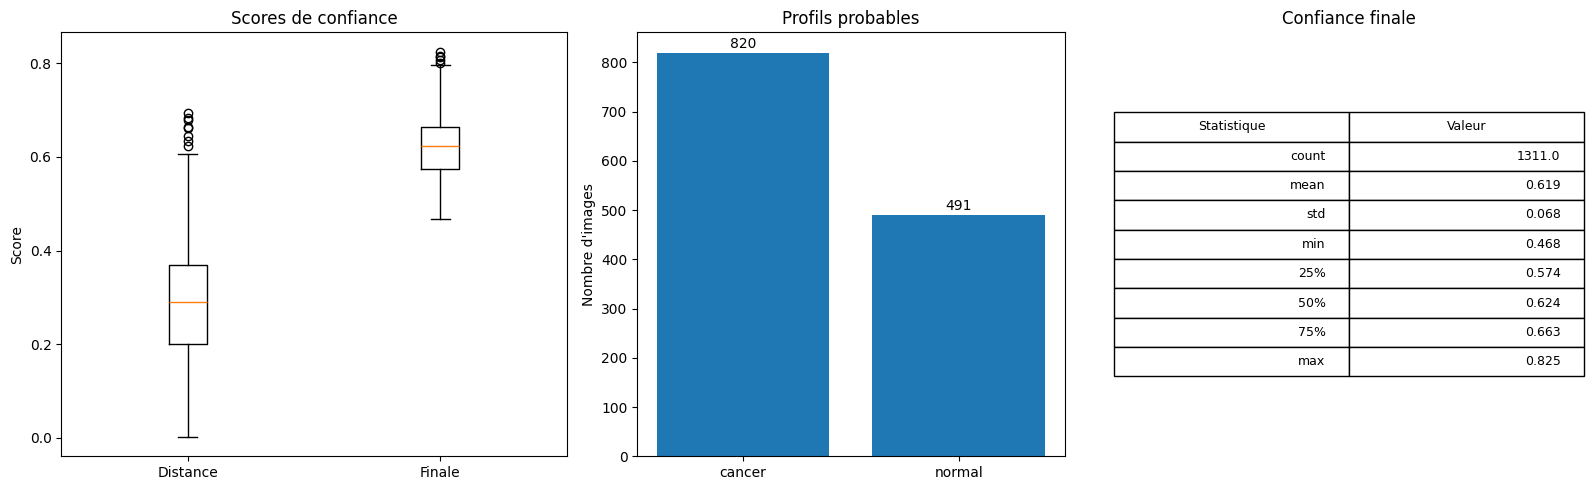

In [1780]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5),
    gridspec_kw={"width_ratios": [1.3, 1.1, 1.1]}
)

# Boxplot
axes[0].boxplot(
    [
        df_train_unla_results["confiance_distance"],
        df_train_unla_results["confiance_finale"]
    ],
    tick_labels=["Distance", "Finale"]
)

axes[0].set_title("Scores de confiance")
axes[0].set_ylabel("Score")

# Répartition des profils
profil_counts = (
    df_train_unla_results["profil_probable"]
    .value_counts()
)

axes[1].bar(
    profil_counts.index,
    profil_counts.values
)

axes[1].set_title("Profils probables")
axes[1].set_ylabel("Nombre d'images")

for i, v in enumerate(profil_counts.values):
    axes[1].text(
        i,
        v + 10,
        str(v),
        ha="center"
    )

# Statistiques descriptives
axes[2].axis("off")

stats = (
    df_train_unla_results["confiance_finale"]
    .describe()
    .round(3)
    .reset_index()
)

table = axes[2].table(
    cellText=stats.values,
    colLabels=["Statistique", "Valeur"],
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.1, 1.6)

axes[2].set_title("Confiance finale")

plt.tight_layout()
plt.show()

<h4 style="color:#48C9B0;">Interprétation des résultats</h4>

La combinaison de la <b>pureté du cluster</b> et de la <b>confiance basée sur la distance aux centroïdes</b> produit un score de confiance final plus élevé et plus homogène que celui obtenu à partir de la seule distance. Les statistiques descriptives montrent une moyenne de <b>0,619</b>, une médiane de <b>0,624</b> et un écart-type de <b>0,068</b>, pour des valeurs comprises entre <b>0,468</b> et <b>0,825</b>.

Le boxplot met en évidence un décalage de la distribution vers des valeurs de confiance plus élevées après combinaison des deux composantes. Ce comportement est attendu puisque la forte pureté des clusters (<b>93,3&nbsp;%</b> pour le profil <i>Normal</i> et <b>96,6&nbsp;%</b> pour le profil <i>Cancer</i>) vient renforcer le score individuel calculé à partir de la distance aux centroïdes.

La répartition des profils probables reste inchangée, avec <b>820 images associées au profil <i>Cancer</i></b> et <b>491 images associées au profil <i>Normal</i></b>. Le score de confiance final fournit ainsi un classement unique des images non annotées selon la fiabilité estimée de leur pseudo-label.

<div style="border-left:5px solid #48C9B0;background:#f8fdfc;padding:14px 18px;margin:18px 0;color:black;">

<b>Conclusion</b><br>

Ce score constitue désormais le critère de sélection des pseudo-labels. La section suivante étudie l'effet de différents seuils appliqués à cette confiance finale afin d'identifier le meilleur compromis entre la quantité d'images conservées et les performances obtenues lors de l'entraînement du modèle semi-supervisé.

</div>

<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br>

J'analyse la distribution des scores de confiance finaux pour chaque profil probable afin d'évaluer si les niveaux de confiance sont comparables entre les pseudo-labels <i>Normal</i> et <i>Cancer</i>.

Cette visualisation permet d'identifier d'éventuelles différences de fiabilité entre les deux profils et de vérifier si un seuil de sélection unique peut être appliqué à l'ensemble des pseudo-labels.

L'objectif est également de détecter un éventuel biais du clustering qui favoriserait systématiquement un profil par rapport à l'autre lors de l'attribution des pseudo-labels.

</div>

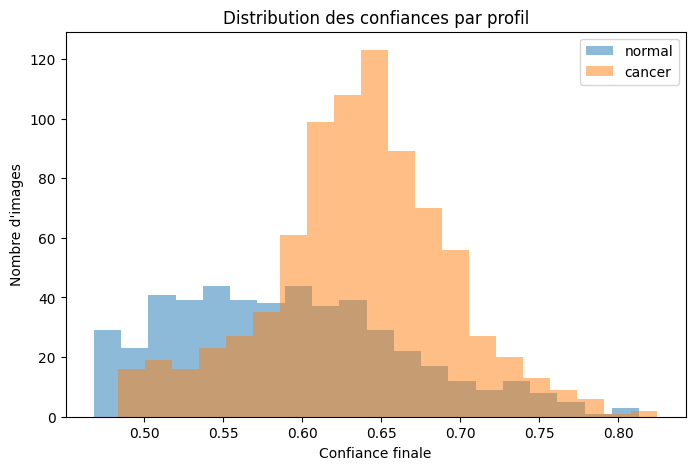

In [1781]:
plt.figure(figsize=(8,5))

for profil in ["normal", "cancer"]:

    plt.hist(
        df_train_unla_results.loc[
            df_train_unla_results["profil_probable"] == profil,
            "confiance_finale"
        ],
        bins=20,
        alpha=0.5,
        label=profil
    )

plt.title("Distribution des confiances par profil")
plt.xlabel("Confiance finale")
plt.ylabel("Nombre d'images")
plt.legend()

plt.show()

<h4 style="color:#48C9B0;">Interprétation des résultats</h4>

La distribution des scores de confiance met en évidence des différences entre les deux profils probables. Les images associées au profil <i>Cancer</i> obtiennent globalement des scores de confiance plus élevés que celles associées au profil <i>Normal</i>, avec une concentration des valeurs autour de <b>0,62 à 0,66</b>. Les images <i>Normal</i> présentent une distribution plus étalée et des scores en moyenne légèrement plus faibles.

Cette différence est cohérente avec la <b>pureté des clusters</b> obtenus par <b>K-Means</b>. Le cluster associé au profil <i>Cancer</i>, dont la pureté est légèrement supérieure à celle du cluster <i>Normal</i>, contribue à attribuer des scores de confiance plus élevés aux pseudo-labels cancéreux.

Les deux distributions présentent néanmoins une zone de recouvrement importante, correspondant aux images dont l'affectation reste la plus incertaine. À l'inverse, les observations situées dans la partie droite des distributions possèdent les scores de confiance les plus élevés et sont donc considérées comme les pseudo-labels les plus fiables.

<div style="border-left:5px solid #48C9B0;background:#f8fdfc;padding:14px 18px;margin:18px 0;color:black;">

<b>Conclusion</b><br>

Cette différence de distribution montre qu'un seuil de confiance unique ne sélectionnera pas les deux profils dans les mêmes proportions. L'étude des seuils permettra donc d'évaluer l'impact de différents niveaux de confiance sur le volume de pseudo-labels conservés et sur les performances du modèle semi-supervisé, afin de retenir la valeur offrant le meilleur compromis.

</div>

In [1782]:
df_train_unla_results.groupby(
    "profil_probable"
)["confiance_finale"].describe()

,count,mean,std,min,25%,50%,75%,max
profil_probable,,,,,,,,
cancer,820.0,0.635552,0.058068,0.483653,0.605008,0.637876,0.671184,0.824735
normal,491.0,0.591326,0.073857,0.468195,0.531125,0.584392,0.638405,0.813162


<h4 style="color:#48C9B0;">Interprétation des résultats</h4>

Les statistiques descriptives confirment les différences observées sur les distributions de confiance. Les images associées au profil <i>Cancer</i> présentent un score de confiance moyen de <b>0,636</b>, contre <b>0,591</b> pour le profil <i>Normal</i>. Cette différence s'explique par la pureté légèrement supérieure du cluster associé au profil <i>Cancer</i>, qui contribue à augmenter le score de confiance final.

Les médianes suivent la même tendance (<b>0,638</b> pour <i>Cancer</i> contre <b>0,584</b> pour <i>Normal</i>), ce qui confirme que les pseudo-labels cancéreux sont, dans l'ensemble, associés à un niveau de confiance plus élevé. Les écarts-types restent relativement faibles (<b>0,058</b> et <b>0,074</b>), traduisant une dispersion limitée des scores au sein de chaque profil.

Les quartiles mettent également en évidence ce décalage. Ainsi, <b>75 %</b> des images associées au profil <i>Cancer</i> possèdent un score inférieur à <b>0,671</b>, tandis que ce troisième quartile est de <b>0,638</b> pour le profil <i>Normal</i>. Les valeurs maximales, supérieures à <b>0,81</b> pour les deux profils, correspondent aux pseudo-labels présentant la plus forte confiance.

<div style="border-left:5px solid #48C9B0;background:#f8fdfc;padding:14px 18px;margin:18px 0;color:black;">

<b>Conclusion</b><br>

Ces résultats montrent que les deux profils ne suivent pas exactement la même distribution de confiance. Ils justifient l'évaluation de plusieurs seuils de sélection afin d'identifier celui qui permet de conserver les pseudo-labels les plus fiables tout en maintenant un volume de données suffisant pour l'apprentissage semi-supervisé.

</div>

<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br>

J'analyse l'impact du seuil de confiance sur le nombre d'images pseudo-labellisées conservées.

Pour chaque seuil, je compte le nombre total d'images retenues ainsi que la répartition entre les profils <i>Normal</i> et <i>Cancer</i>. Cette étape me permet d'évaluer le compromis entre quantité de données disponibles et fiabilité attendue des pseudo-labels.

L'objectif est d'identifier un seuil suffisamment sélectif pour limiter le bruit, sans réduire excessivement le volume d'images utilisables pour l'apprentissage semi-supervisé.

</div>

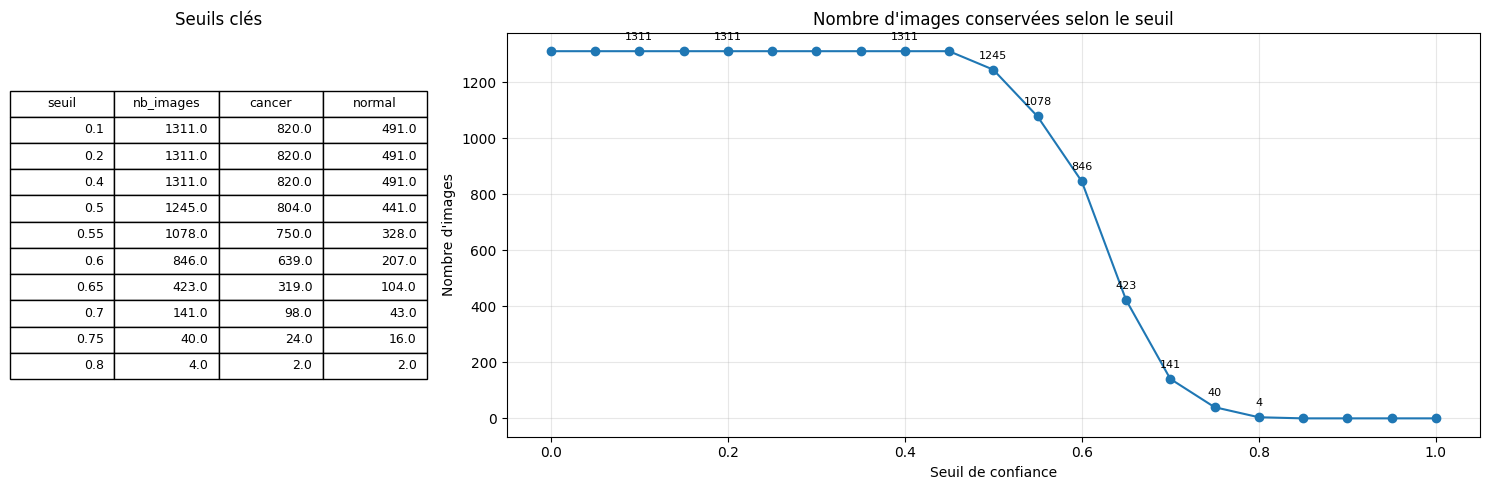

In [1826]:
seuils = np.arange(0, 1.01, 0.05)

resultats = []

for seuil in seuils:

    tmp = df_train_unla_results[
        df_train_unla_results["confiance_finale"] >= seuil
    ]

    resultats.append({
        "seuil": seuil,
        "nb_images": len(tmp),
        "cancer": (tmp["profil_probable"] == "cancer").sum(),
        "normal": (tmp["profil_probable"] == "normal").sum()
    })

df_seuils = pd.DataFrame(resultats)

# Seuils clés à afficher dans le tableau
seuils_cles = [0.2, 0.4, 0.5, 0.55, 0.6, 0.65, 0.70, 0.75, 0.8, 0.1]

df_table = df_seuils[
    df_seuils["seuil"].round(2).isin(seuils_cles)
].copy()

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5),
    gridspec_kw={"width_ratios": [0.9, 2.1]}
)

# Tableau simplifié
axes[0].axis("off")

table = axes[0].table(
    cellText=df_table.round(2).values,
    colLabels=df_table.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)

axes[0].set_title("Seuils clés")

# Courbe
axes[1].plot(
    df_seuils["seuil"],
    df_seuils["nb_images"],
    marker="o"
)

axes[1].set_title("Nombre d'images conservées selon le seuil")
axes[1].set_xlabel("Seuil de confiance")
axes[1].set_ylabel("Nombre d'images")
axes[1].grid(alpha=0.3)

# Annotation uniquement sur les seuils clés
for _, row in df_table.iterrows():
    axes[1].annotate(
        int(row["nb_images"]),
        (row["seuil"], row["nb_images"]),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=8
    )

plt.tight_layout()
plt.show()

<h4 style="color:#48C9B0;">Interprétation des résultats</h4>

L'analyse montre que les pseudo-labels présentent globalement un niveau de confiance élevé. Jusqu'à un seuil de <b>0,45</b>, les <b>1&nbsp;311 images</b> sont conservées, ce qui signifie que l'ensemble des pseudo-labels satisfait ce niveau minimal de confiance.

À partir d'un seuil de <b>0,50</b>, le filtrage devient progressivement plus sélectif. Le nombre d'images retenues passe à <b>1&nbsp;245</b>, puis à <b>1&nbsp;078</b> pour un seuil de <b>0,55</b>. La diminution s'accentue ensuite avec <b>846</b> images conservées à <b>0,60</b> et seulement <b>423</b> à <b>0,65</b>. Enfin, un seuil de <b>0,80</b> ne conserve plus que <b>4 images</b>, volume insuffisant pour entraîner efficacement un modèle semi-supervisé.

Le filtrage entraîne également une diminution plus rapide des pseudo-labels associés au profil <i>Normal</i> que de ceux associés au profil <i>Cancer</i>, conséquence directe des scores de confiance légèrement plus élevés obtenus par le cluster cancéreux.

<div style="border-left:5px solid #48C9B0;background:#f8fdfc;padding:14px 18px;margin:18px 0;color:black;">

<b>Choix retenu</b><br>

Cette analyse met en évidence un <b>point de rupture situé entre les seuils 0,65 et 0,70</b>, où le nombre de pseudo-labels conservés chute fortement. Au-delà de cette zone, le filtrage devient beaucoup plus sélectif et ne conserve que les observations les plus éloignées de la frontière entre les deux clusters.

Cette plage de seuils apparaît comme un bon compromis entre le volume de données conservé et le niveau de confiance des pseudo-labels. Elle sera donc privilégiée lors des expérimentations d'entraînement afin d'identifier le seuil offrant les meilleures performances pour le modèle semi-supervisé.

</div>

<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color:black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br>

J'étudie l'évolution du nombre de pseudo-labels conservés en fonction du seuil de confiance pour chaque profil probable.

Cette analyse permet d'observer séparément le comportement des profils <i>Normal</i> et <i>Cancer</i> lorsque le niveau d'exigence augmente. Elle complète l'étude précédente en mettant en évidence l'impact du seuil sur l'équilibre des classes.

L'objectif est de vérifier si un seuil unique permet de conserver un nombre suffisant d'images dans chaque profil ou s'il est nécessaire d'adopter une stratégie de sélection différente pour constituer un jeu de pseudo-labels équilibré.

</div>

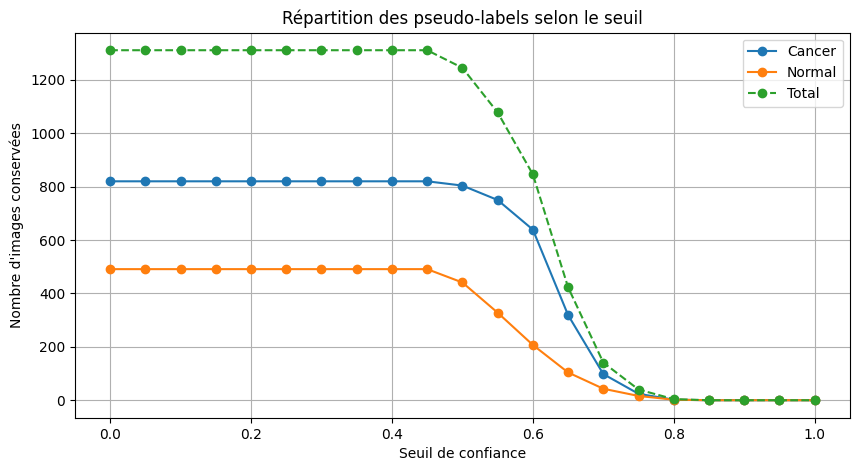

In [1784]:
seuils = np.arange(0, 1.01, 0.05)

stats = []

for seuil in seuils:

    tmp = df_train_unla_results[
        df_train_unla_results["confiance_finale"] >= seuil
    ]

    stats.append({
        "seuil": seuil,
        "cancer": (tmp["profil_probable"] == "cancer").sum(),
        "normal": (tmp["profil_probable"] == "normal").sum(),
        "total": len(tmp)
    })

stats = pd.DataFrame(stats)

plt.figure(figsize=(10,5))

plt.plot(
    stats["seuil"],
    stats["cancer"],
    label="Cancer",
    marker="o"
)

plt.plot(
    stats["seuil"],
    stats["normal"],
    label="Normal",
    marker="o"
)

plt.plot(
    stats["seuil"],
    stats["total"],
    label="Total",
    marker="o",
    linestyle="--"
)

plt.title("Répartition des pseudo-labels selon le seuil")
plt.xlabel("Seuil de confiance")
plt.ylabel("Nombre d'images conservées")

plt.legend()
plt.grid(True)

plt.show()

<h4 style="color:#48C9B0;">Interprétation des résultats</h4>

L'évolution du nombre de pseudo-labels selon le seuil de confiance montre que les effectifs restent stables jusqu'à un seuil d'environ <b>0,45</b>, puis diminuent progressivement à partir de <b>0,50</b>. La réduction devient particulièrement marquée entre <b>0,65</b> et <b>0,70</b>, où le nombre d'images conservées chute fortement.

Cette diminution n'affecte pas les deux profils de manière identique. Les pseudo-labels associés au profil <i>Cancer</i> sont conservés plus longtemps que ceux associés au profil <i>Normal</i>, traduisant des scores de confiance globalement plus élevés pour cette classe. Le filtrage tend donc à accentuer progressivement le déséquilibre entre les deux profils lorsque le seuil augmente.

Ces observations confirment qu'un seuil de confiance élevé permet d'écarter les pseudo-labels les plus incertains, mais réduit rapidement le volume de données disponible pour l'apprentissage.

<div style="border-left:5px solid #48C9B0;background:#f8fdfc;padding:14px 18px;margin:18px 0;color:black;">

<b>Choix retenu</b><br>

L'analyse met en évidence une <b>zone de transition comprise entre les seuils 0,65 et 0,70</b>, où le compromis entre quantité de données conservées et niveau de confiance apparaît le plus intéressant. Cette plage sera étudiée lors des expérimentations d'entraînement afin d'identifier le seuil conduisant aux meilleures performances du modèle semi-supervisé.

</div>

<h4 style="color:#48C9B0;">6.7 Limites de l'approche</h4>

<div style="border-left:5px solid #48C9B0;background:#f8fdfc;padding:14px 18px;margin:18px 0;color:black;">

<b style="color:black;">Analyse critique de la pseudo-labellisation</b><br><br>

<ul style="line-height:1.8;">

<li><b>Qualité du clustering :</b> malgré une forte pureté des clusters (93,3&nbsp;% pour <i>Normal</i> et 96,6&nbsp;% pour <i>Cancer</i>), les scores ARI et NMI montrent que les regroupements ne reproduisent pas parfaitement les classes médicales. Une partie des pseudo-labels reste donc inévitablement bruitée.</li>

<li><b>Réduction de dimension :</b> la PCA à <b>6 composantes</b> (≈40&nbsp;% de variance expliquée) améliore le clustering, mais elle simplifie la représentation initiale des embeddings et peut perdre certaines informations discriminantes.</li>

<li><b>Score de confiance :</b> le score développé permet de hiérarchiser les pseudo-labels selon leur fiabilité, mais il ne constitue pas une probabilité de diagnostic. Un score élevé ne garantit donc pas qu'un pseudo-label soit correct.</li>

<li><b>Choix du seuil :</b> le seuil retenu (entre 0.65 et 0.70) repose sur les caractéristiques de ce jeu de données et sur les expérimentations réalisées. Il devra être réévalué sur un autre jeu d'images ou dans un autre contexte clinique.</li>

<li><b>Faible volume de données annotées :</b> moins d'une centaine d'images possèdent un diagnostic confirmé. Les performances restent sensibles au découpage des données et mériteraient d'être confirmées sur un jeu annoté plus important.</li>

</ul>

</div>

<h2 style="color:#48C9B0;">7. Préparation des données pour le CNN</h2>

<h4 style="color:#48C9B0;">7.1 Configuration PyTorch</h4>

Cette étape initialise l'environnement d'entraînement utilisé pour les modèles CNN. Le code détecte automatiquement si une carte graphique compatible CUDA est disponible ; dans ce cas, les calculs sont effectués sur le GPU, sinon ils sont réalisés sur le CPU.

Afin de rendre les expérimentations plus reproductibles, une seed fixe est définie pour NumPy et PyTorch. Cette configuration permet de limiter les variations liées aux initialisations aléatoires, notamment lors de l'entraînement des réseaux de neurones et de la création des lots de données.

<div style="border-left:5px solid #48C9B0;
background:#f8fdfc;
color:black;
padding:14px 18px;
margin:18px 0;">

<b>Objectif</b><br>

Je configure l'environnement PyTorch avant la préparation des jeux de données et l'entraînement des modèles. L'objectif est de sélectionner automatiquement le périphérique de calcul le plus adapté, <code>cuda</code> si un GPU est disponible, sinon <code>cpu</code>.

Je fixe également une seed commune afin de rendre les résultats plus stables et de faciliter la comparaison entre le modèle supervisé et le modèle semi-supervisé. Cette étape est importante car les entraînements de réseaux de neurones dépendent de plusieurs opérations aléatoires, comme l'initialisation des poids ou le mélange des données.

</div>

In [1785]:
# Préparation des jeux de données
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Device utilisé :", device)    


Device utilisé : cpu


<h4 style="color:#48C9B0;">7.2 Transformations des images</h4>

Avant l'entraînement, les images sont préparées afin d'être compatibles avec <b>ResNet18</b> pré-entraîné sur <b>ImageNet</b>. Deux pipelines sont utilisés : un pour l'entraînement avec augmentation de données et un second, déterministe, pour la validation et le test.

<div style="border-left:5px solid #48C9B0;
background:#f8fdfc;
color:black;
padding:14px 18px;
margin:18px 0;">

<b>Objectif</b><br>

Toutes les images sont <b>redimensionnées en 224 × 224 pixels</b>, converties en tenseurs PyTorch puis <b>normalisées avec les statistiques d'ImageNet</b> afin d'être compatibles avec le modèle pré-entraîné.

Pour le jeu d'entraînement, une <b>augmentation de données légère</b> est appliquée (retournement horizontal aléatoire et rotation de ±10°) afin d'améliorer la capacité de généralisation du modèle. Les jeux de validation et de test utilisent uniquement des transformations déterministes afin de garantir une évaluation reproductible.

</div>

<h4 style="color:#48C9B0;">Justification des transformations</h4>

Le redimensionnement et la normalisation permettent de réutiliser efficacement les poids pré-entraînés de <b>ResNet18</b>. Les augmentations retenues restent volontairement limitées afin de préserver les structures anatomiques des IRM tout en réduisant le risque de surapprentissage. Des transformations plus importantes auraient pu modifier des informations diagnostiques pertinentes.


In [1786]:
# Transformations adaptées à ResNet
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

<h4 style="color:#48C9B0;">7.3 Création de la classe Dataset</h4>

Une classe personnalisée <b>BrainDataset</b>, héritant de <code>Dataset</code> de PyTorch, est utilisée pour gérer le chargement des images et de leurs labels. Les images sont chargées dynamiquement (<i>lazy loading</i>), ce qui limite la consommation mémoire et facilite l'utilisation des jeux fortement annotés et pseudo-labellisés.

<div style="border-left:5px solid #48C9B0;
background:#f8fdfc;
color:black;
padding:14px 18px;
margin:18px 0;">

<b>Objectif</b><br><br>

Je crée une classe <b>BrainDataset</b> afin d'uniformiser le chargement des images. Elle récupère automatiquement les chemins et les labels depuis les <code>DataFrame</code>, applique les transformations définies précédemment et retourne un couple <code>(image, label)</code> directement exploitable par PyTorch.

Cette implémentation est utilisée pour l'ensemble des jeux de données, garantissant un pipeline homogène tout au long de l'apprentissage supervisé et semi-supervisé.

</div>

<h4 style="color:#48C9B0;">Fonctionnement</h4>

<ul>
<li><b>__init__()</b> : initialise le dataset et les transformations ;</li>
<li><b>__len__()</b> : retourne le nombre d'images ;</li>
<li><b>__getitem__()</b> : charge une image, applique les transformations et retourne le couple <code>(image, label)</code>.</li>
</ul>

Cette classe sert ensuite de base aux <code>DataLoader</code>, qui assurent le découpage des données en mini-lots et le mélange des observations pendant l'entraînement.


In [1787]:
# Dataset PyTorch
class BrainDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.loc[idx, "chemin"]
        label = int(self.dataframe.loc[idx, "label"])

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

<h4 style="color:#48C9B0;">7.4 Préparation des jeux fortement labellisés</h4>

Les données fortement labellisées servent à l'entraînement du modèle supervisé ainsi qu'à la phase de <i>fine-tuning</i> du modèle semi-supervisé. Elles sont préparées afin d'être directement exploitables par le pipeline PyTorch.

<div style="border-left:5px solid #48C9B0;
background:#f8fdfc;
color:black;
padding:14px 18px;
margin:18px 0;">

<b>Objectif</b><br><br>

Je prépare les jeux d'entraînement, de validation et de test à partir des images annotées. Les labels textuels sont convertis en classes numériques (<b>0 = Normal</b>, <b>1 = Cancer</b>) afin d'être compatibles avec les modèles de Deep Learning et les fonctions de perte.

Une vérification est réalisée pour garantir la validité des labels avant la création des objets <code>Dataset</code>.

</div>

<h4 style="color:#48C9B0;">Contrôles effectués</h4>

<ul>
<li>Vérification de la présence d'un label valide pour chaque image ;</li>
<li>Conversion des labels en classes numériques (<b>0</b> et <b>1</b>) ;</li>
<li>Contrôle de la répartition des classes dans les jeux d'entraînement, de validation et de test.</li>
</ul>

Ces contrôles garantissent des jeux de données cohérents et directement exploitables pour l'entraînement et l'évaluation des modèles.


In [1788]:
label_mapping = {
    "normal": 0,
    "cancer": 1,
    "Normal": 0,
    "Cancer": 1
}

strong_train_df = train_metadata.copy()
strong_val_df = val_metadata.copy()
strong_test_df = test_metadata.copy()

strong_train_df["label"] = strong_train_df["classe"].map(label_mapping)
strong_val_df["label"] = strong_val_df["classe"].map(label_mapping)
strong_test_df["label"] = strong_test_df["classe"].map(label_mapping)

print("Train fort :", strong_train_df["classe"].value_counts().to_dict())
print("Validation forte :", strong_val_df["classe"].value_counts().to_dict())
print("Test fort :", strong_test_df["classe"].value_counts().to_dict())

assert strong_train_df["label"].isin([0, 1]).all()
assert strong_val_df["label"].isin([0, 1]).all()
assert strong_test_df["label"].isin([0, 1]).all()

strong_train_df.head()

Train fort : {'cancer': 30, 'normal': 29}
Validation forte : {'cancer': 10, 'normal': 10}
Test fort : {'normal': 10, 'cancer': 10}


,chemin,nom_fichier,classe,label
0,..\data\images_clean\avec_labels\cancer\9de0f2...,9de0f27b-f3db-4bd7-a2ad-6e785ef36cdc.jpg,cancer,1
1,..\data\images_clean\avec_labels\normal\22164f...,22164f5b-9b9f-4fcc-897a-9f902d730bbe.jpg,normal,0
2,..\data\images_clean\avec_labels\cancer\0f7182...,0f718241-8f63-4b55-81ce-315324b51069.jpg,cancer,1
3,..\data\images_clean\avec_labels\cancer\b6a41c...,b6a41ca0-aeea-43a8-b629-7c433cf03143.jpg,cancer,1
4,..\data\images_clean\avec_labels\normal\3c213a...,3c213abc-ab17-4037-a8e5-caa7bc1babe1.jpg,normal,0


<h4 style="color:#48C9B0;">7.5 Préparation des jeux faiblement labellisés</h4>

Les images non annotées ayant reçu un pseudo-label sont préparées afin d'être utilisées lors du pré-entraînement du modèle semi-supervisé. Seules les observations dont le <b>score de confiance dépasse le seuil retenu</b> sont conservées afin de limiter l'introduction de pseudo-labels erronés.

<div style="border-left:5px solid #48C9B0;
background:#f8fdfc;
color:black;
padding:14px 18px;
margin:18px 0;">

<b>Objectif</b><br><br>

Je prépare le jeu de données faiblement labellisé en sélectionnant les images dont le score de confiance est supérieur au seuil retenu. Les profils probables sont ensuite convertis en labels numériques (<b>0 = Normal</b>, <b>1 = Cancer</b>) afin d'être directement exploitables par PyTorch.

Cette préparation garantit la compatibilité entre le pré-entraînement sur les pseudo-labels et le <i>fine-tuning</i> réalisé sur les données fortement labellisées.

</div>

<h4 style="color:#48C9B0;">Constitution du jeu faiblement labellisé</h4>

Le jeu est constitué des images non annotées dont le score de confiance satisfait le seuil sélectionné. Cette stratégie permet de privilégier les pseudo-labels les plus fiables tout en limitant le bruit introduit lors du pré-entraînement du modèle semi-supervisé.


In [1789]:
# Création de la colonne profil_probable si elle n'existe pas
df_train_unla_results["profil_probable"] = (
    df_train_unla_results["cluster"]
    .map(cluster_to_profil)
)

df_train_unla_results.head()

,split,cluster,pca_1,pca_2,profil_probable,profil,distance_cluster_0,distance_cluster_1,distance_centroid,confiance_distance,label,rang_confiance,confiance_cluster,confiance_finale
0,train_unla,1,6.766999,0.486715,cancer,cancer pseudo,27.213236,17.290920,17.290920,0.222953,1,0.299008,0.965517,0.594235
1,train_unla,1,12.184685,4.883969,cancer,cancer pseudo,31.195210,18.951471,18.951471,0.244158,1,0.348589,0.965517,0.604838
2,train_unla,1,11.988616,1.426672,cancer,cancer pseudo,31.336422,16.083689,16.083689,0.321651,1,0.612510,0.965517,0.643584
3,train_unla,1,20.960814,8.840153,cancer,cancer pseudo,38.591705,17.150478,17.150478,0.384650,1,0.788711,0.965517,0.675084
4,train_unla,1,9.053870,-21.930515,cancer,cancer pseudo,39.742329,26.271276,26.271276,0.204065,1,0.258581,0.965517,0.584791


<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br>

Je construis les jeux de données faiblement labellisés à partir des images non annotées auxquelles un profil probable a été attribué par le clustering.

Pour chaque image, j'ajoute le pseudo-label, le score de confiance final et le label numérique associé. Cette structure permet de transformer les données non annotées en données exploitables par le modèle CNN.

Les assertions vérifient la cohérence entre les métadonnées initiales et les résultats de pseudo-labellisation afin d'éviter tout décalage entre images, labels et scores de confiance.

</div>

In [1827]:
# Création du dataset faible à partir du train non annoté
weak_train_base_df = train_unla_metadata.reset_index(drop=True).copy()

df_train_unla_conf = df_train_unla_results.query("split == 'train_unla'").reset_index(drop=True)

# Ajout des pseudo-labels
weak_train_base_df = weak_train_base_df.assign(
    profil_probable=df_train_unla_conf["profil_probable"].values,
    confiance_finale=df_train_unla_conf["confiance_finale"].values,
    label=df_train_unla_conf["profil_probable"].map({
        "normal": 0,
        "cancer": 1
    }).values
)

# Contrôles
assert len(weak_train_base_df) == len(df_train_unla_conf)
assert weak_train_base_df["label"].isin([0, 1]).all()

weak_train_base_df.head()

,chemin,nom_fichier,classe,label,profil_probable,confiance_finale
0,..\data\images_clean\sans_label\sans_label\001...,001b158a-7af8-451e-bf31-3a9116265f3a.jpg,sans_label,1,cancer,0.594235
1,..\data\images_clean\sans_label\sans_label\003...,00366e8d-5520-4d3c-a70b-91a7eec1f521.jpg,sans_label,1,cancer,0.604838
2,..\data\images_clean\sans_label\sans_label\004...,00455a62-f79f-4072-9a23-4951e759acdc.jpg,sans_label,1,cancer,0.643584
3,..\data\images_clean\sans_label\sans_label\004...,004ce5f5-ca6b-490f-9b2f-c322c152e2ee.jpg,sans_label,1,cancer,0.675084
4,..\data\images_clean\sans_label\sans_label\005...,005d9a37-8894-4eb5-8367-1015d4a43638.jpg,sans_label,1,cancer,0.584791


<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br>

Je sélectionne les images non annotées dont le <b>score de confiance final est supérieur au seuil retenu</b>, afin de constituer un jeu de données faiblement labellisé de haute qualité.

Ce filtrage permet de limiter l'introduction de pseudo-labels incertains tout en conservant un volume de données suffisant pour le pré-entraînement du modèle semi-supervisé. Les profils probables <i>Normal</i> et <i>Cancer</i> sont conservés selon ce même critère de confiance.

Les images retenues correspondent ainsi aux observations les plus cohérentes avec la structure mise en évidence par le clustering et constituent le jeu utilisé lors de la phase de pré-entraînement semi-supervisé.

</div>


In [1828]:
# Sélection des pseudo-labels suffisamment fiables
weak_train_df = (
    weak_train_base_df
    .query("confiance_finale >= @SEUIL_CONFIANCE")
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

# Contrôles
print("Train faible retenu :")
print(weak_train_df["profil_probable"].value_counts())

print("\nRépartition (%) :")
print(
    weak_train_df["profil_probable"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

stats = (
    weak_train_df
    .groupby("profil_probable")["confiance_finale"]
    .agg(
        confiance_min="min",
        confiance_moyenne="mean"
    )
)

print("\nStatistiques de confiance :")
print(stats)

print(f"\nNombre total d'images retenues : {len(weak_train_df)}")

# Sécurité
assert not weak_train_df.empty, "Aucune image ne respecte le seuil de confiance."

Train faible retenu :
profil_probable
cancer    166
normal     58
Name: count, dtype: int64

Répartition (%) :
profil_probable
cancer    74.11
normal    25.89
Name: proportion, dtype: float64

Statistiques de confiance :
                 confiance_min  confiance_moyenne
profil_probable                                  
cancer                0.681355           0.713752
normal                0.681279           0.728287

Nombre total d'images retenues : 224


<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color: black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br><br>

Je convertis le jeu faiblement labellisé en objets <code>Dataset</code> et <code>DataLoader</code> PyTorch afin de l'utiliser lors du pré-entraînement du modèle semi-supervisé.

Le jeu <code>weak_train</code> est constitué des images non annotées dont le score de confiance est supérieur au seuil retenu. Les augmentations de données sont appliquées uniquement à l'entraînement, tandis que les phases de validation et de test utilisent des transformations déterministes.

</div>

<h4 style="color:#48C9B0;">Rôle des données faiblement labellisées</h4>

Le jeu <code>weak_train</code> permet au modèle d'apprendre une première représentation des classes à partir des pseudo-labels avant le <i>fine-tuning</i> sur les données fortement labellisées. Cette étape exploite les informations contenues dans les images initialement non annotées afin d'enrichir l'apprentissage sans nécessiter de nouvelles annotations expertes.


<h4 style="color:#48C9B0;">7.6 Création des DataLoader</h4>

Les objets <code>Dataset</code> sont ensuite encapsulés dans des <code>DataLoader</code> PyTorch afin de charger automatiquement les images par mini-lots lors des différentes phases d'entraînement et d'évaluation.

<div style="border-left:5px solid #48C9B0;
background:#f8fdfc;
color:black;
padding:14px 18px;
margin:18px 0;">

<b>Objectif</b><br><br>

Je crée les <code>DataLoader</code> associés aux jeux fortement et faiblement labellisés afin d'alimenter les modèles de Deep Learning.

Les jeux d'entraînement utilisent un mélange aléatoire des observations (<code>shuffle=True</code>), tandis que les jeux de validation et de test sont parcourus de manière déterministe (<code>shuffle=False</code>). Les images sont traitées par mini-lots de taille <code>BATCH_SIZE</code>.

</div>

<h4 style="color:#48C9B0;">Configuration retenue</h4>

<ul>
    <li><b>Strong Train</b> : <code>shuffle=True</code> ;</li>
    <li><b>Strong Validation</b> : <code>shuffle=False</code> ;</li>
    <li><b>Strong Test</b> : <code>shuffle=False</code> ;</li>
    <li><b>Weak Train</b> : <code>shuffle=True</code> ;</li>
    <li><b>Batch size</b> : <code>BATCH_SIZE</code>.</li>
</ul>

Les <code>DataLoader</code> sont ainsi prêts à être utilisés pour le pré-entraînement sur les pseudo-labels, puis pour l'entraînement supervisé et le <i>fine-tuning</i> sur les données fortement labellisées.

In [1793]:
# DataLoaders fortement labellisés
strong_train_dataset = BrainDataset(strong_train_df, transform=train_transform)
strong_val_dataset = BrainDataset(strong_val_df, transform=eval_transform)
strong_test_dataset = BrainDataset(strong_test_df, transform=eval_transform)

strong_train_loader = DataLoader(strong_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
strong_val_loader = DataLoader(strong_val_dataset, batch_size=BATCH_SIZE, shuffle=False)
strong_test_loader = DataLoader(strong_test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [1794]:
# DataLoaders faiblement labellisés
weak_train_dataset = BrainDataset(weak_train_df,transform=train_transform)
weak_train_loader = DataLoader(weak_train_dataset,batch_size=BATCH_SIZE,shuffle=True)

<h2 style="color:#48C9B0;">8. Modélisation CNN supervisée et semi-supervisée</h2>

Cette dernière partie du notebook est consacrée à l'entraînement des modèles de classification destinés à distinguer les profils <i>Normal</i> et <i>Cancer</i> à partir des IRM cérébrales.

Deux stratégies sont comparées : une approche <b>supervisée</b>, entraînée uniquement sur les données fortement labellisées, et une approche <b>semi-supervisée</b>, reposant sur un pré-entraînement sur les pseudo-labels suivi d'un <i>fine-tuning</i> sur les labels réels.

Les deux modèles utilisent le même protocole expérimental. Seule la stratégie d'apprentissage diffère, ce qui permet d'évaluer objectivement l'apport des pseudo-labels.

<div style="border-left:5px solid #48C9B0;
background:#f8fdfc;
color:black;
padding:14px 18px;
margin:18px 0;">

<b>Objectif</b><br>

Comparer une approche supervisée et une approche semi-supervisée afin de mesurer l'intérêt de l'exploitation des images non annotées lorsque le nombre de labels réels est limité.

</div>

<h4 style="color:#48C9B0;">8.1 Présentation de ResNet18</h4>

Les deux approches reposent sur <b>ResNet18</b>, un réseau de neurones convolutionnel utilisant des connexions résiduelles qui facilitent l'entraînement et limitent les problèmes de disparition du gradient.

Le modèle est initialisé avec des poids pré-entraînés sur <b>ImageNet</b>, puis sa couche de classification est remplacée afin de réaliser une classification binaire (<i>Normal</i> / <i>Cancer</i>).

<div style="border-left:5px solid #48C9B0;
background:#f8fdfc;
color:black;
padding:14px 18px;
margin:18px 0;">

<b>Objectif</b><br><br>

Utiliser une architecture pré-entraînée adaptée au transfert d'apprentissage afin de limiter le besoin en données annotées et de comparer équitablement les approches supervisée et semi-supervisée.

</div>

<h4 style="color:#48C9B0;">Pourquoi ResNet18 ?</h4>

<ul>
<li>Architecture de référence en vision par ordinateur ;</li>
<li>Poids pré-entraînés disponibles sur ImageNet ;</li>
<li>Connexions résiduelles facilitant l'optimisation ;</li>
<li>Modèle léger, rapide à entraîner ;</li>
<li>Particulièrement adapté aux petits jeux de données grâce au transfert d'apprentissage.</li>
</ul>

In [1795]:
def create_resnet18_model():
    model = models.resnet18(
        weights=models.ResNet18_Weights.IMAGENET1K_V1
    )

    # Nouvelle tête de classification
    # la derniere couche est une contrainte metier
    model.fc = nn.Linear(
        model.fc.in_features,
        2
    )

    for param in model.fc.parameters():
        param.requires_grad = True

    return model.to(device)

<h4 style="color:#48C9B0;">8.2 Métriques de classification</h4>

Les performances des modèles sont évaluées à l'aide de plusieurs métriques complémentaires, chacune apportant un éclairage différent sur la qualité des prédictions. Cette approche permet de comparer objectivement les stratégies supervisée et semi-supervisée.

<div style="border-left:5px solid #48C9B0;
background:#f8fdfc;
padding:14px 18px;
margin:18px 0;
color:black;">

<b>Objectif</b><br><br>

Je définis une fonction calculant automatiquement les principales métriques de classification à partir des labels réels (<code>y_true</code>) et des prédictions du modèle (<code>y_pred</code>).

Les indicateurs retenus sont l'<b>accuracy</b>, la <b>précision</b>, le <b>rappel (Recall)</b>, les <b>scores F1</b> et <b>F2</b>. Le paramètre <code>zero_division=0</code> permet d'éviter les erreurs lorsqu'une classe n'est jamais prédite.

</div>

<h4 style="color:#48C9B0;">Choix des métriques</h4>

<ul>
<li><b>Accuracy</b> : proportion globale de prédictions correctes ;</li>
<li><b>Précision</b> : proportion de prédictions <i>Cancer</i> réellement correctes ;</li>
<li><b>Rappel (Recall)</b> : capacité à détecter les patients atteints d'un cancer ;</li>
<li><b>Score F1</b> : équilibre entre précision et rappel ;</li>
<li><b>Score F2</b> : privilégie davantage le rappel.</li>
</ul>

Dans ce projet, le <b>rappel</b> constitue la métrique principale, car un faux négatif correspond à un patient atteint d'une tumeur cérébrale classé à tort comme sain. Les scores <b>F1</b> et <b>F2</b> complètent cette analyse en évaluant le compromis entre précision et rappel, le <b>F2</b> accordant une importance plus élevée à la détection des cas cancéreux.


In [1796]:
# Fonction de calcul des métriques
def compute_classification_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0)
    }

<h4 style="color:#48C9B0;">8.3 Fonctions d'entraînement et d'évaluation</h4>

Les fonctions nécessaires à l'entraînement, à la validation et à l'évaluation des modèles sont regroupées afin d'utiliser un protocole expérimental identique pour les approches supervisée et semi-supervisée.

<div style="border-left:5px solid #48C9B0;
background:#f8fdfc;
padding:14px 18px;
margin:18px 0;
color:black;">

<b>Objectif</b><br>

Je mets en place les fonctions qui réalisent l'entraînement, la validation et l'évaluation des modèles. À chaque époque, elles calculent la fonction de perte, mettent à jour les paramètres du réseau et suivent les principales métriques de classification (accuracy, précision, rappel, F1 et F2).

</div>

<h4 style="color:#48C9B0;">Fonctionnalités principales</h4>

<ul>
    <li>Entraînement et validation à chaque époque ;</li>
    <li>Évaluation finale sur le jeu de test ;</li>
    <li>Calcul automatique des métriques de classification ;</li>
    <li>Sauvegarde du meilleur modèle par <i>Early Stopping</i> ;</li>
    <li>Clipping des gradients pour stabiliser l'apprentissage.</li>
</ul>

Cette organisation garantit un protocole identique pour l'ensemble des expérimentations et facilite la comparaison entre les approches supervisée et semi-supervisée.


In [1797]:
# Fonction d'entraînement d'une époque
def train_one_epoch(
    model,
    train_loader,
    criterion,
    optimizer,
    device,
    max_grad_norm=1.0
):
    # Réalise une époque complète d'entraînement du modèle.
    # Passage du modèle en mode entraînement
    model.train()

    # Variables de suivi
    running_loss = 0.0
    y_true = []
    y_pred = []

    # Parcours des mini-batchs
    for images, labels in train_loader:

        # Envoi des données vers le CPU ou le GPU
        images = images.to(device)
        labels = labels.to(device)

        # Remise à zéro des gradients
        optimizer.zero_grad()

        # Propagation avant (forward pass)
        outputs = model(images)

        # Calcul de la fonction de coût
        loss = criterion(outputs, labels)

        # Rétropropagation des gradients
        loss.backward()

        # Limitation des gradients pour éviter
        # les mises à jour trop importantes
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=max_grad_norm
        )

        # Mise à jour des poids du réseau
        optimizer.step()

        # Accumulation de la perte pondérée
        # par la taille du batch
        running_loss += loss.item() * images.size(0)

        # Classe prédite pour chaque image
        preds = outputs.argmax(dim=1)

        # Sauvegarde des labels réels
        y_true.extend(labels.cpu().numpy())

        # Sauvegarde des prédictions
        y_pred.extend(preds.cpu().numpy())

    # Calcul de la perte moyenne sur l'ensemble du dataset
    train_loss = running_loss / len(train_loader.dataset)

    # Calcul des métriques de classification
    metrics = compute_classification_metrics(
        y_true,
        y_pred
    )

    return train_loss, metrics

In [1798]:
def validate_one_epoch(
    model,
    val_loader,
    criterion,
    device
):
    #Réalise une époque complète de validation du modèle.
    
    # Passage du modèle en mode évaluation
    model.eval()

    # Variables de suivi
    running_loss = 0.0
    y_true = []
    y_pred = []

    # Désactivation du calcul des gradients
    # afin de réduire la consommation mémoire
    # et accélérer les calculs
    with torch.no_grad():

        # Parcours des mini-batchs de validation
        for images, labels in val_loader:

            # Envoi des données vers le CPU ou le GPU
            images = images.to(device)
            labels = labels.to(device)

            # Propagation avant
            outputs = model(images)

            # Calcul de la fonction de coût
            loss = criterion(outputs, labels)

            # Accumulation de la perte pondérée
            # par la taille du batch
            running_loss += loss.item() * images.size(0)

            # Classe prédite pour chaque image
            preds = outputs.argmax(dim=1)

            # Sauvegarde des labels réels
            y_true.extend(labels.cpu().numpy())

            # Sauvegarde des prédictions
            y_pred.extend(preds.cpu().numpy())

    # Calcul de la perte moyenne sur l'ensemble du jeu
    val_loss = running_loss / len(val_loader.dataset)

    # Calcul des métriques de classification
    metrics = compute_classification_metrics(
        y_true,
        y_pred
    )

    return val_loss, metrics

In [1799]:
# Fonction d'entraînement complète du modèle
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    num_epochs,
    device,
    patience=3
):

    # Historique des métriques d'entraînement
    # et de validation pour chaque époque
    history = {
        "train_loss": [],
        "train_accuracy": [],
        "train_precision": [],
        "train_recall": [],
        "train_f1": [],
        "train_f2": [],
        "val_loss": [],
        "val_accuracy": [],
        "val_precision": [],
        "val_recall": [],
        "val_f1": [],
        "val_f2": []
    }

    # Sauvegarde du meilleur modèle observé
    best_model_weights = copy.deepcopy(model.state_dict())
    
    best_val_loss = np.inf
    
    # Compteur utilisé pour l'early stopping
    epochs_without_improvement = 0

    # Boucle principale d'entraînement
    for epoch in range(num_epochs):

        # Phase d'entraînement
        train_loss, train_metrics = train_one_epoch(
            model=model,
            train_loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device
        )

        # Phase de validation
        val_loss, val_metrics = validate_one_epoch(
            model=model,
            val_loader=val_loader,
            criterion=criterion,
            device=device
        )

        # Sauvegarde des métriques
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        for metric_name in [
            "accuracy",
            "precision",
            "recall",
            "f1",
            "f2"
        ]:

            history[f"train_{metric_name}"].append(
                train_metrics[metric_name]
            )

            history[f"val_{metric_name}"].append(
                val_metrics[metric_name]
            )

        # Affichage du suivi d'entraînement
        print(
            f"Epoch {epoch + 1}/{num_epochs} | "
            f"Train loss: {train_loss:.4f} | "
            f"Train acc: {train_metrics['accuracy']:.4f} | "
            f"Train recall: {train_metrics['recall']:.4f} | "
            f"Train F1: {train_metrics['f1']:.4f} | "
            f"Train F2: {train_metrics['f2']:.4f} | "
            f"Val loss: {val_loss:.4f} | "
            f"Val acc: {val_metrics['accuracy']:.4f} | "
            f"Val recall: {val_metrics['recall']:.4f}"
            f"Val precision: {val_metrics['precision']:.4f} | "
            f"Val F1: {val_metrics['f1']:.4f} | "
            f"Val F2: {val_metrics['f2']:.4f} | "
        )
    
        # Conservation du meilleur modèle
        # Critère principal : validation loss
        if val_loss < best_val_loss :
            best_val_loss = val_loss

            best_model_weights = copy.deepcopy(
                model.state_dict()
            )

            epochs_without_improvement = 0

        else:
            epochs_without_improvement += 1

                            
        # Early Stopping
        # Arrêt anticipé si aucune amélioration
        # n'est observée pendant plusieurs époques
        if epochs_without_improvement >= patience:
            print("Early stopping déclenché.")
            break

    # Restauration du meilleur modèle observé
    model.load_state_dict(best_model_weights)

    return model, history

In [1800]:
def predict_dataset(
    model,
    dataloader,
    device
):
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1)

            y_pred.extend(preds.cpu().numpy())
            y_true.extend(labels.numpy())

    return y_true, y_pred

In [1801]:
def evaluate_model(
    model,
    test_loader,
    device
):

    y_true, y_pred = predict_dataset(
        model,
        test_loader,
        device
    )

    metrics = compute_classification_metrics(
        y_true,
        y_pred
    )

    return metrics, y_true, y_pred

<h4 style="color:#48C9B0;">8.3 Fonctions de gel des couches</h4>

Le <i>Transfer Learning</i> repose sur le gel d'une partie des couches de <b>ResNet18</b> afin de conserver les représentations apprises sur ImageNet tout en adaptant le réseau à la classification des IRM cérébrales.

<div style="border-left:5px solid #48C9B0;
background:#f8fdfc;
padding:14px 18px;
margin:18px 0;
color:black;">

<b>Objectif</b><br>

Je définis des fonctions permettant de contrôler les couches entraînables de <b>ResNet18</b>. Seuls le bloc <code>layer4</code> et la couche de classification <code>fc</code> sont optimisés, tandis que les autres couches restent gelées.

Cette stratégie réduit le nombre de paramètres à entraîner et limite le risque de surapprentissage sur ce jeu de données de taille limitée.

</div>

<h4 style="color:#48C9B0;">Principe retenu</h4>

<ul>
<li>Gel des premières couches pré-entraînées sur ImageNet ;</li>
<li>Entraînement du bloc <code>layer4</code> ;</li>
<li>Entraînement de la couche de classification <code>fc</code>.</li>
</ul>

Cette configuration est utilisée pour les approches supervisée et semi-supervisée afin d'adapter le modèle aux IRM cérébrales tout en conservant les connaissances acquises lors du pré-entraînement.


In [1802]:
def freeze_all_but_layer4_and_fc(model):
    for param in model.parameters():
        param.requires_grad = False

    for param in model.layer4.parameters():
        param.requires_grad = True

    for param in model.fc.parameters():
        param.requires_grad = True

    return model

<h4 style="color:#48C9B0;">8.5 Fonction de perte</h4>

La fonction de perte mesure l'écart entre les prédictions du modèle et les labels réels. Elle fournit le signal utilisé pour ajuster les paramètres du réseau lors de l'entraînement.

<div style="border-left:5px solid #48C9B0;
background:#f8fdfc;
padding:14px 18px;
margin:18px 0;
color:black;">

<b>Objectif</b><br><br>

Je définis la fonction de perte commune aux modèles supervisé et semi-supervisé. Le problème étant une classification binaire (<i>Normal</i> / <i>Cancer</i>) avec deux sorties, j'utilise <code>CrossEntropyLoss</code>, adaptée à cette architecture.

</div>

<h4 style="color:#48C9B0;">Choix retenu</h4>

<code>CrossEntropyLoss</code> est la fonction de référence pour les problèmes de classification multi-classe. Elle est directement compatible avec la sortie du modèle et avec les labels codés sous forme d'entiers (<code>0</code> et <code>1</code>), sans prétraitement supplémentaire.

<h4 style="color:#48C9B0;">Lien avec l'objectif métier</h4>

L'entraînement vise à minimiser la <code>CrossEntropyLoss</code>, tandis que l'évaluation repose principalement sur le <b>rappel (Recall)</b> et le <b>score F2</b>, mieux adaptés au contexte médical car ils privilégient la détection des cas cancéreux et limitent le risque de faux négatifs.


In [1803]:
# Fonction de perte
criterion = nn.CrossEntropyLoss()

<h4 style="color:#48C9B0;">8.6 Modèle supervisé de référence</h4>

Le premier modèle constitue la référence de l'étude. Il est entraîné exclusivement sur les images fortement labellisées, sans utiliser les données pseudo-labellisées.

<div style="border-left:5px solid #48C9B0;
background:#f8fdfc;
padding:14px 18px;
margin:18px 0;
color:black;">

<b>Objectif</b><br>

J'entraîne un modèle supervisé selon la stratégie de <i>Transfer Learning</i> définie précédemment afin d'établir une référence pour la comparaison avec l'approche semi-supervisée.

Seuls le bloc <code>layer4</code> et la couche <code>fc</code> sont optimisés à l'aide de l'optimiseur Adam et de la fonction de perte <code>CrossEntropyLoss</code>.

</div>

<h4 style="color:#48C9B0;">Configuration de l'entraînement</h4>

<ul>
    <li><b>Architecture :</b> ResNet18 pré-entraîné sur ImageNet ;</li>
    <li><b>Couches entraînées :</b> <code>layer4</code> et <code>fc</code> ;</li>
    <li><b>Optimiseur :</b> Adam ;</li>
    <li><b>Fonction de perte :</b> <code>CrossEntropyLoss</code> ;</li>
    <li><b>Early Stopping :</b> sélection du meilleur modèle sur le jeu de validation.</li>
</ul>

Le modèle présentant les meilleures performances sur le jeu de validation est ensuite évalué sur le jeu de test. Ses résultats serviront de référence pour mesurer l'apport de l'approche semi-supervisée.


In [1804]:
supervised_model = create_resnet18_model()

supervised_model = freeze_all_but_layer4_and_fc(supervised_model)

optimizer_supervised = torch.optim.Adam(
    filter(lambda p: p.requires_grad, supervised_model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

supervised_model, history_supervised = train_model(
    model=supervised_model,
    train_loader=strong_train_loader,
    val_loader=strong_val_loader,
    criterion=criterion,
    optimizer=optimizer_supervised,
    num_epochs=NUM_EPOCHS_SUPERVISED,
    device=device,
    patience=PATIENCE
)

Epoch 1/20 | Train loss: 0.4611 | Train acc: 0.7458 | Train recall: 0.8667 | Train F1: 0.7761 | Train F2: 0.8280 | Val loss: 0.3893 | Val acc: 0.8000 | Val recall: 1.0000Val precision: 0.7143 | Val F1: 0.8333 | Val F2: 0.9259 | 
Epoch 2/20 | Train loss: 0.2004 | Train acc: 0.9492 | Train recall: 0.9667 | Train F1: 0.9508 | Train F2: 0.9603 | Val loss: 0.2494 | Val acc: 0.9000 | Val recall: 0.9000Val precision: 0.9000 | Val F1: 0.9000 | Val F2: 0.9000 | 
Epoch 3/20 | Train loss: 0.1203 | Train acc: 0.9661 | Train recall: 0.9667 | Train F1: 0.9667 | Train F2: 0.9667 | Val loss: 0.2228 | Val acc: 0.9000 | Val recall: 0.8000Val precision: 1.0000 | Val F1: 0.8889 | Val F2: 0.8333 | 
Epoch 4/20 | Train loss: 0.0627 | Train acc: 0.9831 | Train recall: 0.9667 | Train F1: 0.9831 | Train F2: 0.9732 | Val loss: 0.3209 | Val acc: 0.9000 | Val recall: 0.8000Val precision: 1.0000 | Val F1: 0.8889 | Val F2: 0.8333 | 
Epoch 5/20 | Train loss: 0.2312 | Train acc: 0.9322 | Train recall: 0.9000 | Train F

In [1805]:
supervised_metrics, y_true_sup, y_pred_sup = evaluate_model(
    supervised_model,
    strong_test_loader,
    device
)

print(supervised_metrics)

{'accuracy': 0.9, 'precision': 0.9, 'recall': 0.9, 'f1': 0.9, 'f2': 0.9}


<h4 style="color:#48C9B0;">8.7 Pré-entraînement semi-supervisé</h4>

Le pré-entraînement constitue la première étape de l'approche semi-supervisée. Le modèle est entraîné sur les images non annotées auxquelles un pseudo-label a été attribué.

<div style="border-left:5px solid #48C9B0;
background:#f8fdfc;
padding:14px 18px;
margin:18px 0;
color:black;">

<b>Objectif</b><br>

J'effectue un premier apprentissage à partir des données pseudo-labellisées afin d'exploiter les informations contenues dans les images non annotées.

Le modèle utilise la même architecture et les mêmes paramètres que le modèle supervisé. Seules les données d'entraînement diffèrent.

</div>

<h4 style="color:#48C9B0;">Configuration du pré-entraînement</h4>

<ul>
    <li><b>Données :</b> images pseudo-labellisées sélectionnées après filtrage par le score de confiance ;</li>
    <li><b>Architecture :</b> ResNet18 avec la même stratégie de gel des couches ;</li>
    <li><b>Optimisation :</b> Adam et <code>CrossEntropyLoss</code> ;</li>
    <li><b>Validation :</b> jeu de validation fortement labellisé.</li>
</ul>

<h4 style="color:#48C9B0;">Choix du jeu de validation</h4>

Bien que l'entraînement repose sur des pseudo-labels, les performances sont évaluées sur le jeu de validation fortement labellisé. Cette stratégie permet de sélectionner le modèle offrant la meilleure capacité de généralisation à partir de labels fiables et de limiter l'impact d'éventuelles erreurs de pseudo-labellisation.


In [1806]:
# Pré-entraînement faible
semi_model = create_resnet18_model()

semi_model = freeze_all_but_layer4_and_fc(semi_model)

optimizer_weak = torch.optim.Adam(
    filter(lambda p: p.requires_grad, semi_model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

semi_model, history_weak = train_model(
    model=semi_model,
    train_loader=weak_train_loader,
    val_loader=strong_val_loader,
    criterion=criterion,
    optimizer=optimizer_weak,
    num_epochs=NUM_EPOCHS_WEAK,
    device=device,
    patience=PATIENCE
)

Epoch 1/20 | Train loss: 0.7417 | Train acc: 0.5134 | Train recall: 0.5964 | Train F1: 0.6450 | Train F2: 0.6149 | Val loss: 0.8630 | Val acc: 0.4500 | Val recall: 0.7000Val precision: 0.4667 | Val F1: 0.5600 | Val F2: 0.6364 | 
Epoch 2/20 | Train loss: 0.4548 | Train acc: 0.8259 | Train recall: 0.9699 | Train F1: 0.8920 | Train F2: 0.9371 | Val loss: 0.9719 | Val acc: 0.5000 | Val recall: 1.0000Val precision: 0.5000 | Val F1: 0.6667 | Val F2: 0.8333 | 
Epoch 3/20 | Train loss: 0.3413 | Train acc: 0.8661 | Train recall: 0.9277 | Train F1: 0.9112 | Train F2: 0.9211 | Val loss: 1.6874 | Val acc: 0.5000 | Val recall: 1.0000Val precision: 0.5000 | Val F1: 0.6667 | Val F2: 0.8333 | 
Epoch 4/20 | Train loss: 0.2799 | Train acc: 0.8705 | Train recall: 0.9458 | Train F1: 0.9155 | Train F2: 0.9334 | Val loss: 1.1083 | Val acc: 0.6000 | Val recall: 1.0000Val precision: 0.5556 | Val F1: 0.7143 | Val F2: 0.8621 | 
Early stopping déclenché.


In [1807]:
semi_metrics_before, y_true_before, y_pred_before = evaluate_model(
    semi_model,
    strong_test_loader,
    device
)

print(semi_metrics_before)

{'accuracy': 0.55, 'precision': 0.5294117647058824, 'recall': 0.9, 'f1': 0.6666666666666666, 'f2': 0.7894736842105263}


<h4 style="color:#48C9B0;">8.8 Fine-tuning sur les labels réels</h4>

Le <i>fine-tuning</i> constitue la seconde étape de l'approche semi-supervisée. Le modèle pré-entraîné sur les pseudo-labels est ensuite ajusté exclusivement à partir des données fortement labellisées.

<div style="border-left:5px solid #48C9B0;
background:#f8fdfc;
padding:14px 18px;
margin:18px 0;
color:black;">

<b>Objectif</b><br>

Je poursuis l'entraînement du modèle en utilisant uniquement les labels réels afin d'affiner les représentations apprises lors du pré-entraînement.

Le modèle conserve les poids acquis pendant la première phase. Un taux d'apprentissage plus faible (<code>LEARNING_RATE_FINE</code>) et un <i>Early Stopping</i> plus strict permettent d'adapter progressivement le réseau sans dégrader les connaissances déjà acquises.

</div>

<h4 style="color:#48C9B0;">Configuration du fine-tuning</h4>

<ul>
<li><b>Point de départ :</b> meilleur modèle issu du pré-entraînement ;</li>
<li><b>Données :</b> jeu d'entraînement fortement labellisé ;</li>
<li><b>Couches entraînées :</b> <code>layer4</code> et <code>fc</code> ;</li>
<li><b>Optimiseur :</b> Adam ;</li>
<li><b>Taux d'apprentissage :</b> <code>LEARNING_RATE_FINE</code> ;</li>
<li><b>Early Stopping :</b> sélection du meilleur modèle sur le jeu de validation.</li>
</ul>

Le modèle obtenu est ensuite évalué sur le jeu de test afin de mesurer l'apport du pré-entraînement semi-supervisé par rapport à l'approche entièrement supervisée.


In [1808]:
optimizer_ft = torch.optim.Adam(
    filter(lambda p: p.requires_grad, semi_model.parameters()),
    lr=LEARNING_RATE_FINE,
    weight_decay=1e-4
)
        
semi_model_ft, history_finetune = train_model(
    model=semi_model,
    train_loader=strong_train_loader,
    val_loader=strong_val_loader,
    criterion=criterion,
    optimizer=optimizer_ft,
    num_epochs=NUM_EPOCHS_FINETUNE,
    device=device,
    patience=PATIENCE_FINE
)

Epoch 1/5 | Train loss: 0.7009 | Train acc: 0.5593 | Train recall: 0.9667 | Train F1: 0.6905 | Train F2: 0.8333 | Val loss: 0.6709 | Val acc: 0.6000 | Val recall: 0.8000Val precision: 0.5714 | Val F1: 0.6667 | Val F2: 0.7407 | 
Epoch 2/5 | Train loss: 0.5216 | Train acc: 0.7119 | Train recall: 1.0000 | Train F1: 0.7792 | Train F2: 0.8982 | Val loss: 0.5632 | Val acc: 0.7000 | Val recall: 0.8000Val precision: 0.6667 | Val F1: 0.7273 | Val F2: 0.7692 | 
Epoch 3/5 | Train loss: 0.4536 | Train acc: 0.8475 | Train recall: 1.0000 | Train F1: 0.8696 | Train F2: 0.9434 | Val loss: 0.4885 | Val acc: 0.8500 | Val recall: 0.8000Val precision: 0.8889 | Val F1: 0.8421 | Val F2: 0.8163 | 
Epoch 4/5 | Train loss: 0.3469 | Train acc: 0.8644 | Train recall: 0.9667 | Train F1: 0.8788 | Train F2: 0.9295 | Val loss: 0.4405 | Val acc: 0.9000 | Val recall: 0.8000Val precision: 1.0000 | Val F1: 0.8889 | Val F2: 0.8333 | 
Epoch 5/5 | Train loss: 0.3009 | Train acc: 0.8644 | Train recall: 0.9333 | Train F1: 0.

In [1809]:
semi_metrics, y_true_semi, y_pred_semi = evaluate_model(
    semi_model,
    strong_test_loader,
    device
)

print(semi_metrics)

{'accuracy': 0.95, 'precision': 0.9090909090909091, 'recall': 1.0, 'f1': 0.9523809523809523, 'f2': 0.9803921568627451}


<h4 style="color:#48C9B0;">8.9 Impact du fine-tuning</h4>

<div style="border-left:4px solid #48C9B0; background:#f8fdfc; color:black; padding:14px 18px; margin:18px 0;">

<b>Objectif</b><br>

J'évalue l'impact du <i>fine-tuning</i> en comparant les performances du modèle semi-supervisé avant et après son réentraînement sur les données fortement labellisées.

Cette comparaison permet de mesurer l'apport des annotations réelles dans l'amélioration des représentations apprises lors du pré-entraînement, à l'aide des principales métriques de classification (accuracy, précision, rappel, F1 et F2).

</div>


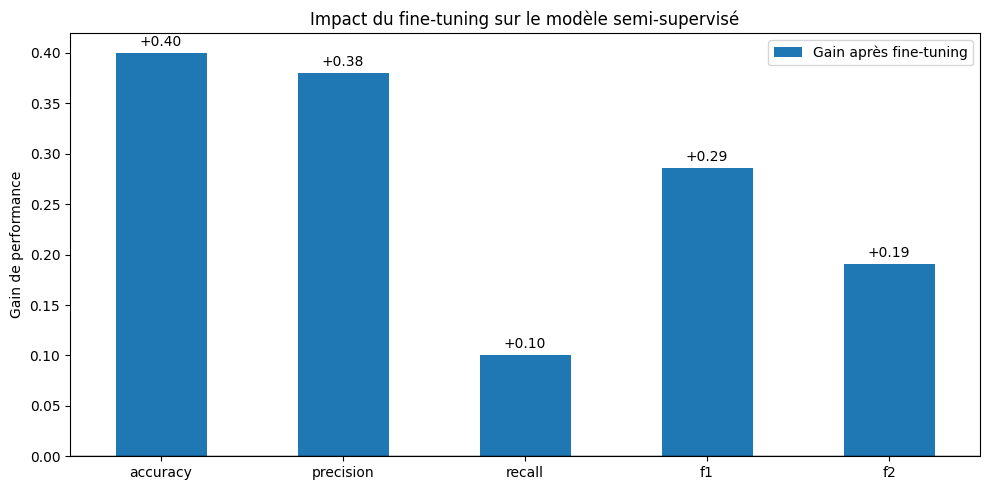

In [1810]:
metrics = ["accuracy", "precision", "recall", "f1", "f2"]

gain_finetuning = (
    pd.Series(semi_metrics)[metrics].astype(float)
    - pd.Series(semi_metrics_before)[metrics].astype(float)
)

gain_df = pd.DataFrame({
    "Gain après fine-tuning": gain_finetuning
})

ax = gain_df.plot(
    kind="bar",
    figsize=(10, 5)
)

ax.axhline(0, color="black", linewidth=1)

ax.set_title("Impact du fine-tuning sur le modèle semi-supervisé")
ax.set_ylabel("Gain de performance")
ax.set_xticklabels(metrics, rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%+.2f", padding=3)

plt.tight_layout()
plt.show()

<h4 style="color:#48C9B0;">Analyse de l'impact du fine-tuning</h4>

Le <i>fine-tuning</i> sur les données fortement labellisées améliore l'ensemble des performances du modèle semi-supervisé. Cette seconde phase permet d'affiner les représentations apprises lors du pré-entraînement sur les pseudo-labels en les adaptant à des annotations fiables.

Le gain le plus important est observé sur l'<b>accuracy</b> (<b>+0,40</b>) et sur la <b>précision</b> (<b>+0,38</b>), indiquant que le modèle produit davantage de prédictions correctes et réduit le nombre de faux positifs.

Le <b>score F1</b> progresse également de manière notable (<b>+0,29</b>), traduisant un meilleur équilibre entre précision et rappel. Le <b>score F2</b>, davantage orienté vers le rappel, augmente de <b>+0,19</b>, confirmant une amélioration globale des performances.

Enfin, le <b>rappel</b> progresse de <b>+0,10</b>. Bien que ce gain soit plus modéré, il montre que le modèle conserve sa capacité à détecter les cas cancéreux tout en améliorant sensiblement la qualité globale de ses prédictions.

Ces résultats montrent que le pré-entraînement sur les pseudo-labels fournit une base d'apprentissage pertinente, tandis que le <i>fine-tuning</i> sur les labels réels permet de spécialiser efficacement le modèle et de corriger une partie des erreurs liées à la pseudo-labellisation.


<h2 style="color:#48C9B0;">9. Comparaison des résultats</h2>

<h4 style="color:#48C9B0;">9.1 Supervisé vs semi-supervisé</h4>

Cette section compare les performances des différentes stratégies d'apprentissage afin d'évaluer l'apport des données non annotées dans la classification des IRM cérébrales.

<div style="border-left:5px solid #48C9B0;
background:#f8fdfc;
padding:14px 18px;
margin:18px 0;
color:black;">

<b>Objectif</b><br>

Je compare les performances du modèle supervisé et du modèle semi-supervisé, avant et après le <i>fine-tuning</i>, à l'aide des métriques de classification (accuracy, précision, rappel, F1 et F2).

Cette comparaison permet de mesurer l'apport du pré-entraînement sur les pseudo-labels ainsi que l'effet du <i>fine-tuning</i> sur les données fortement labellisées.

</div>

<h4 style="color:#48C9B0;">Configurations comparées</h4>

<ul>
<li><b>Modèle supervisé :</b> entraîné uniquement sur les données fortement labellisées ;</li>
<li><b>Semi-supervisé avant fine-tuning :</b> pré-entraîné sur les pseudo-labels ;</li>
<li><b>Semi-supervisé final :</b> pré-entraîné sur les pseudo-labels puis ajusté sur les données fortement labellisées.</li>
</ul>

Une attention particulière est portée au <b>Recall</b> et au <b>score F2</b>, les métriques les plus importantes dans ce contexte médical où la détection des cas cancéreux est prioritaire.


In [1811]:
comparison_df = pd.DataFrame([
    {
        "Approche": "Supervisée seule",
        **supervised_metrics
    },
    {
        "Approche": "S-supervisée av.ft",
        **semi_metrics_before
    },
    {
        "Approche": "S-supervisée apr.ft",
        **semi_metrics
    }
])

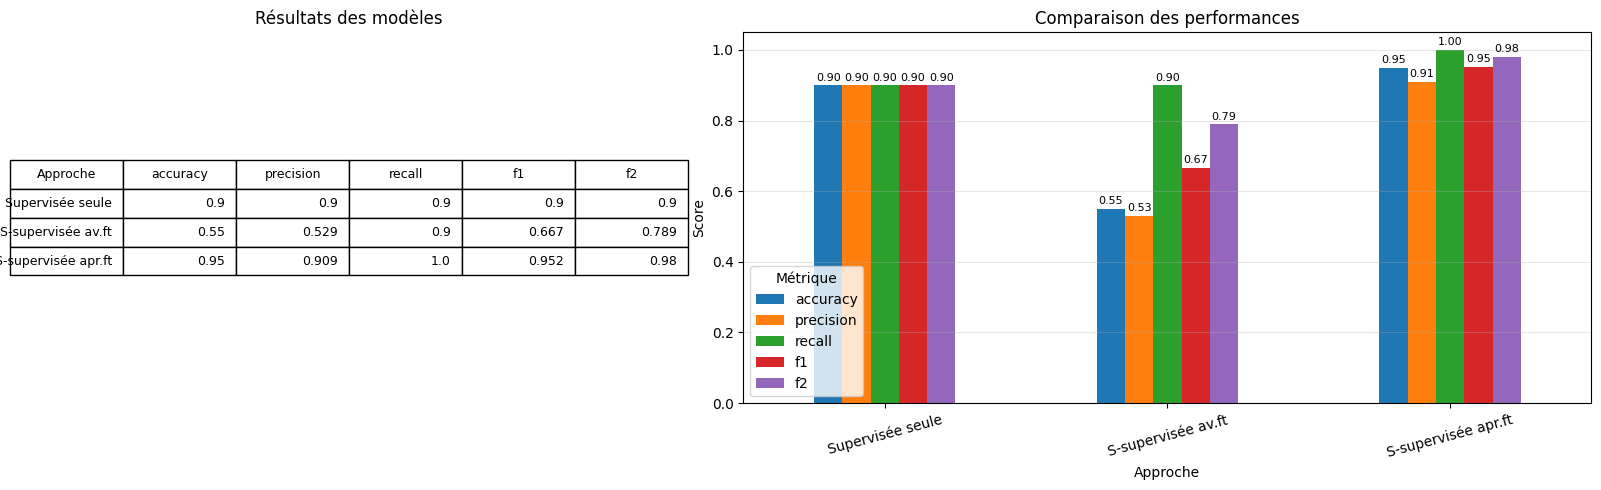

In [1812]:
# Tableau + graphique côte à côte
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 5),
    gridspec_kw={"width_ratios": [1.2, 1.8]}
)

# Tableau
axes[0].axis("off")
table_data = comparison_df.copy()
table = axes[0].table(
    cellText=table_data.round(3).values,
    colLabels=table_data.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.8)

axes[0].set_title("Résultats des modèles")

# Graphique
df_comparison_plot = comparison_df.set_index("Approche")

ax = df_comparison_plot.plot(
    kind="bar",
    ax=axes[1]
)

axes[1].set_title("Comparaison des performances")
axes[1].set_ylabel("Score")
axes[1].set_ylim(0, 1.05)
axes[1].tick_params(axis="x", rotation=15)
axes[1].legend(title="Métrique")
axes[1].grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=2,
        fontsize=8
    )

plt.tight_layout()
plt.show()

<h4 style="color:#48C9B0;">Analyse comparative des performances</h4>

Le modèle supervisé constitue la référence de l'étude. Entraîné uniquement sur les données fortement labellisées, il obtient des performances homogènes avec une <b>accuracy</b>, une <b>précision</b>, un <b>rappel</b>, un <b>score F1</b> et un <b>score F2</b> de <b>0,90</b>.

Le modèle semi-supervisé évalué après le seul pré-entraînement sur les pseudo-labels présente des performances plus faibles, avec une <b>accuracy de 0,55</b>, une <b>précision de 0,53</b>, un <b>rappel de 0,90</b>, un <b>score F1 de 0,67</b> et un <b>score F2 de 0,79</b>. Ces résultats montrent que les pseudo-labels permettent d'apprendre une première représentation des données, mais restent insuffisants pour atteindre les performances du modèle supervisé.

Après le <i>fine-tuning</i> sur les données fortement annotées, les performances progressent nettement sur l'ensemble des métriques. Le modèle atteint une <b>accuracy de 0,95</b>, une <b>précision de 0,91</b>, un <b>rappel de 1,00</b>, un <b>score F1 de 0,95</b> et un <b>score F2 de 0,98</b>. Le rappel parfait indique qu'aucun cas cancéreux n'est manqué sur le jeu de test.

Le modèle semi-supervisé final dépasse ainsi légèrement le modèle supervisé de référence sur toutes les métriques. Ces résultats suggèrent que le pré-entraînement sur les données pseudo-labellisées permet d'exploiter efficacement les informations contenues dans les images non annotées, tandis que le <i>fine-tuning</i> sur les labels réels corrige le bruit introduit par la pseudo-labellisation et spécialise le modèle pour la tâche de classification.

Compte tenu du faible nombre d'images présentes dans le jeu de test, ces écarts doivent toutefois être interprétés avec prudence. Ils mettent en évidence le potentiel de l'approche semi-supervisée, mais gagneraient à être confirmés sur un jeu de données annotées plus important.


<h4 style="color:#48C9B0;">9.2 Matrices de confusion</h4>

Les matrices de confusion complètent l'analyse des performances en détaillant les erreurs de classification réalisées par chaque modèle.

<div style="border-left:5px solid #48C9B0;
background:#f8fdfc;
padding:14px 18px;
margin:18px 0;
color:black;">

<b>Objectif</b><br>

J'analyse les matrices de confusion des modèles supervisé et semi-supervisé afin d'identifier les faux positifs et les faux négatifs, et d'évaluer l'impact du pré-entraînement puis du <i>fine-tuning</i> sur la qualité des prédictions.

Une attention particulière est portée aux faux négatifs, qui correspondent à des images cancéreuses classées comme normales et constituent l'erreur la plus critique dans ce contexte médical.

</div>

<h4 style="color:#48C9B0;">Interprétation des matrices</h4>

Les matrices de confusion permettent d'expliquer les différences observées entre les modèles en mettant en évidence la répartition des erreurs pour chaque classe. Elles complètent les métriques globales et facilitent l'interprétation des gains apportés par l'approche semi-supervisée.

Compte tenu de la taille limitée du jeu de test, ces résultats doivent toutefois être interprétés avec prudence.


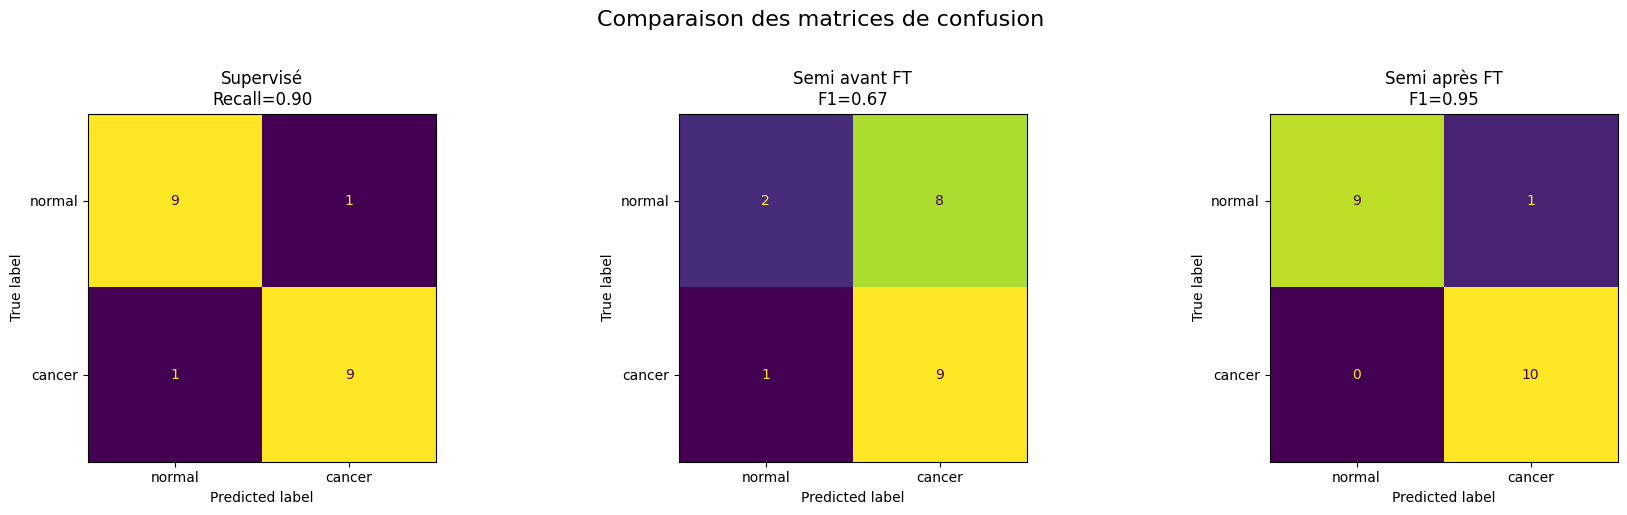

In [1813]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Supervisé
ConfusionMatrixDisplay.from_predictions(
    y_true_sup,
    y_pred_sup,
    display_labels=["normal", "cancer"],
    ax=axes[0],
    colorbar=False
)

axes[0].set_title(
    f"Supervisé\nRecall={supervised_metrics['recall']:.2f}"
)

# Semi-supervisé avant fine-tuning
ConfusionMatrixDisplay.from_predictions(
    y_true_before,
    y_pred_before,
    display_labels=["normal", "cancer"],
    ax=axes[1],
    colorbar=False
)

axes[1].set_title(
    f"Semi avant FT\nF1={semi_metrics_before['f1']:.2f}"
)

# Semi-supervisé après fine-tuning
ConfusionMatrixDisplay.from_predictions(
    y_true_semi,
    y_pred_semi,
    display_labels=["normal", "cancer"],
    ax=axes[2],
    colorbar=False
)

axes[2].set_title(
    f"Semi après FT\nF1={semi_metrics['f1']:.2f}"
)

plt.suptitle(
    "Comparaison des matrices de confusion",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

<h4 style="color:#48C9B0;">Interprétation des matrices de confusion</h4>

Les matrices de confusion permettent d'analyser précisément les erreurs de classification réalisées par les trois modèles.

Le <b>modèle supervisé</b> obtient <b>18 prédictions correctes sur 20</b>, avec un faux positif et un faux négatif. Les erreurs sont équilibrées entre les deux classes, ce qui explique les performances homogènes observées sur les différentes métriques.

Le <b>modèle semi-supervisé avant fine-tuning</b> détecte correctement la majorité des images cancéreuses (<b>1 seul faux négatif</b>), mais génère un nombre important de <b>faux positifs</b> (8 images normales prédites comme cancéreuses). Cette tendance explique sa faible précision et son score F1 inférieur à celui du modèle supervisé.

Après le <b>fine-tuning</b>, le modèle corrige la majorité de ces erreurs. Il ne présente plus aucun faux négatif et ne conserve qu'un seul faux positif, ce qui conduit à un <b>rappel de 1,00</b> et à une amélioration de l'ensemble des métriques de classification.

<div style="border-left:5px solid #48C9B0;background:#f8fdfc;padding:14px 18px;margin:18px 0;color:black;">

<b>À retenir</b><br>

Avec seulement <b>20 images</b> dans le jeu de test, une erreur représente <b>5 %</b> des observations. Les différences entre les modèles doivent donc être interprétées avec prudence. Malgré cette limite, les matrices montrent que le pré-entraînement fournit une première représentation utile, tandis que le <i>fine-tuning</i> sur les labels réels permet de corriger les erreurs les plus importantes et d'obtenir les meilleures performances.

</div>


<h4 style="color:#48C9B0;">9.3 Courbes d'apprentissage</h4>

Les courbes d'apprentissage permettent de suivre l'évolution des performances des modèles au cours de l'entraînement. Elles complètent les métriques finales en offrant une vision de leur convergence et de leur capacité à généraliser.

<div style="border-left:5px solid #48C9B0;
background:#f8fdfc;
padding:14px 18px;
margin:18px 0;
color:black;">

<b>Objectif</b><br>

J'analyse l'évolution de la <i>Loss</i> et du <i>Recall</i> sur les jeux d'entraînement et de validation afin d'étudier le comportement des modèles au fil des époques.

Ces courbes permettent d'évaluer la convergence, de détecter un éventuel surapprentissage et de comparer la dynamique d'apprentissage du modèle supervisé, du pré-entraînement semi-supervisé et du modèle final après <i>fine-tuning</i>.

</div>

<h4 style="color:#48C9B0;">Lecture des courbes</h4>

Une diminution progressive de la <i>Loss</i> traduit une meilleure convergence du modèle, tandis que l'évolution du <i>Recall</i> indique sa capacité à détecter les images cancéreuses. L'analyse conjointe de ces deux indicateurs permet de vérifier la stabilité de l'apprentissage et d'interpréter les performances finales obtenues sur le jeu de test.


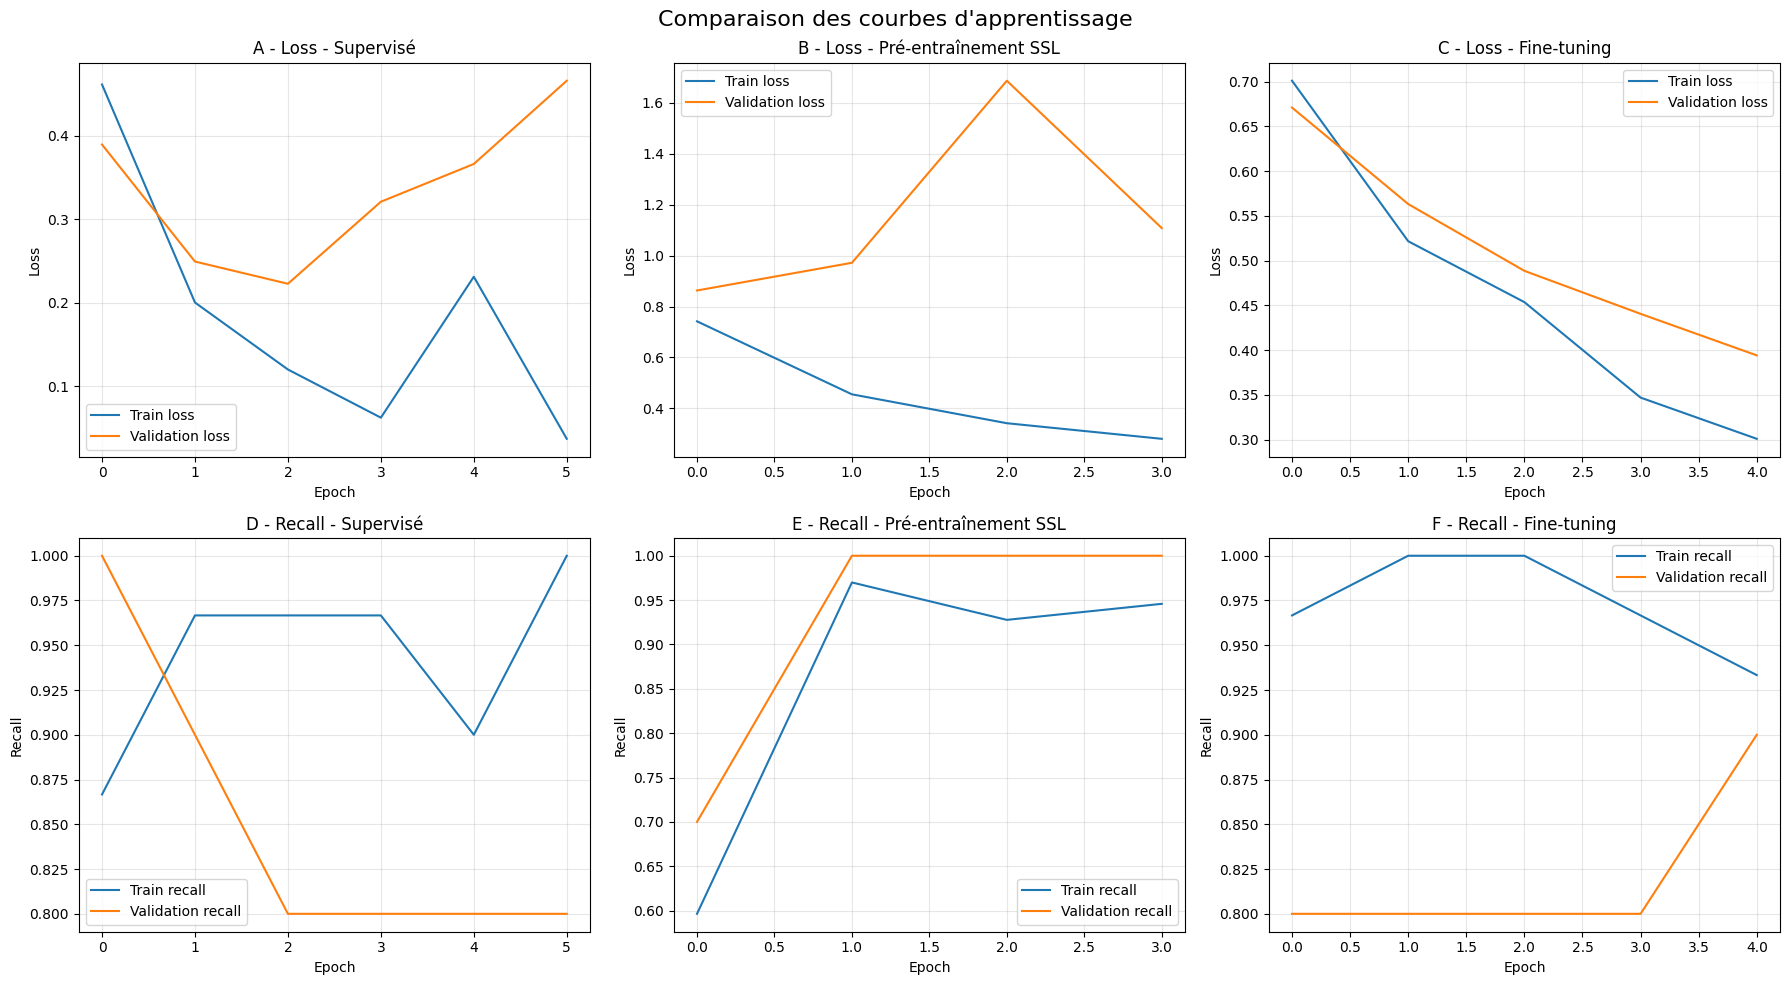

In [1814]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 10)
)

# Loss

# Supervisé
axes[0, 0].plot(
    history_supervised["train_loss"],
    label="Train loss"
)

axes[0, 0].plot(
    history_supervised["val_loss"],
    label="Validation loss"
)

axes[0, 0].set_title("A - Loss - Supervisé")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Semi avant fine-tuning
axes[0, 1].plot(
    history_weak["train_loss"],
    label="Train loss"
)

axes[0, 1].plot(
    history_weak["val_loss"],
    label="Validation loss"
)

axes[0, 1].set_title("B - Loss - Pré-entraînement SSL")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Semi après fine-tuning
axes[0, 2].plot(
    history_finetune["train_loss"],
    label="Train loss"
)

axes[0, 2].plot(
    history_finetune["val_loss"],
    label="Validation loss"
)

axes[0, 2].set_title("C - Loss - Fine-tuning")
axes[0, 2].set_xlabel("Epoch")
axes[0, 2].set_ylabel("Loss")
axes[0, 2].legend()
axes[0, 2].grid(alpha=0.3)

# Recall

# Supervisé
axes[1, 0].plot(
    history_supervised["train_recall"],
    label="Train recall"
)

axes[1, 0].plot(
    history_supervised["val_recall"],
    label="Validation recall"
)

axes[1, 0].set_title("D - Recall - Supervisé")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Recall")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Semi avant fine-tuning
axes[1, 1].plot(
    history_weak["train_recall"],
    label="Train recall"
)

axes[1, 1].plot(
    history_weak["val_recall"],
    label="Validation recall"
)

axes[1, 1].set_title("E - Recall - Pré-entraînement SSL")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Recall")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

# Semi après fine-tuning
axes[1, 2].plot(
    history_finetune["train_recall"],
    label="Train recall"
)

axes[1, 2].plot(
    history_finetune["val_recall"],
    label="Validation recall"
)

axes[1, 2].set_title("F - Recall - Fine-tuning")
axes[1, 2].set_xlabel("Epoch")
axes[1, 2].set_ylabel("Recall")
axes[1, 2].legend()
axes[1, 2].grid(alpha=0.3)

plt.suptitle(
    "Comparaison des courbes d'apprentissage",
    fontsize=16
)

plt.tight_layout()
plt.show()

<h4 style="color:#48C9B0;">Interprétation des courbes d'apprentissage</h4>

Les courbes d'apprentissage mettent en évidence des comportements distincts entre le modèle supervisé, le pré-entraînement semi-supervisé et la phase de <i>fine-tuning</i>.

Le <b>modèle supervisé</b> converge rapidement : la perte d'entraînement diminue de façon régulière, tandis que la perte de validation cesse de s'améliorer après quelques époques puis augmente progressivement. Cette divergence suggère un début de surapprentissage. Le rappel de validation diminue parallèlement pour se stabiliser autour de <b>0,80</b>, ce qui justifie l'utilisation de l'<i>Early Stopping</i>.

Lors du <b>pré-entraînement semi-supervisé</b>, la perte d'entraînement diminue également, mais la perte de validation est plus instable en raison du bruit introduit par les pseudo-labels. Malgré cette variabilité, le rappel de validation atteint rapidement <b>1,00</b>, montrant que le modèle apprend à détecter efficacement les images cancéreuses dès cette première phase.

Enfin, le <b>fine-tuning</b> sur les données fortement annotées permet de réduire simultanément les pertes d'entraînement et de validation, signe d'une meilleure adaptation aux labels réels. Le rappel de validation reste élevé tout au long de l'entraînement et atteint <b>0,90</b> à la dernière époque, traduisant une bonne capacité de généralisation.

Dans l'ensemble, ces courbes montrent que le pré-entraînement fournit une représentation initiale pertinente des données non annotées, tandis que le <i>fine-tuning</i> permet de corriger le bruit lié aux pseudo-labels et de stabiliser les performances avant l'évaluation finale sur le jeu de test.


In [1815]:
# Sauvegarde des résultats
comparison_df.to_csv(
    "../data/features/comparaison_supervise_semi_supervise.csv",
    index=False
)

print("Résultats sauvegardés.")

Résultats sauvegardés.


<h4 style="color:#48C9B0;">9.4 Analyse de la robustesse sur plusieurs <i>seeds</i></h4>

<div style="border-left:5px solid #48C9B0;
background:#f8fdfc;
padding:14px 18px;
margin:18px 0;
color:black;">

<b>Objectif</b><br>

Afin d'évaluer la robustesse des performances, j'entraîne le modèle supervisé sur <b>cinq découpages aléatoires différents</b> des données fortement labellisées (seeds 0, 42, 123, 2025 et 999).

Pour chaque seed, un nouveau découpage <i>train / validation / test</i> est généré selon la même procédure, tandis que le jeu de données faiblement labellisé est conservé identique afin d'isoler l'effet du découpage des données annotées.

Les performances sont ensuite résumées sous la forme <b>moyenne ± écart-type</b>. Cette analyse permet de vérifier que les résultats ne dépendent pas d'un unique découpage et d'estimer la variabilité des performances sur un jeu de données de petite taille.

</div>

<h4 style="color:#48C9B0;">Reconstruction des Dataset</h4>

In [1816]:
strong_df = pd.concat(
    [
        strong_train_df,
        strong_val_df,
        strong_test_df
    ],
    ignore_index=True
)

print(len(strong_df))
print(strong_df["label"].value_counts())

99
label
1    50
0    49
Name: count, dtype: int64


In [1817]:
def verifier_split(train_df, val_df, test_df):
    print("Répartition train :")
    print(train_df["label"].value_counts())

    print("\nRépartition val :")
    print(val_df["label"].value_counts())

    print("\nRépartition test :")
    print(test_df["label"].value_counts())

    assert train_df["label"].nunique() == 2, "Train incomplet"
    assert val_df["label"].nunique() == 2, "Val incomplet"
    assert test_df["label"].nunique() == 2, "Test incomplet"

<h4 style="color:#48C9B0;">Lancement</h4>

In [1818]:
if analyse_seed:
    SEEDS = [0, 42, 123, 2025, 999]

    resultats_multiseed = []

    for seed in SEEDS:
        print(f"\nSEED : {seed}")

        # Split 60 / 20 / 20
        train_df, temp_df = train_test_split(
            strong_df,
            test_size=0.40,
            stratify=strong_df["label"],
            random_state=seed
        )

        val_df, test_df = train_test_split(
            temp_df,
            test_size=0.50,
            stratify=temp_df["label"],
            random_state=seed
        )

        # Datasets forts
        train_dataset = BrainDataset(train_df, transform=train_transform)
        val_dataset = BrainDataset(val_df, transform=eval_transform)
        test_dataset = BrainDataset(test_df, transform=eval_transform)

        verifier_split(train_df, val_df, test_df)


        # Loaders
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
        test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

        # Modèle supervisé
        supervised_model = create_resnet18_model()
        supervised_model = freeze_all_but_layer4_and_fc(supervised_model)
        supervised_model = supervised_model.to(device)

        optimizer_sup = torch.optim.Adam(
            filter(lambda p: p.requires_grad, supervised_model.parameters()),
            lr=LEARNING_RATE,
            weight_decay=1e-4
        )

        supervised_model, history_sup = train_model(
            model=supervised_model,
            train_loader=train_loader,
            val_loader=val_loader,
            criterion=criterion,
            optimizer=optimizer_sup,
            num_epochs=NUM_EPOCHS_SUPERVISED,
            device=device,
            patience=PATIENCE
        )

        metrics_sup, _, _ = evaluate_model(
            supervised_model,
            test_loader,
            device
        )

        # Modèle semi-supervisé
        semi_model_seed = create_resnet18_model()
        semi_model_seed = freeze_all_but_layer4_and_fc(semi_model_seed)
        semi_model_seed = semi_model_seed.to(device)

        optimizer_weak = torch.optim.Adam(
            filter(lambda p: p.requires_grad, semi_model_seed.parameters()),
            lr=LEARNING_RATE,
            weight_decay=1e-4
        )

        semi_model_seed, history_weak = train_model(
            model=semi_model_seed,
            train_loader=weak_train_loader,
            val_loader=val_loader,
            criterion=criterion,
            optimizer=optimizer_weak,
            num_epochs=NUM_EPOCHS_WEAK,
            device=device,
            patience=PATIENCE
        )

        optimizer_ft = torch.optim.Adam(
            filter(lambda p: p.requires_grad, semi_model_seed.parameters()),
            lr=LEARNING_RATE_FINE,
            weight_decay=1e-4
        )

        semi_model_seed, history_ft = train_model(
            model=semi_model_seed,
            train_loader=train_loader,
            val_loader=val_loader,
            criterion=criterion,
            optimizer=optimizer_ft,
            num_epochs=NUM_EPOCHS_FINETUNE,
            device=device,
            patience=PATIENCE_FINE
        )

        metrics_semi, _, _ = evaluate_model(
            semi_model_seed,
            test_loader,
            device
        )

        # Sauvegarde résultats
        resultats_multiseed.append({
            "seed": seed,

            "accuracy_supervise": metrics_sup["accuracy"],
            "precision_supervise": metrics_sup["precision"],
            "recall_supervise": metrics_sup["recall"],
            "f1_supervise": metrics_sup["f1"],
            "f2_supervise": metrics_sup["f2"],

            "accuracy_semi": metrics_semi["accuracy"],
            "precision_semi": metrics_semi["precision"],
            "recall_semi": metrics_semi["recall"],
            "f1_semi": metrics_semi["f1"],
            "f2_semi": metrics_semi["f2"],
        })

    df_multiseed = pd.DataFrame(resultats_multiseed)
    display(df_multiseed)


SEED : 0
Répartition train :
label
1    30
0    29
Name: count, dtype: int64

Répartition val :
label
1    10
0    10
Name: count, dtype: int64

Répartition test :
label
1    10
0    10
Name: count, dtype: int64
Epoch 1/20 | Train loss: 0.5413 | Train acc: 0.7458 | Train recall: 0.8667 | Train F1: 0.7761 | Train F2: 0.8280 | Val loss: 0.3030 | Val acc: 0.9000 | Val recall: 0.8000Val precision: 1.0000 | Val F1: 0.8889 | Val F2: 0.8333 | 
Epoch 2/20 | Train loss: 0.2159 | Train acc: 0.8983 | Train recall: 0.9333 | Train F1: 0.9032 | Train F2: 0.9211 | Val loss: 0.3044 | Val acc: 0.8500 | Val recall: 0.8000Val precision: 0.8889 | Val F1: 0.8421 | Val F2: 0.8163 | 
Epoch 3/20 | Train loss: 0.0572 | Train acc: 0.9831 | Train recall: 1.0000 | Train F1: 0.9836 | Train F2: 0.9934 | Val loss: 0.3947 | Val acc: 0.8500 | Val recall: 0.8000Val precision: 0.8889 | Val F1: 0.8421 | Val F2: 0.8163 | 
Epoch 4/20 | Train loss: 0.2217 | Train acc: 0.8983 | Train recall: 0.9000 | Train F1: 0.9000 | Trai

,seed,accuracy_supervise,precision_supervise,recall_supervise,f1_supervise,f2_supervise,accuracy_semi,precision_semi,recall_semi,f1_semi,f2_semi
0,0,1.00,1.000000,1.0,1.000000,1.000000,1.00,1.000000,1.0,1.000000,1.000000
1,42,0.90,0.900000,0.9,0.900000,0.900000,0.90,0.900000,0.9,0.900000,0.900000
2,123,0.95,0.909091,1.0,0.952381,0.980392,0.85,0.818182,0.9,0.857143,0.882353
3,2025,0.95,1.000000,0.9,0.947368,0.918367,0.90,0.833333,1.0,0.909091,0.961538
4,999,0.90,0.833333,1.0,0.909091,0.961538,0.75,0.666667,1.0,0.800000,0.909091


<h4 style="color:#48C9B0;">Analyse de la robustesse selon les seeds</h4>

Les performances restent globalement stables sur les cinq découpages étudiés. Le modèle supervisé obtient une accuracy comprise entre <b>0,90 et 1,00</b>, tandis que le modèle semi-supervisé varie entre <b>0,75 et 1,00</b> tout en conservant un <b>Recall élevé (0,90 à 1,00)</b>.

Les deux approches obtiennent des performances identiques pour certaines seeds (0 et 42). Pour les autres découpages, le modèle supervisé présente un léger avantage sur les métriques globales, alors que le modèle semi-supervisé conserve une bonne capacité à détecter les cas cancéreux.

<b>Ces résultats montrent que les performances restent sensibles au découpage des données, en raison du faible nombre d'images annotées et d'un jeu de test limité à 20 images, où une seule erreur représente déjà 5 % des observations. Les écarts observés entre les deux approches doivent donc être interprétés avec prudence.</b>


<h4 style="color:#48C9B0;">Visualisation</h4>

In [1819]:
if analyse_seed:
    # Copie de sécurité
    df_plot = df_multiseed.copy()

    # Ordre des seeds en texte pour l'affichage
    df_plot["seed_str"] = df_plot["seed"].astype(str)

    # Création des gains si besoin
    df_plot["gain_accuracy"] = df_plot["accuracy_semi"] - df_plot["accuracy_supervise"]
    df_plot["gain_precision"] = df_plot["precision_semi"] - df_plot["precision_supervise"]
    df_plot["gain_recall"] = df_plot["recall_semi"] - df_plot["recall_supervise"]
    df_plot["gain_f1"] = df_plot["f1_semi"] - df_plot["f1_supervise"]
    df_plot["gain_f2"] = df_plot["f2_semi"] - df_plot["f2_supervise"]

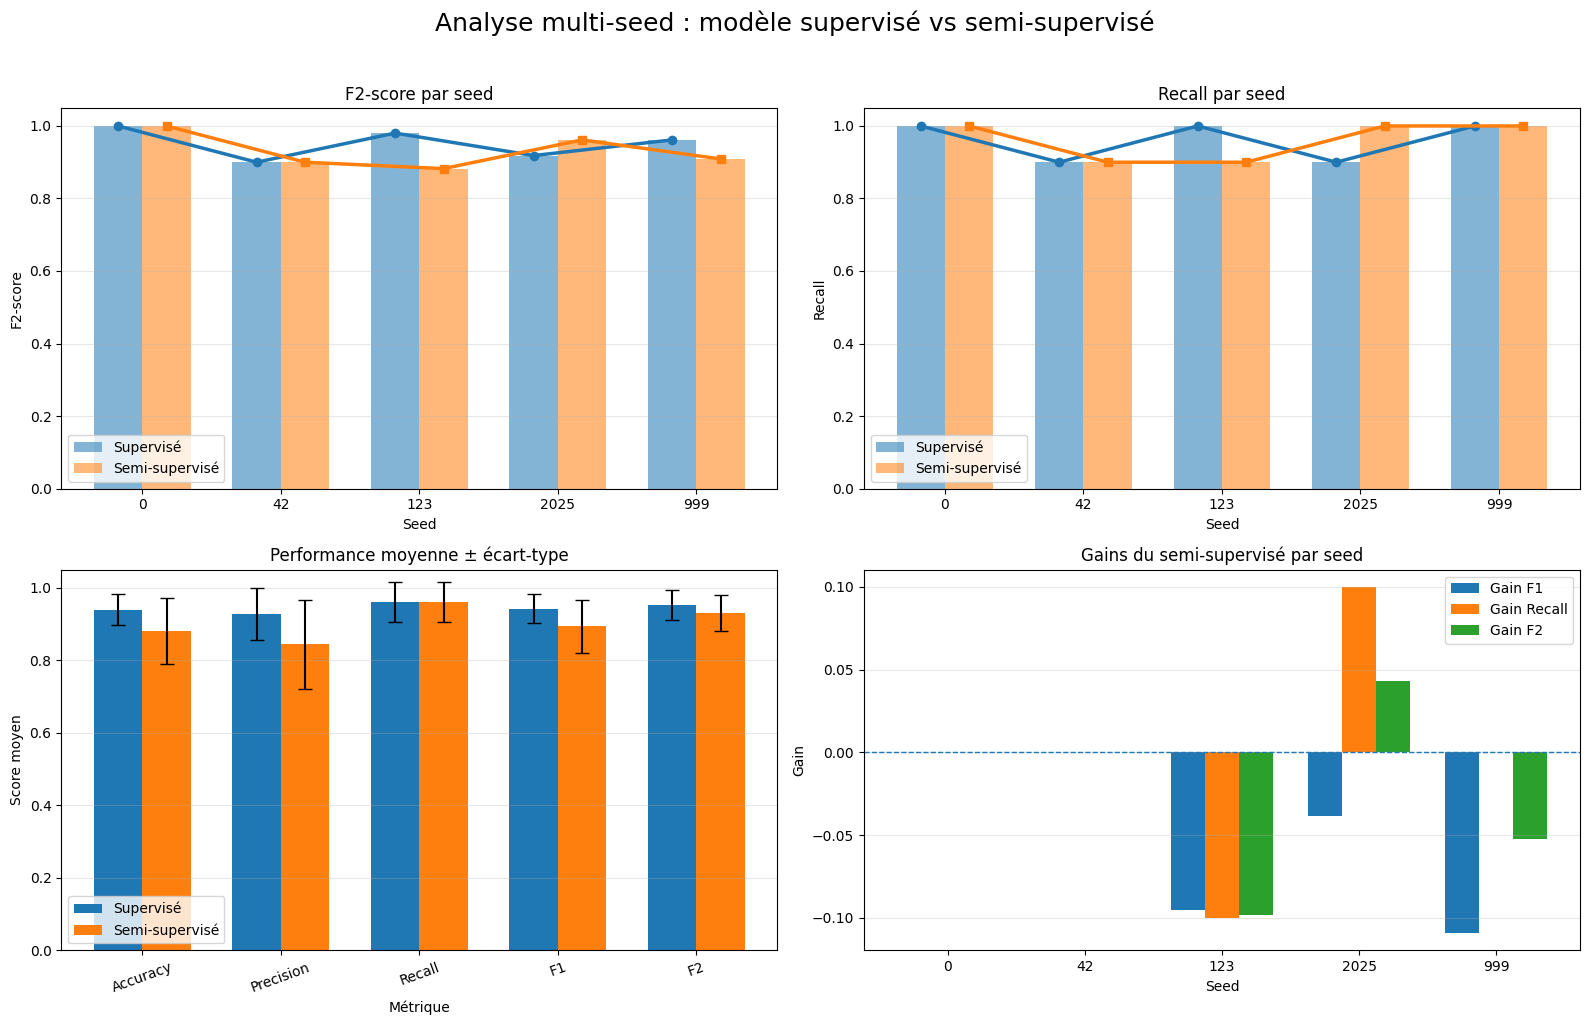

In [1820]:
if analyse_seed :
    # Seeds en catégories, pas en valeurs numériques continues
    df_plot["seed_str"] = df_plot["seed"].astype(str)
    x = np.arange(len(df_plot))
    width = 0.35

    # Gains si absents
    df_plot["gain_f1"] = df_plot["f1_semi"] - df_plot["f1_supervise"]
    df_plot["gain_recall"] = df_plot["recall_semi"] - df_plot["recall_supervise"]
    df_plot["gain_f2"] = df_plot["f2_semi"] - df_plot["f2_supervise"]

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # 1. F1-score par seed
    axes[0, 0].bar(
        x - width / 2,
        df_plot["f2_supervise"],
        width,
        alpha=0.55,
        label="Supervisé"
    )

    axes[0, 0].bar(
        x + width / 2,
        df_plot["f2_semi"],
        width,
        alpha=0.55,
        label="Semi-supervisé"
    )

    # Courbes
    axes[0, 0].plot(
        x - width/2,
        df_plot["f2_supervise"],
        marker="o",
        linewidth=2.5
    )

    axes[0, 0].plot(
        x + width/2,
        df_plot["f2_semi"],
        marker="s",
        linewidth=2.5
    )

    axes[0, 0].set_title("F2-score par seed")
    axes[0, 0].set_xlabel("Seed")
    axes[0, 0].set_ylabel("F2-score")
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels(df_plot["seed_str"])
    axes[0, 0].set_ylim(0,1.05)
    axes[0, 0].grid(axis="y", alpha=.3)
    axes[0, 0].legend()

    # 2. Recall par seed
    axes[0,1].bar(
        x-width/2,
        df_plot["recall_supervise"],
        width,
        alpha=0.55,
        label="Supervisé"
    )

    axes[0,1].bar(
        x+width/2,
        df_plot["recall_semi"],
        width,
        alpha=0.55,
        label="Semi-supervisé"
    )

    # Courbes
    axes[0,1].plot(
        x-width/2,
        df_plot["recall_supervise"],
        marker="o",
        linewidth=2.5
    )

    axes[0,1].plot(
        x+width/2,
        df_plot["recall_semi"],
        marker="s",
        linewidth=2.5
    )

    axes[0,1].set_title("Recall par seed")
    axes[0,1].set_xlabel("Seed")
    axes[0,1].set_ylabel("Recall")
    axes[0,1].set_xticks(x)
    axes[0,1].set_xticklabels(df_plot["seed_str"])
    axes[0,1].set_ylim(0,1.05)
    axes[0,1].grid(axis="y", alpha=.3)
    axes[0,1].legend()

    # 3. Moyenne ± écart-type
    metrics = ["accuracy", "precision", "recall", "f1", "f2"]
    labels = ["Accuracy", "Precision", "Recall", "F1", "F2"]

    mean_supervise = [df_plot[f"{m}_supervise"].mean() for m in metrics]
    std_supervise = [df_plot[f"{m}_supervise"].std() for m in metrics]

    mean_semi = [df_plot[f"{m}_semi"].mean() for m in metrics]
    std_semi = [df_plot[f"{m}_semi"].std() for m in metrics]

    x_metrics = np.arange(len(metrics))

    axes[1, 0].bar(
        x_metrics - width / 2,
        mean_supervise,
        width,
        yerr=std_supervise,
        capsize=5,
        label="Supervisé"
    )

    axes[1, 0].bar(
        x_metrics + width / 2,
        mean_semi,
        width,
        yerr=std_semi,
        capsize=5,
        label="Semi-supervisé"
    )

    axes[1, 0].set_title("Performance moyenne ± écart-type")
    axes[1, 0].set_xlabel("Métrique")
    axes[1, 0].set_ylabel("Score moyen")
    axes[1, 0].set_xticks(x_metrics)
    axes[1, 0].set_xticklabels(labels, rotation=20)
    axes[1, 0].set_ylim(0, 1.05)
    axes[1, 0].grid(axis="y", alpha=0.3)
    axes[1, 0].legend()

    # 4. Gains du semi-supervisé
    gain_metrics = ["gain_f1", "gain_recall", "gain_f2"]
    gain_labels = ["Gain F1", "Gain Recall", "Gain F2"]

    x_gain = np.arange(len(df_plot))
    gain_width = 0.25

    for i, gain in enumerate(gain_metrics):
        axes[1, 1].bar(
            x_gain + (i - 1) * gain_width,
            df_plot[gain],
            gain_width,
            label=gain_labels[i]
        )

    axes[1, 1].axhline(0, linestyle="--", linewidth=1)
    axes[1, 1].set_title("Gains du semi-supervisé par seed")
    axes[1, 1].set_xlabel("Seed")
    axes[1, 1].set_ylabel("Gain")
    axes[1, 1].set_xticks(x_gain)
    axes[1, 1].set_xticklabels(df_plot["seed_str"])
    axes[1, 1].grid(axis="y", alpha=0.3)
    axes[1, 1].legend()

    # Mise en forme générale
    fig.suptitle(
        "Analyse multi-seed : modèle supervisé vs semi-supervisé",
        fontsize=18,
        y=1.02
    )

    plt.tight_layout()
    plt.show()

<h4 style="color:#48C9B0;">Analyse multi-seed</h4>

Les performances des deux approches restent globalement stables sur les cinq découpages étudiés. Les moyennes et les écarts-types sont proches, ce qui montre que le modèle semi-supervisé présente une robustesse comparable à celle du modèle supervisé.

Le modèle supervisé conserve un léger avantage sur les métriques globales (Accuracy, F1 et F2), tandis que le modèle semi-supervisé obtient un <b>Recall moyen légèrement supérieur</b>, critère prioritaire dans le contexte médical étudié. Les gains observés varient selon les seeds, avec une amélioration du Recall pour certaines configurations (notamment la <b>seed 2025</b>) et de légères diminutions pour d'autres.

Ces résultats montrent que les performances restent sensibles au découpage des données.

<h4 style="color:#48C9B0;">9.5 Influence du budget d'annotation</h4>

Le coût de l'annotation constitue une contrainte majeure en imagerie médicale. Cette expérimentation évalue l'intérêt de la pseudo-labellisation lorsque le nombre d'images annotées est limité.

<div style="border-left:5px solid #48C9B0;
background:#f8fdfc;
padding:14px 18px;
margin:18px 0;
color:black;">

<b>Objectif</b><br>

J'étudie l'impact du nombre d'images annotées sur les performances des modèles supervisé et semi-supervisé.

Pour plusieurs budgets d'annotation, je construis un jeu d'entraînement équilibré entre les profils <i>Normal</i> et <i>Cancer</i>. Les deux modèles sont ensuite entraînés dans les mêmes conditions afin de comparer leurs performances.

Cette analyse permet de déterminer si les pseudo-labels apportent un bénéfice lorsque les annotations réelles sont limitées et d'identifier à partir de quel volume de données annotées leur contribution devient moins importante.

</div>

In [1821]:
if analyse_budgets :
    budgets = [10, 20, 30, 40, 50, 58]
    resultats_budget = []

    for n in budgets:

        print(f"\n===== Budget labels forts : {n} images =====")

        n_par_classe = n // 2

        petit_train_df = pd.concat([
            strong_train_df[strong_train_df["label"] == 0].sample(
                n=n_par_classe,
                random_state=42
            ),
            strong_train_df[strong_train_df["label"] == 1].sample(
                n=n_par_classe,
                random_state=42
            )
        ]).sample(frac=1, random_state=42).reset_index(drop=True)

        print(petit_train_df["label"].value_counts().to_dict())

        petit_train_dataset = BrainDataset(
            petit_train_df,
            transform=train_transform
        )

        petit_train_loader = DataLoader(
            petit_train_dataset,
            batch_size=BATCH_SIZE,
            shuffle=True
        )

        # 1. Supervisé pur
        supervised_budget_model = create_resnet18_model()
        
        supervised_budget_model = freeze_all_but_layer4_and_fc(supervised_budget_model)

        optimizer_sup = torch.optim.Adam(
            filter(lambda p: p.requires_grad, supervised_budget_model.parameters()),
            lr=LEARNING_RATE,
            weight_decay=1e-4
        )

        supervised_budget_model, history_sup = train_model(
            model=supervised_budget_model,
            train_loader=petit_train_loader,
            val_loader=strong_val_loader,
            criterion=criterion,
            optimizer=optimizer_sup,
            num_epochs=NUM_EPOCHS_SUPERVISED,
            device=device,
            patience=PATIENCE
        )

        metrics_sup, _, _ = evaluate_model(
            supervised_budget_model,
            strong_test_loader,
            device
        )

        # 2. Semi-supervisé
        semi_budget_model = create_resnet18_model()
        semi_budget_model = freeze_all_but_layer4_and_fc(semi_budget_model)

        optimizer_pretrain = torch.optim.Adam(
            filter(lambda p: p.requires_grad, semi_budget_model.parameters()),
            lr=LEARNING_RATE,
            weight_decay=1e-4
        )

        semi_budget_model, history_pretrain = train_model(
            model=semi_budget_model,
            train_loader=weak_train_loader,
            val_loader=strong_val_loader,
            criterion=criterion,
            optimizer=optimizer_pretrain,
            num_epochs=NUM_EPOCHS_WEAK,
            device=device,
            patience=PATIENCE
        )

        optimizer_finetune = torch.optim.Adam(
            filter(lambda p: p.requires_grad, semi_budget_model.parameters()),
            lr=LEARNING_RATE_FINE,
            weight_decay=1e-4
        )

        semi_budget_model, history_finetune = train_model(
            model=semi_budget_model,
            train_loader=petit_train_loader,
            val_loader=strong_val_loader,
            criterion=criterion,
            optimizer=optimizer_finetune,
            num_epochs=NUM_EPOCHS_FINETUNE,
            device=device,
            patience=PATIENCE_FINE
        )

        metrics_semi, _, _ = evaluate_model(
            semi_budget_model,
            strong_test_loader,
            device
        )

        resultats_budget.append({
            "budget_labels": n,

            "f1_supervise": metrics_sup["f1"],
            "recall_supervise": metrics_sup["recall"],
            "precision_supervise": metrics_sup["precision"],
            "accuracy_supervise": metrics_sup["accuracy"],

            "f1_semi_supervise": metrics_semi["f1"],
            "recall_semi_supervise": metrics_semi["recall"],
            "precision_semi_supervise": metrics_semi["precision"],
            "accuracy_semi_supervise": metrics_semi["accuracy"],

            "gain_f1": metrics_semi["f1"] - metrics_sup["f1"]
        })

    resultats_budget_df = pd.DataFrame(resultats_budget)
    resultats_budget_df


===== Budget labels forts : 10 images =====
{1: 5, 0: 5}
Epoch 1/20 | Train loss: 0.9115 | Train acc: 0.6000 | Train recall: 0.2000 | Train F1: 0.3333 | Train F2: 0.2381 | Val loss: 0.9156 | Val acc: 0.5000 | Val recall: 0.0000Val precision: 0.0000 | Val F1: 0.0000 | Val F2: 0.0000 | 
Epoch 2/20 | Train loss: 0.4589 | Train acc: 0.8000 | Train recall: 0.6000 | Train F1: 0.7500 | Train F2: 0.6522 | Val loss: 0.9859 | Val acc: 0.5000 | Val recall: 0.0000Val precision: 0.0000 | Val F1: 0.0000 | Val F2: 0.0000 | 
Epoch 3/20 | Train loss: 0.0753 | Train acc: 1.0000 | Train recall: 1.0000 | Train F1: 1.0000 | Train F2: 1.0000 | Val loss: 1.0323 | Val acc: 0.5000 | Val recall: 0.0000Val precision: 0.0000 | Val F1: 0.0000 | Val F2: 0.0000 | 
Epoch 4/20 | Train loss: 0.2704 | Train acc: 0.8000 | Train recall: 0.6000 | Train F1: 0.7500 | Train F2: 0.6522 | Val loss: 1.1275 | Val acc: 0.5000 | Val recall: 0.0000Val precision: 0.0000 | Val F1: 0.0000 | Val F2: 0.0000 | 
Early stopping déclenché.


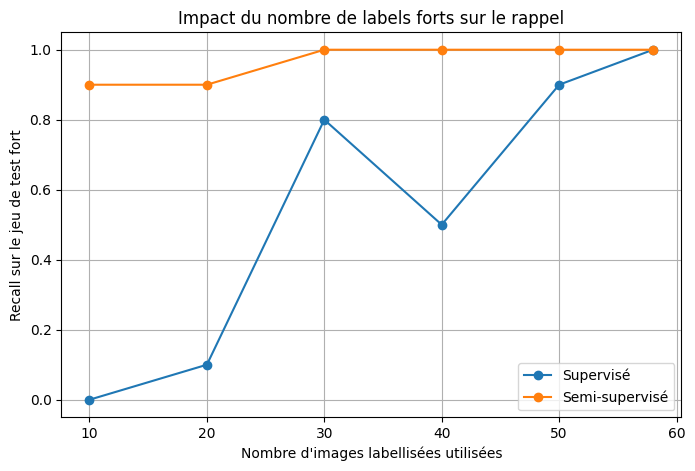

In [1822]:
if analyse_budgets:
    plt.figure(figsize=(8, 5))

    plt.plot(
        resultats_budget_df["budget_labels"],
        resultats_budget_df["recall_supervise"],
        marker="o",
        label="Supervisé"
    )

    plt.plot(
        resultats_budget_df["budget_labels"],
        resultats_budget_df["recall_semi_supervise"],
        marker="o",
        label="Semi-supervisé"
    )

    plt.xlabel("Nombre d'images labellisées utilisées")
    plt.ylabel("Recall sur le jeu de test fort")
    plt.title(
        "Impact du nombre de labels forts sur le rappel"
    )

    plt.legend()
    plt.grid(True)

    plt.show()

<h4 style="color:#48C9B0;">Impact du budget d'annotation sur les performances</h4>

Cette expérimentation montre que l'approche semi-supervisée est particulièrement avantageuse lorsque le nombre d'images annotées est faible.

Avec seulement <b>10 à 20 images annotées</b>, le modèle semi-supervisé atteint déjà un <b>Recall de 0,90</b>, alors que le modèle supervisé obtient des performances nettement plus faibles. Cet écart montre que les pseudo-labels compensent efficacement le manque de données annotées.

Lorsque le budget d'annotation augmente, les performances du modèle supervisé progressent progressivement et se rapprochent de celles du modèle semi-supervisé. À partir de <b>60 images annotées</b>, les deux approches atteignent un <b>Recall de 1,00</b>, ce qui indique que l'apport des pseudo-labels devient plus limité lorsque suffisamment de labels réels sont disponibles.

Ces résultats confirment que l'approche semi-supervisée est particulièrement pertinente dans les contextes où le coût de l'annotation est élevé et où seules quelques images annotées sont disponibles. Toutefois, ils doivent être interprétés avec prudence en raison de la taille réduite du jeu de test.


<h4 style="color:#48C9B0;">9.6 Synthèse des résultats et définition d'un modèle opérationnel</h4>

Cette dernière analyse permet de mettre en perspective les expérimentations réalisées tout au long de ce notebook afin d'évaluer si le modèle répond aux objectifs fixés pour le projet.

<div style="border-left:5px solid #48C9B0;
background:#f8fdfc;
padding:14px 18px;
margin:18px 0;
color:black;">

<b>Objectif</b><br><br>

Déterminer si le modèle développé constitue une preuve de concept convaincante et identifier les conditions nécessaires à une éventuelle utilisation en pratique.

</div>

Dans cette étude, le critère principal est le <b>Recall</b> sur la classe <i>Cancer</i>, complété par le <b>score F2</b>, afin de limiter au maximum les faux négatifs.

Le modèle semi-supervisé final obtient un <b>Recall de 1,00</b> et un <b>score F2 de 0,98</b> sur le jeu de test. Ces résultats montrent que l'exploitation des pseudo-labels peut améliorer les performances lorsque le nombre de données annotées est limité.

Ils doivent toutefois être interprétés avec prudence. Le jeu de test ne comporte que <b>20 images</b>, si bien qu'une seule erreur modifie sensiblement les métriques obtenues.

Le modèle peut ainsi être considéré comme une <b>preuve de concept validée</b>. Une validation sur un jeu de données externe plus volumineux et annoté par des experts restera néanmoins indispensable avant toute utilisation en pratique clinique.


<h2 style="color:#48C9B0;">10. Conclusion</h2>

<h4 style="color:#48C9B0;">10.1 Bilan de la démarche semi-supervisée</h4>

Tout au long de ce notebook, j'ai mis en œuvre une approche semi-supervisée visant à exploiter conjointement les données fortement annotées et les nombreuses images non labellisées disponibles.

La démarche s'est articulée autour de plusieurs étapes complémentaires : réduction de dimension des embeddings extraits par ResNet50, clustering, génération de pseudo-labels associés à un score de confiance, puis entraînement d'un modèle ResNet18 selon une stratégie en deux phases combinant pré-entraînement sur les pseudo-labels et <i>fine-tuning</i> sur les annotations réelles.

Cette démarche progressive a permis d'évaluer l'intérêt de l'apprentissage semi-supervisé dans un contexte où le nombre de données annotées est limité, tout en identifiant les conditions dans lesquelles les pseudo-labels peuvent réellement contribuer à l'apprentissage.

<h4 style="color:#48C9B0;">10.2 Synthèse des principaux résultats</h4>

Les expérimentations montrent que le clustering met en évidence une structure exploitable des embeddings. Malgré un bruit résiduel, les pseudo-labels générés se révèlent suffisamment fiables pour être utilisés lors du pré-entraînement du modèle.

Le modèle final obtient un <b>Recall de 1,00</b> et un <b>score F2 de 0,98</b> sur le jeu de test, répondant ainsi à l'objectif principal du projet consistant à limiter les faux négatifs.

Les analyses menées sur différents budgets d'annotation montrent également que l'approche semi-supervisée est particulièrement intéressante lorsque peu de données annotées sont disponibles. Son intérêt diminue progressivement à mesure que le nombre de labels réels augmente, les deux approches obtenant alors des performances proches.

<h4 style="color:#48C9B0;">10.3 Limites de l'étude</h4>

Les résultats obtenus doivent néanmoins être interprétés avec prudence.

La principale limite concerne la taille réduite du jeu de données annoté, et plus particulièrement du jeu de test composé de seulement vingt images. Dans ces conditions, une seule erreur de classification entraîne déjà une variation importante des métriques.

Par ailleurs, la qualité des pseudo-labels reste directement liée aux performances du clustering. Bien que le filtrage par score de confiance limite ce phénomène, certaines erreurs de pseudo-labellisation peuvent être conservées et influencer l'apprentissage du modèle.

Enfin, les expérimentations ont été réalisées sur une seule base de données. Une validation sur un jeu de données externe serait nécessaire afin d'évaluer la capacité de généralisation du modèle dans des conditions réelles.